Course: Introduction to Machine Learning
Project Title: Target Group Identification on X (Twitter)
Topic: Statistical Analysis and Classification of Israeli Users

Submitted by:
Matan Moridan 213445471
Ofir Ovadia 32415098


## Installing Required Libraries
Installing all the libraries required for the project: pandas, matplotlib, seaborn, scikit-learn, xgboost and openpyxl.


In [62]:
!pip install -q pandas matplotlib seaborn scikit-learn xgboost openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports and Data Loading
Importing the libraries and loading the dataset (Excel file) from the 'Data' directory into a pandas DataFrame.


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import cohen_kappa_score

file_path = 'Data/final_israeli_users.xlsx'
df = pd.read_excel(file_path) 
df

,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage
0,amit_segal,False,22500,46.0,834700.0,פרשן פוליטי | חדשות 12 וידיעות אחרונות | אבא ש...,jerusalem israel,joined february 2010,Israeli,1
1,DudyBornovski,False,828,337.0,10300.0,who’s your daddy,tel-aviv israel,joined may 2010,Israeli,2
2,RamiRamii20,False,0,11.0,161.0,שאל תדע,nazareth,joined january 2022,Israeli,1
3,irish4israel,True,24800,NaN,NaN,this acc is now closed . follow ireland’s new ...,ireland,joined december 2010,Israeli,3
4,FleurEast,False,22500,4727.0,222100.0,singing dancing and laughing my way through li...,NaN,joined september 2010,Israeli,3
...,...,...,...,...,...,...,...,...,...,...
6960,itaylanda12,False,1126,881.0,123.0,NaN,israel,joined april 2023,Israeli,2
6961,DanShadur,False,66,356.0,158.0,documentary filmmaker producer and podcast host,israel,joined november 2018,Israeli,2
6962,SorinaMatei,False,6437,5961.0,5976.0,anchor news reporter blogger - investigative j...,bucharest romania,joined march 2009,Israeli,3
6963,TonyAbuAJ,False,5590,2290.0,423.0,לְעֵת תָּכִין מַטְבֵּחַ מִצָּר הַמְנַבֵּחַ,NaN,joined august 2019,Israeli,1


## Helper Functions for Safe Saving
Helper functions for safely saving CSV files and plots without overwriting existing files (unless overwrite=True is provided).


In [64]:
# Helper functions for safe file saving

def save_csv_safely(df_to_save, output_path, overwrite=False):
    """
    Save a DataFrame to a CSV file only if the file does not already exist,
    unless overwrite=True is provided.
    """
    
    if overwrite or not os.path.exists(output_path):
        df_to_save.to_csv(output_path, index=False, encoding="utf-8-sig")
        print(f"Saved: {output_path}")
    else:
        print(f"File already exists. No changes were made: {output_path}")


def save_plot_safely(output_path, overwrite=False):
    """
    Save the current matplotlib figure only if the file does not already exist,
    unless overwrite=True is provided.
    """
    
    if overwrite or not os.path.exists(output_path):
        plt.savefig(output_path, bbox_inches="tight")
        print(f"Saved: {output_path}")
    else:
        print(f"File already exists. No changes were made: {output_path}")

## Data Preprocessing
Cleaning the 'join_date' string and converting it into a standard datetime object.


In [65]:


df['join_date_parsed'] = df['join_date'].str.replace('joined ', '')
df['join_date_parsed'] = pd.to_datetime(df['join_date_parsed'], format='%B %Y', errors='coerce')

# Display the cleaned dates to ensure successful conversion
df[['join_date', 'join_date_parsed']]

,join_date,join_date_parsed
0,joined february 2010,2010-02-01
1,joined may 2010,2010-05-01
2,joined january 2022,2022-01-01
3,joined december 2010,2010-12-01
4,joined september 2010,2010-09-01
...,...,...
6960,joined april 2023,2023-04-01
6961,joined november 2018,2018-11-01
6962,joined march 2009,2009-03-01
6963,joined august 2019,2019-08-01


## Statistical Metrics & Export
Calculating min, max, mean, median, and standard deviation for the key metrics, and saving the results to 'author_statistics.csv'.


In [66]:
total_users = df['username'].nunique()

stats_data = {
    'Metric': [
        'Total unique users',
        'Min posts', 'Max posts', 'Average posts', 'Median posts', 'Std posts',
        'Min followers', 'Max followers', 'Average followers', 'Median followers', 'Std followers',
        'Min following', 'Max following', 'Average following', 'Median following', 'Std following',
        'Oldest join date', 'Newest join date'
    ],
    'Value': [
        total_users,
        df['posts'].min(), df['posts'].max(), round(df['posts'].mean(), 2), df['posts'].median(), round(df['posts'].std(), 2),
        df['followers'].min(), df['followers'].max(), round(df['followers'].mean(), 2), df['followers'].median(), round(df['followers'].std(), 2),
        df['following'].min(), df['following'].max(), round(df['following'].mean(), 2), df['following'].median(), round(df['following'].std(), 2),
        df['join_date_parsed'].min().strftime('%Y-%m'), df['join_date_parsed'].max().strftime('%Y-%m')
    ]
}

stats_df = pd.DataFrame(stats_data)

# Export the statistics to a CSV file
save_csv_safely(stats_df, "author_statistics.csv", overwrite=False)

# Display the summary table
stats_df

File already exists. No changes were made: author_statistics.csv


,Metric,Value
0,Total unique users,6965
1,Min posts,0
2,Max posts,1300000
3,Average posts,20947.22
4,Median posts,5347.0
5,Std posts,51592.24
6,Min followers,0.0
7,Max followers,65500000.0
8,Average followers,116158.16
9,Median followers,2839.0


## Visualization
Creating and saving histograms for followers, following, and posts, on a logarithmic scale.


File already exists. No changes were made: followers_histogram.png


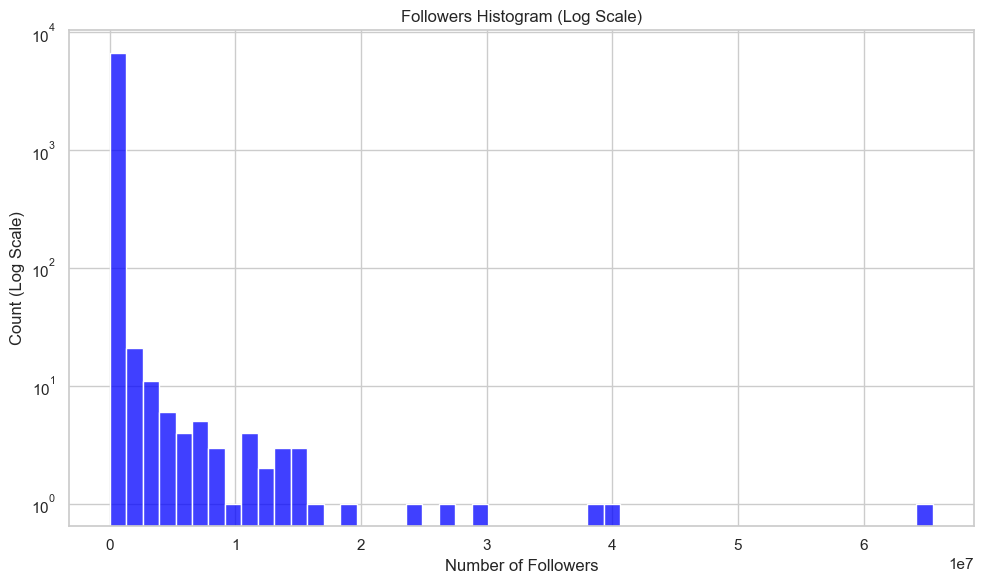

File already exists. No changes were made: following_histogram.png


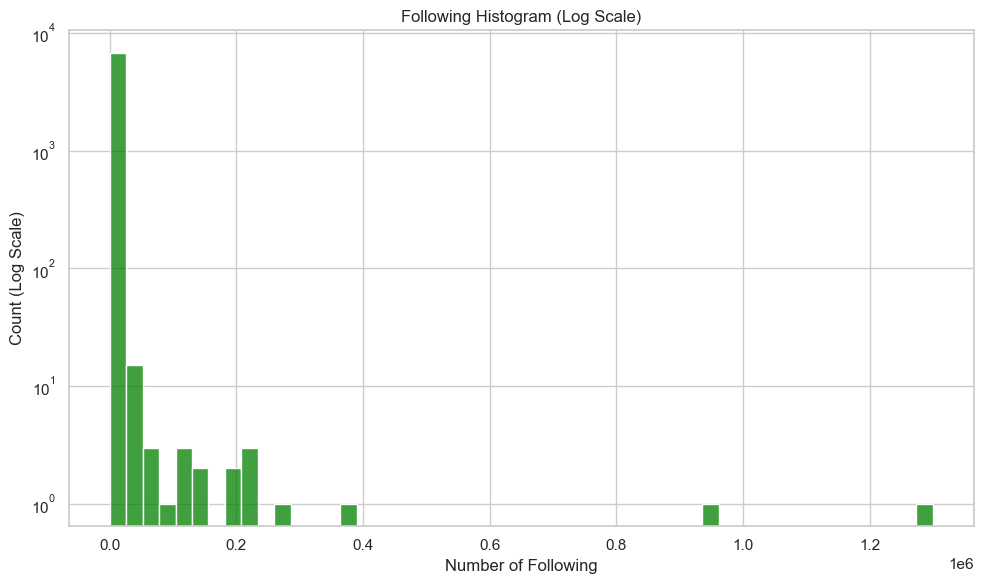

File already exists. No changes were made: posts_histogram.png


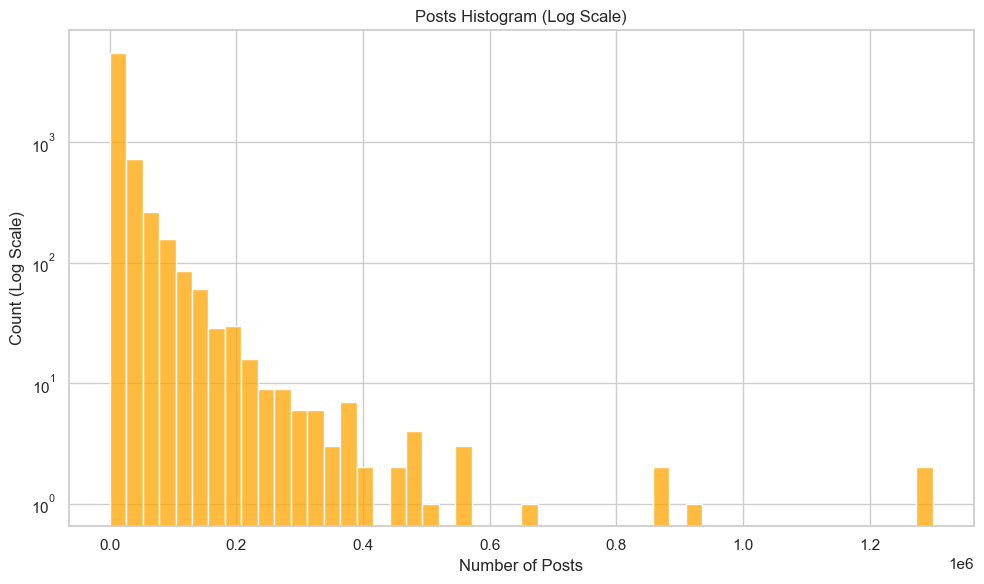

In [67]:
sns.set_theme(style="whitegrid")
# 1. Followers Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['followers'], bins=50, color='blue')
plt.yscale('log')
plt.title('Followers Histogram (Log Scale)')
plt.xlabel('Number of Followers')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
save_plot_safely("followers_histogram.png", overwrite=False)
plt.show()

# 2. Following Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['following'], bins=50, color='green')
plt.yscale('log')
plt.title('Following Histogram (Log Scale)')
plt.xlabel('Number of Following')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
save_plot_safely("following_histogram.png", overwrite=False)
plt.show()

# 3. Posts Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['posts'], bins=50, color='orange')
plt.yscale('log')
plt.title('Posts Histogram (Log Scale)')
plt.xlabel('Number of Posts')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
save_plot_safely("posts_histogram.png", overwrite=False)
plt.show()

## Random Sampling for Manual Annotation
Selecting a random subset of 100 users from the dataset in order to create the initial manually labeled dataset.


In [68]:
# Randomly select 100 users from the dataset
sample_df = df.sample(n=100, random_state=42)

# Display the first rows of the sampled dataset
sample_df

,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,join_date_parsed
1335,Roy_Iddan,False,118400,5619.0,79100.0,tv writer uke player + high functioning sociop...,israel,joined may 2009,Israeli,1,2009-05-01
5679,RayneNGrace,False,652500,5459.0,3827.0,imperfect loved by a perfect god! \nmarried to...,blessed usa,joined april 2011,Israeli,3,2011-04-01
5962,shirellaloom,False,23000,680.0,10300.0,כתבת יו''ש | עכשיו 14 | אמא לשני קטנים מתוקים ...,ישראל,joined february 2016,Israeli,1,2016-02-01
37,raananshaked,False,6425,717.0,53300.0,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,joined march 2009,Israeli,1,2009-03-01
5939,IsraelMOH,False,3506,112.0,20800.0,הטוויטר הרשמי של משרד הבריאות | הצטרפו לערוץ ה...,israel,joined december 2013,Israeli,1,2013-12-01
...,...,...,...,...,...,...,...,...,...,...,...
4258,Lauren_Provost,False,14000,2932.0,10500.0,journalisme numérique dans un quotidien libre....,paris,joined march 2010,Israeli,3,2010-03-01
1600,Yesh_Din,False,845,279.0,12200.0,yesh din is an israeli human rights ngo workin...,west bank/tel aviv,joined september 2022,Israeli,2,2022-09-01
4728,ElfeVan,False,19200,663.0,273.0,NaN,niederlande,joined july 2020,Israeli,2,2020-07-01
742,asafzamir,False,1544,481.0,35800.0,וממלא מקומו,NaN,joined march 2009,Israeli,1,2009-03-01


## Annotation Dataset Preparation
Preparing the sampled dataset for manual annotation by selecting the relevant columns and creating empty annotation fields.


In [69]:
# Keep only relevant columns for annotation
annotation_df = sample_df[['username', 'bio', 'location']].copy()

# Create empty annotation columns
annotation_df['target_population'] = ""
annotation_df['locals_vs_diaspora'] = ""
annotation_df['person_vs_organization'] = ""
annotation_df['comments'] = ""

# Display the annotation dataset
annotation_df

,username,bio,location,target_population,locals_vs_diaspora,person_vs_organization,comments
1335,Roy_Iddan,tv writer uke player + high functioning sociop...,israel,,,,
5679,RayneNGrace,imperfect loved by a perfect god! \nmarried to...,blessed usa,,,,
5962,shirellaloom,כתבת יו''ש | עכשיו 14 | אמא לשני קטנים מתוקים ...,ישראל,,,,
37,raananshaked,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,,,,
5939,IsraelMOH,הטוויטר הרשמי של משרד הבריאות | הצטרפו לערוץ ה...,israel,,,,
...,...,...,...,...,...,...,...
4258,Lauren_Provost,journalisme numérique dans un quotidien libre....,paris,,,,
1600,Yesh_Din,yesh din is an israeli human rights ngo workin...,west bank/tel aviv,,,,
4728,ElfeVan,NaN,niederlande,,,,
742,asafzamir,וממלא מקומו,NaN,,,,


## Saving Annotation Files
Saving the annotation dataset into two separate files (one per annotator), skipping files that already exist.


In [70]:

ofir_path = "Classification/Iteration_1/iteration_1_annotation_ofir.csv"
if not os.path.exists(ofir_path):
    annotation_df.to_csv(ofir_path, index=False, encoding='utf-8-sig')
    print(f"Created: {ofir_path}")
else:
    print(f"File already exists, skipped: {ofir_path}")

matan_path = "Classification/Iteration_1/iteration_1_annotation_matan.csv"
if not os.path.exists(matan_path):
    annotation_df.to_csv(matan_path, index=False, encoding='utf-8-sig')
    print(f"Created: {matan_path}")
else:
    print(f"File already exists, skipped: {matan_path}")

File already exists, skipped: Classification/Iteration_1/iteration_1_annotation_ofir.csv
File already exists, skipped: Classification/Iteration_1/iteration_1_annotation_matan.csv


## Inter-Rater Agreement & Conflict Extraction
Merging the independent annotations of both team members and extracting the rows where they disagreed; the conflicting records are exported to a dedicated file for joint review.


In [71]:
df_matan = pd.read_csv('Classification/Iteration_1/iteration_1_annotation_matan.csv')
df_ofir = pd.read_csv('Classification/Iteration_1/iteration_1_annotation_ofir.csv')

# Merge the dataframes based on the username column
df_merged = pd.merge(df_matan, df_ofir, on='username', suffixes=('_matan', '_ofir'))

# Define the columns that need to be compared
label_columns = ['target_population', 'locals_vs_diaspora', 'person_vs_organization']

# Create a condition (mask) to find rows where at least one label does not match
conflict_mask = (
    (df_merged['target_population_matan'] != df_merged['target_population_ofir']) |
    (df_merged['locals_vs_diaspora_matan'] != df_merged['locals_vs_diaspora_ofir']) |
    (df_merged['person_vs_organization_matan'] != df_merged['person_vs_organization_ofir'])
)

# Extract only the users that have conflicting annotations
df_conflicts = df_merged[conflict_mask].copy()

# Create empty columns for the final decision that will be made during the discussion
for col in label_columns:
    df_conflicts[f'{col}_final'] = ''

# Reorder columns for a convenient side-by-side comparison
columns_to_export = ['username']
for col in label_columns:
    columns_to_export.extend([f'{col}_matan', f'{col}_ofir', f'{col}_final'])
columns_to_export.extend(['comments_matan', 'comments_ofir'])

# Define the output path
output_path = 'Classification/Iteration_1/iteration_1_conflicts_to_resolve.csv'

# Check if the file already exists
if not os.path.exists(output_path):
    # Save the conflicts to a new CSV file for manual resolution
    df_conflicts[columns_to_export].to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Found {len(df_conflicts)} conflicts out of {len(df_merged)} users.")
    print(f"The file '{output_path}' was created and is ready for your joint review.")
else:
    print(f"Found {len(df_conflicts)} conflicts out of {len(df_merged)} users.")
    print(f"The file '{output_path}' already exists. No changes were made to it.")

Found 21 conflicts out of 100 users.
The file 'Classification/Iteration_1/iteration_1_conflicts_to_resolve.csv' already exists. No changes were made to it.


## Building Ground Truth & Agreement Metrics


Building the final ground truth dataset by merging the independent annotations with the manually resolved conflicts, and computing Percent Agreement and Cohen's Kappa for each category.


In [72]:
# Define file paths according to the notebook's structure
path_matan = 'Classification/Iteration_1/iteration_1_annotation_matan.csv'
path_ofir = 'Classification/Iteration_1/iteration_1_annotation_ofir.csv'
path_conflicts = 'Classification/Iteration_1/conflicts_to_resolve.csv'
path_consensus_out = 'Classification/Iteration_1/iteration_1_labels_consensus.csv'
path_report_out = 'Classification/Iteration_1/iteration_1_agreement_report.csv'

# Check if the output files already exist to prevent overwriting
if os.path.exists(path_consensus_out) and os.path.exists(path_report_out):
    print(f"The output files '{path_consensus_out}' and '{path_report_out}' already exist. Skipping creation.")
    
    df_consensus = pd.read_csv(path_consensus_out)
    df_report = pd.read_csv(path_report_out)
    
    print("\nStatistical Results (Cohen's Kappa):")
    print(df_report.to_string(index=False))
    
else:
    # Verify all required input files exist before processing
    if not (os.path.exists(path_matan) and os.path.exists(path_ofir) and os.path.exists(path_conflicts)):
        print("Error: One or more input files are missing in the 'Classification/' directory.")
    else:
        # Load the original annotation files and the manually resolved conflicts
        df_matan = pd.read_csv(path_matan)
        df_ofir = pd.read_csv(path_ofir)
        df_conflicts = pd.read_csv(path_conflicts)

        # Merge the original files to align all user records side-by-side
        df_merged = pd.merge(df_matan, df_ofir, on='username', suffixes=('_matan', '_ofir'))
        label_columns = ['target_population', 'locals_vs_diaspora', 'person_vs_organization']

        final_records = []
        metrics_data = []

        # --- Phase 1: Build the Consensus Dataset ---
        for index, row in df_merged.iterrows():
            username = row['username']
            
            # Check if this specific user was flagged as a conflict
            resolved_row = df_conflicts[df_conflicts['username'] == username]
            
            record = {'username': username}
            
            if not resolved_row.empty:
                # Conflict exists: Apply the manually agreed-upon labels from the discussion
                record['target_population'] = resolved_row.iloc[0]['target_population_final']
                record['locals_vs_diaspora'] = resolved_row.iloc[0]['locals_vs_diaspora_final']
                record['person_vs_organization'] = resolved_row.iloc[0]['person_vs_organization_final']
                record['consensus_source'] = 'manual_discussion'
            else:
                # No conflict: Apply the initial agreed-upon label
                record['target_population'] = row['target_population_matan']
                record['locals_vs_diaspora'] = row['locals_vs_diaspora_matan']
                record['person_vs_organization'] = row['person_vs_organization_matan']
                record['consensus_source'] = 'auto_agree'
                
            final_records.append(record)

        # Export the final consensus dataset for model training
        df_consensus = pd.DataFrame(final_records)
        df_consensus.to_csv(path_consensus_out, index=False, encoding='utf-8-sig')

        # --- Phase 2: Calculate Agreement Metrics ---
        for col in label_columns:
            # Extract independent labels prior to manual resolution
            y_matan = df_merged[f'{col}_matan']
            y_ofir = df_merged[f'{col}_ofir']
            
            # Drop missing values to ensure accurate Kappa calculation (if any exist)
            valid_indices = y_matan.notna() & y_ofir.notna()
            y_matan_valid = y_matan[valid_indices]
            y_ofir_valid = y_ofir[valid_indices]
            
            # Calculate simple Percent Agreement
            total_items = len(y_matan_valid)
            if total_items > 0:
                agreement_count = (y_matan_valid == y_ofir_valid).sum()
                percent_agreement = (agreement_count / total_items) * 100 
                
                # Calculate Cohen's Kappa score to account for chance agreement
                kappa = cohen_kappa_score(y_matan_valid, y_ofir_valid)
            else:
                percent_agreement = 0
                kappa = 0
                
            metrics_data.append({
                'label_type': col,
                'n_items': total_items,
                'percent_agreement': round(percent_agreement, 2),
                'cohens_kappa': round(kappa, 4)
            })

        # Export the metrics report
        df_report = pd.DataFrame(metrics_data)
        df_report.to_csv(path_report_out, index=False, encoding='utf-8-sig')

        # Output the final status and metrics to the console
        print(f"✅ Consensus dataset created: '{path_consensus_out}'")
        print(f"✅ Quality metrics report created: '{path_report_out}'")
        print("\nStatistical Results (Cohen's Kappa):")
        print(df_report.to_string(index=False))

The output files 'Classification/Iteration_1/iteration_1_labels_consensus.csv' and 'Classification/Iteration_1/iteration_1_agreement_report.csv' already exist. Skipping creation.

Statistical Results (Cohen's Kappa):
            label_type  n_items  percent_agreement  cohens_kappa
     target_population      100               90.0        0.7052
    locals_vs_diaspora      100               90.0        0.7241
person_vs_organization      100               89.0        0.6317


## Data Export and Class Distribution Summary


Splitting the consensus dataset into three separate CSV files (one per classification task), and generating a statistical summary of the count and percentage of users per class.


In [73]:
# Step 3 - Split and save the required classification files safely

# Load one annotation file to get username, bio and location
annotation_df = pd.read_csv("Classification/Iteration_1/iteration_1_annotation_ofir.csv")

# Load the final consensus labels
df_consensus = pd.read_csv("Classification/Iteration_1/iteration_1_labels_consensus.csv")

# Clean column names
annotation_df.columns = annotation_df.columns.str.strip()
df_consensus.columns = df_consensus.columns.str.strip()

# Clean usernames
annotation_df["username"] = annotation_df["username"].astype(str).str.strip()
df_consensus["username"] = df_consensus["username"].astype(str).str.strip()

# Merge the consensus results with profile fields
df_final = pd.merge(
    annotation_df[["username", "bio", "location"]],
    df_consensus,
    on="username"
)

# Define output paths
path_target = "Classification/Iteration_1/iteration_1_target_population.csv"
path_locals = "Classification/Iteration_1/iteration_1_locals_vs_diaspora.csv"
path_person = "Classification/Iteration_1/iteration_1_person_vs_organization.csv"

# Save target population file safely
save_csv_safely(
    df_final[["username", "bio", "location", "target_population", "consensus_source"]],
    path_target,
    overwrite=False
)

# Save locals vs diaspora file safely
save_csv_safely(
    df_final[["username", "bio", "location", "locals_vs_diaspora", "consensus_source"]],
    path_locals,
    overwrite=False
)

# Save person vs organization file safely
save_csv_safely(
    df_final[["username", "bio", "location", "person_vs_organization", "consensus_source"]],
    path_person,
    overwrite=False
)

print("Classification files were checked safely.")
print("Rows in merged file:", len(df_final))

File already exists. No changes were made: Classification/Iteration_1/iteration_1_target_population.csv
File already exists. No changes were made: Classification/Iteration_1/iteration_1_locals_vs_diaspora.csv
File already exists. No changes were made: Classification/Iteration_1/iteration_1_person_vs_organization.csv
Classification files were checked safely.
Rows in merged file: 100


## Step 4 - User Labeling Decision Flows

In this step we created three flowcharts describing the manual decision process used during Iteration 1 labeling, for the target columns target_population, locals_vs_diaspora and person_vs_organization. The PowerPoint file was saved under Manual_Labeling/user_labeling_decision_flows.pptx.


## Step 5 - Training Classifiers and Active Learning Preparation

בשלב זה אנו מאמנים מסווגי למידת מכונה על הנתונים המתויגים מאיטרציה 1, עבור שלוש עמודות המטרה. המטרה היא להשוות אלגוריתמים, מערכי מאפיינים, אסטרטגיות ולידציה ואימון מאוזן/לא מאוזן. כל תוצאות הניסויים נשמרות לקובץ Classification/experiments_results_iteration_1.csv.

In this step we train machine learning classifiers on the manually labeled data from Iteration 1, for the three target columns. The goal is to compare algorithms, feature sets, validation strategies, and balanced/unbalanced training. All experiment results are saved to Classification/experiments_results_iteration_1.csv.


## Step 5 - Load Labeled Data

טעינת נתוני המשתמשים ותוויות הקונצנזוס, בדיקה שהקבצים הנדרשים קיימים, ומיזוגם למערך נתונים מתויג לאימון המודלים.

Loading the user data and consensus labels, verifying that the required files exist, and merging them into a labeled dataset for model training.


In [74]:
# Step 5 - Load labeled data for model training

import pandas as pd
import os

# File paths
users_data_path = "Data/final_israeli_users.xlsx"
consensus_path = "Classification/Iteration_1/iteration_1_labels_consensus.csv"

# Check that required files exist
if not os.path.exists(users_data_path):
    raise FileNotFoundError(f"Users data file not found: {users_data_path}")

if not os.path.exists(consensus_path):
    raise FileNotFoundError(f"Consensus labels file not found: {consensus_path}")

# Load files
df_users = pd.read_excel(users_data_path)
df_consensus = pd.read_csv(consensus_path)

# Clean column names
df_users.columns = df_users.columns.str.strip()
df_consensus.columns = df_consensus.columns.str.strip()

# Clean usernames
df_users["username"] = df_users["username"].astype(str).str.strip()
df_consensus["username"] = df_consensus["username"].astype(str).str.strip()

# Merge user data with final labels
df_labeled = pd.merge(
    df_users,
    df_consensus,
    on="username",
    how="inner"
)

# Basic checks
print("Users data rows:", len(df_users))
print("Consensus rows:", len(df_consensus))
print("Merged labeled rows:", len(df_labeled))

# Stop if merge is not correct
if len(df_labeled) != 100:
    raise ValueError("Merged labeled dataset should contain 100 users. Check username matching.")

print("\nColumns in labeled dataset:")
print(df_labeled.columns.tolist())

print("\nFirst 5 rows:")
display(df_labeled.head())

Users data rows: 6965
Consensus rows: 100
Merged labeled rows: 100

Columns in labeled dataset:
['username', 'is_private', 'posts', 'following', 'followers', 'bio', 'location', 'join_date', 'is_israeli', 'classifier_stage', 'target_population', 'locals_vs_diaspora', 'person_vs_organization', 'consensus_source']

First 5 rows:


,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,target_population,locals_vs_diaspora,person_vs_organization,consensus_source
0,raananshaked,False,6425,717.0,53300.0,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,joined march 2009,Israeli,1,1,1,1,auto_agree
1,HiggsBozoEffect,False,44500,819.0,3454.0,NaN,texas usa,joined november 2015,Israeli,5,1,0,1,manual_discussion
2,AlonaSherf,False,30400,1965.0,818.0,photographer activist vegan.,israel,joined march 2009,Israeli,2,1,1,1,auto_agree
3,shwrzenberg,False,12000,5086.0,2187.0,החיים עוד לא חזרו למסלולם ״הפצעים עדיין לא הגל...,ישראל,joined march 2019,Israeli,1,1,1,1,auto_agree
4,LahavHarkov,False,188600,3106.0,185100.0,senior political correspondent,jerusalem\tel aviv,joined june 2011,Israeli,2,1,1,1,auto_agree


## Class Distribution Check

הצגת התפלגות המחלקות (כמות ואחוזים) עבור כל אחת משלוש עמודות המטרה, כדי לזהות חוסר איזון בין המחלקות.

Displaying the class distribution (counts and percentages) for each of the three target columns, in order to identify class imbalance.


In [75]:
# Check class distribution for each target column

target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

for col in target_columns:
    print(f"\nClass distribution for {col}:")
    print(df_labeled[col].value_counts(dropna=False).sort_index())
    
    print("\nPercentage:")
    print((df_labeled[col].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2))


Class distribution for target_population:
target_population
0    15
1    79
2     6
Name: count, dtype: int64

Percentage:
target_population
0    15.0
1    79.0
2     6.0
Name: proportion, dtype: float64

Class distribution for locals_vs_diaspora:
locals_vs_diaspora
0    18
1    76
2     6
Name: count, dtype: int64

Percentage:
locals_vs_diaspora
0    18.0
1    76.0
2     6.0
Name: proportion, dtype: float64

Class distribution for person_vs_organization:
person_vs_organization
0    16
1    81
2     3
Name: count, dtype: int64

Percentage:
person_vs_organization
0    16.0
1    81.0
2     3.0
Name: proportion, dtype: float64


## Step 5.1 - Feature Preparation

הכנת מאפיינים מבוססי-פרופיל לאימון: איחוד שדות הטקסט (username, bio, location) למאפיין טקסטואלי אחד, לצד מאפיינים מספריים של החשבון (is_private, posts, following, followers).

Preparing profile-based features for training: combining the text fields (username, bio, location) into a single text feature, alongside numeric account metadata (is_private, posts, following, followers).


In [76]:
# Step 5.1 - Prepare features for model training

import numpy as np

# Create a copy of the labeled dataset
df_model = df_labeled.copy()

# Define target columns
target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# Fill missing text values
text_columns = ["username", "bio", "location"]

for col in text_columns:
    df_model[col] = df_model[col].fillna("").astype(str)

# Create one combined text feature from username, bio, and location
df_model["profile_text"] = (
    df_model["username"] + " " +
    df_model["bio"] + " " +
    df_model["location"]
)

# Convert numeric columns safely
numeric_columns = ["is_private", "posts", "following", "followers"]

for col in numeric_columns:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Convert boolean is_private to numeric if needed
df_model["is_private"] = df_model["is_private"].astype(int)

# Fill missing numeric values with 0
df_model[numeric_columns] = df_model[numeric_columns].fillna(0)

# Make sure target columns are numeric
for col in target_columns:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Check final training dataframe
print("Model dataframe rows:", len(df_model))
print("Selected text feature:", "profile_text")
print("Numeric features:", numeric_columns)
print("Target columns:", target_columns)

print("\nMissing values in selected features:")
print(df_model[["profile_text"] + numeric_columns + target_columns].isna().sum())

print("\nPreview:")
display(df_model[["username", "profile_text"] + numeric_columns + target_columns].head())

Model dataframe rows: 100
Selected text feature: profile_text
Numeric features: ['is_private', 'posts', 'following', 'followers']
Target columns: ['target_population', 'locals_vs_diaspora', 'person_vs_organization']

Missing values in selected features:
profile_text              0
is_private                0
posts                     0
following                 0
followers                 0
target_population         0
locals_vs_diaspora        0
person_vs_organization    0
dtype: int64

Preview:


,username,profile_text,is_private,posts,following,followers,target_population,locals_vs_diaspora,person_vs_organization
0,raananshaked,raananshaked כעס. למרות כל מה שג'וי אומרת כדי ...,0,6425,717.0,53300.0,1,1,1
1,HiggsBozoEffect,HiggsBozoEffect texas usa,0,44500,819.0,3454.0,1,0,1
2,AlonaSherf,AlonaSherf photographer activist vegan. israel,0,30400,1965.0,818.0,1,1,1
3,shwrzenberg,shwrzenberg החיים עוד לא חזרו למסלולם ״הפצעים ...,0,12000,5086.0,2187.0,1,1,1
4,LahavHarkov,LahavHarkov senior political correspondent jer...,0,188600,3106.0,185100.0,1,1,1


## Step 5.2 - Model Training Setup

ייבוא הספריות ופונקציות העזר לאימון המודלים: pipelines, vectorizer לטקסט (TF-IDF), המסווגים השונים ומדדי ההערכה.

Importing the libraries and helper functions for model training: pipelines, the text vectorizer (TF-IDF), the various classifiers, and the evaluation metrics.


In [77]:
# Step 5.2 - Imports and helper functions for model training

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC

# Feature definitions
text_feature = "profile_text"
numeric_features = ["is_private", "posts", "following", "followers"]

target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# Preprocessing:
# TF-IDF for text and StandardScaler for numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=500, ngram_range=(1, 2)), text_feature),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

# Evaluation metrics
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0)
}

print("Step 5.2 setup completed.")

Step 5.2 setup completed.


## Step 5.3 - Full Experiment Table

הרצת טבלת הניסויים המלאה בהתאם לדרישות הפרויקט (אלגוריתמים, מערכי מאפיינים, אסטרטגיות ולידציה ואיזון מחלקות), או טעינת תוצאות קיימות. התוצאות נשמרות לקובץ ה-CSV של הניסויים.

Running the full experiment table as required by the project (algorithms, feature sets, validation strategies, and class balancing), or loading existing results. The results are saved to the experiments CSV file.


In [78]:
# Step 5.3 - Full experiment table according to project requirements
# This cell either loads existing experiment results or reruns all experiments.

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC


# ------------------------------------------------------------
# Control whether to rerun all experiments
# ------------------------------------------------------------

# False = do not rerun experiments if the results file already exists.
# True  = rerun all experiments and overwrite the results file.
RUN_EXPERIMENTS = False

results_path = "Classification/Iteration_1/experiments_results_iteration_1.csv"


if not RUN_EXPERIMENTS and os.path.exists(results_path):
    print("Experiment results file already exists.")
    print("Skipping model training experiments.")
    print(f"Loading existing results from: {results_path}")

    df_experiments = pd.read_csv(results_path)

    print(f"Loaded experiment results rows: {len(df_experiments)}")
    display(df_experiments.head())

else:
    print("Running model training experiments...")

    # Optional XGBoost
    try:
        from xgboost import XGBClassifier
        xgboost_available = True
    except ImportError:
        xgboost_available = False
        print("XGBoost is not installed. XGBoost experiments will be skipped.")


    # ------------------------------------------------------------
    # 1. Basic definitions
    # ------------------------------------------------------------

    iteration_number = 1

    target_columns = [
        "target_population",
        "locals_vs_diaspora",
        "person_vs_organization"
    ]

    numeric_features = ["is_private", "posts", "following", "followers"]

    # Make sure profile_text exists.
    # profile_text combines the main textual fields used for classification.
    if "profile_text" not in df_model.columns:
        df_model["profile_text"] = (
            df_model["username"].fillna("").astype(str) + " " +
            df_model["bio"].fillna("").astype(str) + " " +
            df_model["location"].fillna("").astype(str)
        )


    # ------------------------------------------------------------
    # 2. Feature sets
    # ------------------------------------------------------------
    # We compare different feature representations:
    # 1. TF-IDF over profile text only
    # 2. TF-IDF over profile text + numeric metadata

    feature_sets = {
        "TFIDF_profile_text": {
            "columns": ["profile_text"],
            "numeric": [],
            "count_features": 500
        },
        "TFIDF_profile_text+numeric_metadata": {
            "columns": ["profile_text"] + numeric_features,
            "numeric": numeric_features,
            "count_features": 500 + len(numeric_features)
        }
    }


    def build_preprocessor(feature_set_name):
        """
        Builds the preprocessing step according to the selected feature set.

        Text feature:
        - profile_text is transformed using TF-IDF.

        Numeric features:
        - is_private, posts, following, followers are standardized when included.
        """

        config = feature_sets[feature_set_name]

        transformers = [
            (
                "text",
                TfidfVectorizer(max_features=500, ngram_range=(1, 2)),
                "profile_text"
            )
        ]

        if len(config["numeric"]) > 0:
            transformers.append(
                (
                    "numeric",
                    StandardScaler(),
                    config["numeric"]
                )
            )

        return ColumnTransformer(transformers=transformers)


    # ------------------------------------------------------------
    # 3. Models
    # ------------------------------------------------------------

    def get_models(balanced):
        """
        Creates the classifiers for each experiment.

        balanced=False:
        - regular training.

        balanced=True:
        - class_weight='balanced' for models that support it.
        - sample_weight is handled during fit for AdaBoost and XGBoost.
        """

        class_weight_value = "balanced" if balanced else None

        models = {
            "LogReg": LogisticRegression(
                max_iter=1000,
                class_weight=class_weight_value,
                random_state=42
            ),

            "Decision Tree": DecisionTreeClassifier(
                class_weight=class_weight_value,
                random_state=42
            ),

            "Random Forest": RandomForestClassifier(
                n_estimators=100,
                class_weight=class_weight_value,
                random_state=42
            ),

            "SVM": LinearSVC(
                class_weight=class_weight_value,
                random_state=42
            ),

            "AdaBoost": AdaBoostClassifier(
                random_state=42
            )
        }

        if xgboost_available:
            models["XGBoost"] = XGBClassifier(
                random_state=42,
                eval_metric="mlogloss"
            )

        return models


    # ------------------------------------------------------------
    # 4. Helper functions
    # ------------------------------------------------------------

    def safe_auc_score(y_true, y_score, classes):
        """
        Calculates ROC-AUC safely.

        Binary classification:
        - calculates regular ROC-AUC.

        Multiclass classification:
        - calculates macro ROC-AUC using One-vs-Rest when possible.

        If AUC cannot be calculated for a specific model/output,
        the function returns NaN.
        """

        try:
            unique_classes = np.unique(y_true)

            # AUC requires at least 2 classes in the true labels.
            if len(unique_classes) < 2:
                return np.nan

            # Binary classification
            if len(classes) == 2:
                if len(y_score.shape) == 2:
                    return roc_auc_score(y_true, y_score[:, 1])
                else:
                    return roc_auc_score(y_true, y_score)

            # Multiclass classification
            if len(classes) == 3:
                if len(y_score.shape) == 2 and y_score.shape[1] == len(classes):
                    return roc_auc_score(
                        y_true,
                        y_score,
                        multi_class="ovr",
                        average="macro",
                        labels=classes
                    )

            return np.nan

        except Exception:
            return np.nan


    def evaluate_model_cv(X, y, pipeline, cv, balanced, model_name):
        """
        Runs cross validation manually.

        Why manually?
        - We need full control over metrics and AUC.
        - We need to support balanced sample weights for AdaBoost/XGBoost.
        - We need to collect predictions across all folds.

        The function returns:
        accuracy, precision, recall, F1, AUC
        """

        y_true_all = []
        y_pred_all = []
        y_score_all = []

        classes = np.sort(y.unique())

        for train_index, test_index in cv.split(X, y):
            X_train = X.iloc[train_index]
            X_test = X.iloc[test_index]
            y_train = y.iloc[train_index]
            y_test = y.iloc[test_index]

            # AdaBoost and XGBoost do not use class_weight in the same way as sklearn models.
            # For balanced mode, we pass sample weights during training.
            if balanced and model_name in ["AdaBoost", "XGBoost"]:
                sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
                pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)
            else:
                pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_test)

            # Try to get scores/probabilities for AUC.
            y_score = None

            if hasattr(pipeline, "predict_proba"):
                try:
                    y_score = pipeline.predict_proba(X_test)
                except Exception:
                    y_score = None

            if y_score is None and hasattr(pipeline, "decision_function"):
                try:
                    y_score = pipeline.decision_function(X_test)
                except Exception:
                    y_score = None

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            if y_score is not None:
                if y_score_all is not None:
                    y_score_all.extend(np.array(y_score).tolist())
            else:
                y_score_all = None

        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)

        accuracy = accuracy_score(y_true_all, y_pred_all)
        precision = precision_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        recall = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)

        if y_score_all is not None:
            y_score_all = np.array(y_score_all)
            auc = safe_auc_score(y_true_all, y_score_all, classes)
        else:
            auc = np.nan

        return accuracy, precision, recall, f1, auc


    # ------------------------------------------------------------
    # 5. Run all required experiments
    # ------------------------------------------------------------

    experiment_results = []

    for target_col in target_columns:

        for class_mode in ["3_classes", "2_classes_without_unknown"]:

            # 3-class classification:
            # uses all labels: 0, 1, 2.
            if class_mode == "3_classes":
                df_task = df_model.copy()

            # 2-class classification:
            # removes unknown class 2 and keeps only 0 and 1.
            else:
                df_task = df_model[df_model[target_col] != 2].copy()

            X_base = df_task[["profile_text"] + numeric_features]
            y_base = df_task[target_col].astype(int).reset_index(drop=True)
            X_base = X_base.reset_index(drop=True)

            class_counts = y_base.value_counts().to_dict()

            count_class_0 = class_counts.get(0, 0)
            count_class_1 = class_counts.get(1, 0)
            count_class_2 = class_counts.get(2, 0)

            classes_number = y_base.nunique()
            min_class_size = min(class_counts.values())

            print(f"\nTarget: {target_col} | Mode: {class_mode}")
            print("Class counts:", class_counts)

            for feature_set_name, feature_config in feature_sets.items():

                X = X_base[feature_config["columns"]]

                for balanced in [False, True]:

                    models = get_models(balanced)

                    for algorithm_name, model in models.items():

                        # Required validation methods:
                        # 1. K-Fold with K=5
                        # 2. LOOCV
                        validation_methods = [
                            ("K-Fold", 5, StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
                            ("LOOCV", "", LeaveOneOut())
                        ]

                        for training_type, K_value, cv in validation_methods:

                            preprocessor = build_preprocessor(feature_set_name)

                            pipeline = Pipeline(
                                steps=[
                                    ("preprocessor", preprocessor),
                                    ("classifier", model)
                                ]
                            )

                            try:
                                accuracy, precision, recall, f1, auc = evaluate_model_cv(
                                    X=X,
                                    y=y_base,
                                    pipeline=pipeline,
                                    cv=cv,
                                    balanced=balanced,
                                    model_name=algorithm_name
                                )

                                result = {
                                    "iteration": iteration_number,
                                    "target_column": target_col,
                                    "#classes": classes_number,
                                    "#class_0": count_class_0,
                                    "#class_1": count_class_1,
                                    "#class_2": count_class_2 if classes_number == 3 else 0,
                                    "min_class_size": min_class_size,
                                    "training_type": training_type,
                                    "K": K_value,
                                    "algorithm": algorithm_name,
                                    "feature_set": feature_set_name,
                                    "Features_count": feature_config["count_features"],
                                    "balanced": balanced,
                                    "accuracy": round(accuracy, 4),
                                    "precision": round(precision, 4),
                                    "recall": round(recall, 4),
                                    "F1": round(f1, 4),
                                    "AUC": round(auc, 4) if not pd.isna(auc) else ""
                                }

                                experiment_results.append(result)

                            except Exception as error:
                                print(
                                    f"Experiment failed: "
                                    f"target={target_col}, "
                                    f"mode={class_mode}, "
                                    f"features={feature_set_name}, "
                                    f"algorithm={algorithm_name}, "
                                    f"balanced={balanced}, "
                                    f"validation={training_type}"
                                )
                                print("Error:", error)


    # ------------------------------------------------------------
    # 6. Save the final experiment results file
    # ------------------------------------------------------------

    df_experiments = pd.DataFrame(experiment_results)

    required_columns = [
        "iteration",
        "target_column",
        "#classes",
        "#class_0",
        "#class_1",
        "#class_2",
        "min_class_size",
        "training_type",
        "K",
        "algorithm",
        "feature_set",
        "Features_count",
        "balanced",
        "accuracy",
        "precision",
        "recall",
        "F1",
        "AUC"
    ]

    df_experiments = df_experiments[required_columns]

    output_path = results_path

    df_experiments.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"\nTotal experiments saved: {len(df_experiments)}")
    print(f"Experiment results saved to: {output_path}")

    display(df_experiments.head())

Experiment results file already exists.
Skipping model training experiments.
Loading existing results from: Classification/Iteration_1/experiments_results_iteration_1.csv
Loaded experiment results rows: 288


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,target_population,3,15,79,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.8042
1,1,target_population,3,15,79,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7133
2,1,target_population,3,15,79,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.78,0.3507,0.3471,0.3284,0.5849
3,1,target_population,3,15,79,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.77,0.3799,0.3609,0.3542,0.6269
4,1,target_population,3,15,79,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7291


## Step 5.4 - Verify Experiment Results

טעינת קובץ תוצאות הניסויים ובדיקת תקינותו: מספר השורות, שמות העמודות והערכים הייחודיים של האלגוריתמים, סוגי האימון, מערכי המאפיינים ועמודות המטרה.

Loading the experiment results file and verifying it: number of rows, column names, and the unique values of the algorithms, training types, feature sets, and target columns.


In [79]:
# Step 5.4 - Verify experiment results file

results_path = "Classification/Iteration_1/experiments_results_iteration_1.csv"

df_results_check = pd.read_csv(results_path)

print("Rows in results file:", len(df_results_check))

print("\nColumns:")
print(df_results_check.columns.tolist())

print("\nAlgorithms used:")
print(df_results_check["algorithm"].unique())

print("\nTraining types:")
print(df_results_check["training_type"].unique())

print("\nFeature sets:")
print(df_results_check["feature_set"].unique())

print("\nBalanced values:")
print(df_results_check["balanced"].unique())

print("\nTargets:")
print(df_results_check["target_column"].unique())

print("\nNumber of experiments by target and class mode:")
display(
    df_results_check
    .groupby(["target_column", "#classes"])
    .size()
    .reset_index(name="num_experiments")
)

display(df_results_check.head())

Rows in results file: 288

Columns:
['iteration', 'target_column', '#classes', '#class_0', '#class_1', '#class_2', 'min_class_size', 'training_type', 'K', 'algorithm', 'feature_set', 'Features_count', 'balanced', 'accuracy', 'precision', 'recall', 'F1', 'AUC']

Algorithms used:
<StringArray>
['LogReg', 'Decision Tree', 'Random Forest', 'SVM', 'AdaBoost', 'XGBoost']
Length: 6, dtype: str

Training types:
<StringArray>
['K-Fold', 'LOOCV']
Length: 2, dtype: str

Feature sets:
<StringArray>
['TFIDF_profile_text', 'TFIDF_profile_text+numeric_metadata']
Length: 2, dtype: str

Balanced values:
[False  True]

Targets:
<StringArray>
['target_population', 'locals_vs_diaspora', 'person_vs_organization']
Length: 3, dtype: str

Number of experiments by target and class mode:


,target_column,#classes,num_experiments
0,locals_vs_diaspora,2,48
1,locals_vs_diaspora,3,48
2,person_vs_organization,2,48
3,person_vs_organization,3,48
4,target_population,2,48
5,target_population,3,48


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,target_population,3,15,79,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.8042
1,1,target_population,3,15,79,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7133
2,1,target_population,3,15,79,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.78,0.3507,0.3471,0.3284,0.5849
3,1,target_population,3,15,79,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.77,0.3799,0.3609,0.3542,0.6269
4,1,target_population,3,15,79,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7291


In [80]:
# Step 5.4.1 - Check experiment coverage by class mode

print("Number of experiments by number of classes:")
print(df_results_check["#classes"].value_counts().sort_index())

print("\nNumber of experiments for each target column and number of classes:")
display(
    df_results_check
    .groupby(["target_column", "#classes"])
    .size()
    .reset_index(name="num_experiments")
)

Number of experiments by number of classes:
#classes
2    144
3    144
Name: count, dtype: int64

Number of experiments for each target column and number of classes:


,target_column,#classes,num_experiments
0,locals_vs_diaspora,2,48
1,locals_vs_diaspora,3,48
2,person_vs_organization,2,48
3,person_vs_organization,3,48
4,target_population,2,48
5,target_population,3,48


In [81]:
# Step 5.4.2 - Compare best F1 between 2-class and 3-class settings

best_f1_by_class_mode = (
    df_results_check
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(1)
    .reset_index(drop=True)
)

display(
    best_f1_by_class_mode[
        ["target_column", "#classes", "algorithm", "feature_set", "training_type", "balanced", "accuracy", "precision", "recall", "F1", "AUC"]
    ]
)

,target_column,#classes,algorithm,feature_set,training_type,balanced,accuracy,precision,recall,F1,AUC
0,locals_vs_diaspora,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,locals_vs_diaspora,3,AdaBoost,TFIDF_profile_text+numeric_metadata,K-Fold,False,0.8000,0.4697,0.4922,0.4805,0.5708
2,person_vs_organization,2,LogReg,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8351,0.7289,0.8260,0.7569,0.8804
3,person_vs_organization,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.9700,0.6548,0.6667,0.6606,0.6021
4,target_population,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8936,0.8091,0.7747,0.7902,0.7747
5,target_population,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.8100,0.8064,0.4471,0.4920,0.6432


## ניסויים עם שתי מחלקות ושלוש מחלקות

בשלב זה הרצנו את ניסויי המודלים בשני מצבים.

במצב הראשון השתמשנו בשלוש מחלקות, כולל מחלקת הלא ידוע.

במצב השני הסרנו את מחלקת הלא ידוע, ואימנו את המודלים רק על שתי המחלקות המרכזיות.

הסיבה לכך היא שמחלקת הלא ידוע כוללת מעט מאוד דוגמאות, ולכן קשה למודל ללמוד אותה בצורה אמינה.

לכן תוצאות שלוש המחלקות נשמרות לצורך השוואה, אך תוצאות שתי המחלקות משמשות כבסיס מעשי יותר לבחירת המודל.

## Two-Class and Three-Class Experiments

In this stage, we ran the model experiments in two settings.

The first setting used all three classes, including the unknown class.

The second setting removed the unknown class and trained the models only on the two main classes.

This was done because the unknown class contains only a small number of examples, making it difficult for the models to learn it reliably.

Therefore, the three-class results are kept for comparison, while the two-class results are used as the more practical setting for model selection.

## Step 5.5 - Best Model per Target (by F1)

הצגת המודל הטוב ביותר עבור כל עמודת מטרה ולכל מצב של מספר מחלקות, על פי ציון ה-F1.

Displaying the best model for each target column and class mode, based on the F1 score.


In [82]:
# Step 5.5 - Show best model for each target and class mode based on F1

best_models = (
    df_results_check
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(1)
)

print("Best model for each target column and class mode based on F1:")
display(best_models)

Best model for each target column and class mode based on F1:


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
183,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8723,0.7989,0.7727,0.7846,0.7727
128,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8000,0.4697,0.4922,0.4805,0.5708
277,1,person_vs_organization,2,16,81,0,16,LOOCV,NaN,LogReg,TFIDF_profile_text+numeric_metadata,504,True,0.8351,0.7289,0.8260,0.7569,0.8804
213,1,person_vs_organization,3,16,81,3,3,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.9700,0.6548,0.6667,0.6606,0.6021
87,1,target_population,2,15,79,0,15,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8936,0.8091,0.7747,0.7902,0.7747
21,1,target_population,3,15,79,6,6,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.8100,0.8064,0.4471,0.4920,0.6432


## Step 5.6 - Experiment Results Summary

בשלב זה הרצנו מספר ניסויים כדי לבדוק איזה מודל מצליח לסווג את המשתמשים בצורה הטובה ביותר.

בדקנו שלוש משימות סיווג:
`target_population`, `locals_vs_diaspora`, ו־`person_vs_organization`.

עבור כל משימת סיווג בדקנו שני מצבים: סיווג עם שלוש מחלקות, וסיווג עם שתי מחלקות בלבד לאחר הסרת המחלקה הלא ידועה.

המטרה של הבדיקה הייתה להשוות בין מודלים שונים, בין סוגי מאפיינים שונים, ובין שיטות אימון שונות. מדדי ההערכה שבהם השתמשנו הם: `Accuracy`, `Precision`, `Recall`, `F1`, ו־`AUC`.

למרות שמדד הדיוק חשוב, הוא לא תמיד מספיק כאשר הדאטה אינו מאוזן.
בדאטה שלנו יש מחלקות גדולות יותר ומחלקות קטנות יותר, ובחלק מהמשימות יש מעט מאוד דוגמאות של המחלקה הלא ידועה.

במצב כזה מודל יכול לנבא בעיקר את המחלקה הגדולה ולקבל דיוק גבוה, אבל עדיין לא לזהות היטב את המחלקות הקטנות.
לכן בחרנו את המודלים הטובים ביותר בעיקר לפי מדד `F1`.

מדד `F1` מתאים יותר למצב שבו יש חוסר איזון בין המחלקות,
כי הוא מתחשב גם בדיוק של המודל וגם ביכולת שלו לזהות את הדוגמאות הרלוונטיות.

מהתוצאות ניתן לראות שבדרך כלל הסיווג עם שתי מחלקות נתן ביצועים טובים יותר מהסיווג עם שלוש מחלקות.
הסיבה לכך היא שבסיווג עם שלוש מחלקות קיימת גם מחלקה לא ידועה, אך מספר הדוגמאות במחלקה זו קטן מאוד,
ולכן קשה יותר למודל ללמוד לזהות אותה בצורה טובה.

בנוסף, בדקנו שני סוגים של מאפיינים:
ייצוג טקסטואלי של הפרופיל, וייצוג טקסטואלי יחד עם מאפיינים מספריים.
המאפיינים המספריים שבהם השתמשנו הם מספר פוסטים, מספר עוקבים, מספר נעקבים וסטטוס פרטיות.

בחלק מהניסויים ניתן לראות שהוספת המאפיינים המספריים שיפרה את ביצועי המודל.
כלומר, לא רק הטקסט בפרופיל יכול לעזור לסיווג, אלא גם מידע כללי על פעילות החשבון.

בסיום שלב זה נבחרו והוצגו המודלים הטובים ביותר עבור כל עמודת סיווג ועבור כל מצב מחלקות, לפי מדד `F1`.

The experiments were evaluated using Accuracy, Precision, Recall, F1, and AUC.

Since the class distributions are imbalanced, especially for the unknown class, the best models were selected based on F1 score rather than accuracy alone.

The results show that the 2-class setting usually performs better than the 3-class setting, because the unknown class contains only a small number of examples.

For several targets, adding numeric metadata to the TF-IDF text representation improved the results. This suggests that account-level features such as number of posts, followers, following, and privacy status can help the classifier in addition to textual profile information.

Overall, the best models per target and class setting were selected and displayed above.


## Step 5.7 - Best Model Selection

בשלב זה אנו מנתחים את תוצאות הניסויים שבוצעו בשלב הקודם.

המטרה היא לבחור את המודל שהציג את הביצועים הטובים ביותר עבור כל אחת ממשימות הסיווג.

הבחירה מתבצעת לפי מדד `F1`, מכיוון שהדאטה שלנו אינו מאוזן ויש מחלקות קטנות מאוד.

בנוסף, אנו מציגים את המודלים הטובים ביותר גם עבור סיווג עם שלוש מחלקות וגם עבור סיווג עם שתי מחלקות ללא המחלקה הלא ידועה.

השוואה זו מאפשרת להבין האם הסרת המחלקה הלא ידועה משפרת את ביצועי הסיווג.

In this step, we analyze the experiment results generated in the previous step.

The goal is to select the best-performing model for each classification task.

The best models are selected according to the `F1` score, because the dataset is imbalanced and some classes contain only a small number of examples.

We also compare the best models in both settings: three-class classification and two-class classification without the unknown class.

This comparison helps us understand whether removing the unknown class improves classification performance.


In [83]:
# Step 5.7 - Select best models according to F1 score

results_path = "Classification/Iteration_1/experiments_results_iteration_1.csv"

df_experiments = pd.read_csv(results_path)

best_models = (
    df_experiments
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(1)
    .reset_index(drop=True)
)

print("Best model for each target column and class setting based on F1:")
display(best_models)

Best model for each target column and class setting based on F1:


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8000,0.4697,0.4922,0.4805,0.5708
2,1,person_vs_organization,2,16,81,0,16,LOOCV,NaN,LogReg,TFIDF_profile_text+numeric_metadata,504,True,0.8351,0.7289,0.8260,0.7569,0.8804
3,1,person_vs_organization,3,16,81,3,3,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.9700,0.6548,0.6667,0.6606,0.6021
4,1,target_population,2,15,79,0,15,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8936,0.8091,0.7747,0.7902,0.7747
5,1,target_population,3,15,79,6,6,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.8100,0.8064,0.4471,0.4920,0.6432


## Step 5.8 - Best Model Analysis

לאחר שמירת כל תוצאות הניסויים, הצגנו את המודל הטוב ביותר עבור כל משימת סיווג ועבור כל מצב מחלקות לפי מדד F1.

בנוסף, הצגנו את חמשת הניסויים הטובים ביותר עבור כל משימה, כדי להשוות בין כמה מודלים קרובים ולא להסתמך רק על שורה אחת.

מהתוצאות ניתן לראות שבחלק גדול מהמקרים שילוב של ייצוג טקסטואלי יחד עם מאפיינים מספריים נתן ביצועים טובים יותר מאשר שימוש בטקסט בלבד.

בנוסף, ניתן לראות שבחלק מהמקרים שיטת הבדיקה LOOCV נתנה ביצועים טובים יותר. הדבר הגיוני מכיוון שמספר הדוגמאות קטן יחסית, ושיטה זו משתמשת כמעט בכל הדאטה לצורך אימון בכל הרצה.

באופן כללי, הסיווג עם שתי מחלקות נתן ביצועים טובים יותר מהסיווג עם שלוש מחלקות. הסיבה לכך היא שמחלקת הלא ידוע קטנה מאוד, ולכן קשה יותר למודלים ללמוד אותה בצורה טובה.

לכן, לצורך בחירת המודלים הטובים ביותר, הסתמכנו בעיקר על מדד F1 ולא רק על מדד הדיוק.

After saving all experiment results, we displayed the best model for each classification task and each class setting according to the F1 score.

We also displayed the top five experiments for each task in order to compare several strong models instead of relying only on the single best row.

The results show that in many cases, combining textual profile representation with numeric metadata improved the model performance compared to using text only.

In addition, LOOCV achieved strong results in several cases. This makes sense because the dataset is relatively small, and LOOCV uses almost all available samples for training in each run.

Overall, the two-class setting usually performed better than the three-class setting. This is because the unknown class contains very few examples, making it harder for the models to learn it effectively.

Therefore, the best models were selected mainly according to the F1 score rather than accuracy alone.


In [84]:
# Step 5.8 - Show top 5 experiments for each target and class setting

top_5_models = (
    df_experiments
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(5)
    .reset_index(drop=True)
)

print("Top 5 experiments for each target column and class setting:")
display(top_5_models)

Top 5 experiments for each target column and class setting:


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,False,0.8617,0.7781,0.7661,0.7718,0.7661
2,1,locals_vs_diaspora,2,18,76,0,18,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8617,0.7827,0.7449,0.7611,0.7953
3,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8617,0.7827,0.7449,0.7611,0.8414
4,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,AdaBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8511,0.7595,0.7595,0.7595,0.7975
5,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8000,0.4697,0.4922,0.4805,0.5708
6,1,locals_vs_diaspora,3,18,76,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,False,0.7900,0.4588,0.4596,0.4583,0.6388
7,1,locals_vs_diaspora,3,18,76,6,6,LOOCV,NaN,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.7800,0.4418,0.4693,0.4552,0.5126
8,1,locals_vs_diaspora,3,18,76,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text+numeric_metadata,504,False,0.7900,0.4703,0.4454,0.4500,0.7432
9,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text+numeric_metadata,504,True,0.7500,0.4512,0.4366,0.4398,0.7072


## בחירת מודלים לפי דיוק ולפי מדד משולב

בשלב זה השווינו בין המודלים גם לפי מדד הדיוק וגם לפי המדד המשולב.

מדד הדיוק מציג את אחוז התחזיות הנכונות מתוך כלל הדוגמאות.

המדד המשולב חשוב במיוחד במקרה שלנו, מכיוון שהתפלגות המחלקות אינה מאוזנת.

לכן שני המדדים מוצגים ונבדקים.

בבחירה המעשית של המודל ניתן משקל גבוה יותר למדד המשולב כאשר המחלקות אינן מאוזנות, אך עדיין בודקים שמדד הדיוק נשאר טוב.

## Model Selection by Accuracy and F1

In this stage, we compared the best models using both Accuracy and F1.

Accuracy measures the overall percentage of correct predictions.

F1 is especially important in our case because the class distribution is imbalanced.

Therefore, both metrics are reported and compared.

For the final practical model selection, F1 receives more weight when the classes are imbalanced, while Accuracy is still checked to make sure the model performs well overall.

In [85]:
# Step 5.9 - Compare best models by F1 and Accuracy

# Best models by F1
best_by_f1 = (
    df_experiments
    .sort_values(
        by=["target_column", "#classes", "F1"],
        ascending=[True, True, False]
    )
    .groupby(["target_column", "#classes"])
    .head(1)
    .reset_index(drop=True)
)

print("Best model for each target column and class setting based on F1:")
display(
    best_by_f1[
        [
            "target_column",
            "#classes",
            "algorithm",
            "feature_set",
            "training_type",
            "balanced",
            "accuracy",
            "precision",
            "recall",
            "F1",
            "AUC"
        ]
    ]
)


# Best models by Accuracy
best_by_accuracy = (
    df_experiments
    .sort_values(
        by=["target_column", "#classes", "accuracy"],
        ascending=[True, True, False]
    )
    .groupby(["target_column", "#classes"])
    .head(1)
    .reset_index(drop=True)
)

print("Best model for each target column and class setting based on Accuracy:")
display(
    best_by_accuracy[
        [
            "target_column",
            "#classes",
            "algorithm",
            "feature_set",
            "training_type",
            "balanced",
            "accuracy",
            "precision",
            "recall",
            "F1",
            "AUC"
        ]
    ]
)

Best model for each target column and class setting based on F1:


,target_column,#classes,algorithm,feature_set,training_type,balanced,accuracy,precision,recall,F1,AUC
0,locals_vs_diaspora,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,locals_vs_diaspora,3,AdaBoost,TFIDF_profile_text+numeric_metadata,K-Fold,False,0.8000,0.4697,0.4922,0.4805,0.5708
2,person_vs_organization,2,LogReg,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8351,0.7289,0.8260,0.7569,0.8804
3,person_vs_organization,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.9700,0.6548,0.6667,0.6606,0.6021
4,target_population,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8936,0.8091,0.7747,0.7902,0.7747
5,target_population,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.8100,0.8064,0.4471,0.4920,0.6432


Best model for each target column and class setting based on Accuracy:


,target_column,#classes,algorithm,feature_set,training_type,balanced,accuracy,precision,recall,F1,AUC
0,locals_vs_diaspora,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,locals_vs_diaspora,3,AdaBoost,TFIDF_profile_text+numeric_metadata,K-Fold,False,0.8000,0.4697,0.4922,0.4805,0.5708
2,person_vs_organization,2,SVM,TFIDF_profile_text,K-Fold,True,0.8763,0.7983,0.7002,0.7335,0.7836
3,person_vs_organization,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.9700,0.6548,0.6667,0.6606,0.6021
4,target_population,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8936,0.8091,0.7747,0.7902,0.7747
5,target_population,3,SVM,TFIDF_profile_text,K-Fold,True,0.8200,0.6076,0.4000,0.4121,NaN


## השוואת בחירת מודלים לפי דיוק ולפי מדד משולב

בטבלה הראשונה מוצגים המודלים הטובים ביותר לפי המדד המשולב.

בטבלה השנייה מוצגים המודלים הטובים ביותר לפי מדד הדיוק.

ניתן לראות שבחלק מהמקרים שני המדדים בוחרים את אותו מודל, אך בחלק מהמקרים מתקבל מודל שונה.

לדוגמה, יש מקרים שבהם מודל מסוים מקבל דיוק גבוה יותר, אך המדד המשולב שלו נמוך יותר.

מכיוון שהתפלגות המחלקות אינה מאוזנת, מדד הדיוק לבדו עלול להטעות.

לכן בבחירה המעשית של המודל אנו בודקים את שני המדדים, אך נותנים משקל גבוה יותר למדד המשולב כאשר יש חוסר איזון בין המחלקות.

## Model Selection by Accuracy and F1

The first table shows the best models according to F1.

The second table shows the best models according to Accuracy.

In some cases, both metrics select the same model, but in other cases they select different models.

For example, a model may achieve higher Accuracy while having a lower F1 score.

Since the class distribution is imbalanced, Accuracy alone can be misleading.

Therefore, both metrics are compared, while F1 receives more weight in the practical model selection when class imbalance exists.

## Step 6 - Active Learning (Iteration 2)

In this step we use the best classifier from Step 5 to drive **uncertainty sampling**:

1. Train the best `target_population` model (3 classes) on the 100 labeled users.
2. Run it on all unlabeled users (`unlabeled_users.csv`) and produce probabilities.
3. Save `iteration_2_unlabeled_users_predictions.csv` with the 6 required columns
   (`class_predicted`, `level_confidence`, `prob_0`, `prob_1`, `prob_2`, `uncertainty_score`),
   sorted by `uncertainty_score` (highest first).
4. Select the **100 most uncertain users** into a manual-labeling template.

The active-learning task is based on `target_population` (the project's main task).
The selected 100 users are then manually labeled for **all three** target columns.

In [86]:
import pandas as pd
import os

# 1. Load the original full dataset
path_full_data = 'Data/final_israeli_users.xlsx'

if not os.path.exists(path_full_data):
    print(f"Error: Could not find the original dataset at '{path_full_data}'")
else:
    df_full = pd.read_excel(path_full_data)

    # 2. Load the 100 users already labeled
    path_consensus = 'Classification/Iteration_1/iteration_1_labels_consensus.csv'
    
    if not os.path.exists(path_consensus):
        print(f"Error: Could not find the consensus file at '{path_consensus}'")
    else:
        df_labeled = pd.read_csv(path_consensus)

        # 3. Filter out the labeled users from the full dataset
        # Keep only rows where the username is NOT in the labeled dataset
        df_unlabeled = df_full[~df_full['username'].isin(df_labeled['username'])].copy()

        # 4. Save the new unlabeled dataset to the Classification folder
        path_unlabeled_out = 'Classification/unlabeled_users.csv'
        
        if os.path.exists(path_unlabeled_out):
            print(f"Skipping: The file '{path_unlabeled_out}' already exists.")
        else:
            df_unlabeled.to_csv(path_unlabeled_out, index=False, encoding='utf-8-sig')
            
            # Print the results to verify the math
            print(f"Total users in original dataset: {len(df_full)}")
            print(f"Users already labeled (Iteration 1): {len(df_labeled)}")
            print(f"Remaining unlabeled users saved to '{path_unlabeled_out}': {len(df_unlabeled)}")

Skipping: The file 'Classification/unlabeled_users.csv' already exists.


### Step 6.1 - Train Best Model and Predict on Unlabeled Users

בשלב זה אנו בוחרים את המודל שישמש לאיטרציה השנייה של הלמידה האקטיבית.

המודל נבחר לפי תוצאות הניסויים שבוצעו בשלב 5.

בשלב 5 השווינו בין המודלים גם לפי Accuracy וגם לפי F1.

מכיוון שהתפלגות המחלקות אינה מאוזנת, ניתן משקל גבוה יותר ל־F1 בבחירה המעשית של המודל, אך Accuracy עדיין נבדק ומוצג.

בחרנו להשתמש במסווג של target_population מכיוון שזו משימת הסיווג המרכזית של הפרויקט.

המודל שנבחר הוא AdaBoost עם איזון מחלקות וייצוג טקסטואלי של profile_text באמצעות TF-IDF.

לאחר האימון, המודל מופעל על המשתמשים שעדיין לא תויגו כדי לחשב לכל משתמש את המחלקה החזויה, רמת הביטחון, ההסתברויות לכל מחלקה וציון חוסר הוודאות.

לאחר מכן התחזיות ממוינות לפי uncertainty_score, כך שניתן לבחור לתיוג ידני את המשתמשים שהמודל הכי פחות בטוח לגביהם.





In this step, we select the model that will be used for the second active learning iteration.

The model was selected according to the experiment results from Step 5.

In Step 5, we compared the models using both Accuracy and F1.

Since the class distribution is imbalanced, F1 receives more weight in the practical model selection, while Accuracy is still checked and reported.

We use the target_population classifier because it is the main classification task of the project.

The selected model is AdaBoost with class balancing and a TF-IDF representation of profile_text.

After training, the model is applied to the unlabeled users in order to calculate the predicted class, confidence level, class probabilities, and uncertainty score for each user.

The predictions are then sorted by uncertainty_score, so that the users with the highest uncertainty can be selected for manual labeling.

In [1]:
# Step 6.1 - Train best model and predict on unlabeled users
import pandas as pd
import numpy as np
import os

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

ITERATION = 2
out_dir = "Classification/iteration_2"
os.makedirs(out_dir, exist_ok=True)

pred_path = os.path.join(out_dir, f"iteration_{ITERATION}_unlabeled_users_predictions.csv")

# Required prediction columns according to the project requirements
prediction_columns = [
    "predicted_class",
    "confidence_level",
    "prob_0",
    "prob_1",
    "prob_2",
    "uncertainty_score"
]

# SAFETY GUARD: do not overwrite an existing predictions file.
# Re-running (e.g. "Run All") loads the saved file instead of retraining.
# If the file contains old column names, they are standardized and saved.
# To regenerate predictions from scratch, delete the file manually first.
if os.path.exists(pred_path):
    print("Predictions file already exists - NOT overwriting (loading it instead):")
    print(f"  {pred_path}")
    
    df_pred = pd.read_csv(pred_path)

    # Standardize old column names if the file was created before the rename
    df_pred = df_pred.rename(
        columns={
            "class_predicted": "predicted_class",
            "level_confidence": "confidence_level"
        }
    )

    missing_columns = [
        col for col in prediction_columns
        if col not in df_pred.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required prediction columns: {missing_columns}")

    # Save the file back with the standardized column names
    df_pred.to_csv(pred_path, index=False, encoding="utf-8-sig")

    print(f"Loaded {len(df_pred)} rows.")
    print("Prediction column names are standardized.")

else:
    def build_profile_text(df):
        return (
            df["username"].fillna("").astype(str) + " " +
            df["bio"].fillna("").astype(str) + " " +
            df["location"].fillna("").astype(str)
        )

    # --- 1. Load labeled training data (100 users) ---
    df_users = pd.read_excel("Data/final_israeli_users.xlsx")
    df_consensus = pd.read_csv("Classification/Iteration_1/iteration_1_labels_consensus.csv")

    df_users.columns = df_users.columns.str.strip()
    df_consensus.columns = df_consensus.columns.str.strip()

    df_users["username"] = df_users["username"].astype(str).str.strip()
    df_consensus["username"] = df_consensus["username"].astype(str).str.strip()

    df_labeled = pd.merge(df_users, df_consensus, on="username", how="inner")

    assert len(df_labeled) == 100, f"Expected 100 labeled rows, got {len(df_labeled)}"

    df_labeled["profile_text"] = build_profile_text(df_labeled)

    # --- 2. Best Step-5 model for target_population (3 classes):
    #        AdaBoost (balanced) on TF-IDF of profile_text ---
    TARGET = "target_population"

    y = df_labeled[TARGET].astype(int)
    X_text = df_labeled["profile_text"]

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1, 2))),
        ("clf", AdaBoostClassifier(random_state=42)),
    ])

    # balanced=True -> sample weights
    # This is the same approach used for AdaBoost in Step 5.
    sample_weights = compute_sample_weight(class_weight="balanced", y=y)
    pipeline.fit(X_text, y, clf__sample_weight=sample_weights)

    classes = list(pipeline.named_steps["clf"].classes_)

    print("Model trained on", len(df_labeled), "labeled users.")
    print("Classes:", classes)

    # --- 3. Predict on all unlabeled users ---
    df_unlabeled = pd.read_csv("Classification/unlabeled_users.csv")
    df_unlabeled["profile_text"] = build_profile_text(df_unlabeled)

    proba = pipeline.predict_proba(df_unlabeled["profile_text"])

    # Probability columns mapped by class label: prob_0, prob_1, prob_2
    for c in [0, 1, 2]:
        col = f"prob_{c}"

        if c in classes:
            df_unlabeled[col] = proba[:, classes.index(c)].round(4)
        else:
            df_unlabeled[col] = ""

    label_map = {
        0: "non_target",
        1: "target",
        2: "unknown"
    }

    pred_idx = proba.argmax(axis=1)

    df_unlabeled["predicted_class"] = [
        label_map[classes[i]]
        for i in pred_idx
    ]

    df_unlabeled["confidence_level"] = proba.max(axis=1).round(4)
    df_unlabeled["uncertainty_score"] = (
        1 - df_unlabeled["confidence_level"]
    ).round(4)

    # --- 4. Order columns: original info + 6 new columns, sort by uncertainty desc ---
    info_cols = [
        c for c in df_unlabeled.columns
        if c not in prediction_columns + ["profile_text"]
    ]

    df_pred = df_unlabeled[info_cols + prediction_columns].copy()

    df_pred = (
        df_pred
        .sort_values("uncertainty_score", ascending=False)
        .reset_index(drop=True)
    )

    df_pred.to_csv(pred_path, index=False, encoding="utf-8-sig")

    print(f"\nSaved predictions: {pred_path}  ({len(df_pred)} rows)")
    print("Predicted class distribution:")
    print(df_pred["predicted_class"].value_counts())

# Display a clean preview with the standardized column names
display(
    df_pred[
        [
            "username",
            "is_private",
            "posts",
            "following",
            "followers",
            "bio",
            "location",
            "join_date",
            "is_israeli",
            "classifier_stage",
            "predicted_class",
            "confidence_level",
            "prob_0",
            "prob_1",
            "prob_2",
            "uncertainty_score"
        ]
    ].head()
)

Predictions file already exists - NOT overwriting (loading it instead):
  Classification/iteration_2\iteration_2_unlabeled_users_predictions.csv
Loaded 6865 rows.
Prediction column names are standardized.


,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,predicted_class,confidence_level,prob_0,prob_1,prob_2,uncertainty_score
0,udi_hir,False,19100,3406.0,8388.0,עורך מהצד השני עם גיא זהר כאן 11. ה-dm פתוח לפ...,NaN,joined august 2010,Israeli,1,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
1,netanelgamss,False,582,951.0,502.0,כתב עבודה וקריירה ב-themarker. ה-dm פתוח לסיפו...,NaN,joined august 2011,Israeli,1,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
2,david_lisovtsev,False,38800,586.0,28600.0,"25 איסופניק במיל'.\r\nמנכ""ל פיד מלחמת רוסיה-או...",NaN,joined january 2017,Israeli,1,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
3,Salansar1,False,21400,6102.0,255000.0,a saudi political commentator writer and publi...,kingdom of saudi arabia,joined july 2013,Israeli,2,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
4,rosnersdomain,False,13500,1044.0,9393.0,הקיפוד והשועל המדד כאן חדשות המכון למדיניות הע...,tel aviv,joined march 2009,Israeli,1,non_target,0.3355,0.3355,0.3325,0.3320,0.6645


### Step 6.2 - Select the 100 Most Uncertain Users for Manual Labeling

Take the top 100 users by `uncertainty_score` and build a labeling template.
**You** fill in the three target columns manually (by inspecting each account on X), exactly as in Iteration 1.

Once the template is filled in, this cell also writes the three required deliverable files (the 100 newly labeled users, one file per task):
`iteration_2_manual_labels_target_population.csv`, `iteration_2_manual_labels_locals_vs_diaspora.csv`, `iteration_2_manual_labels_person_vs_organization.csv`.

In [2]:
# Step 6.2 - Select the 100 most uncertain users for manual labeling
import pandas as pd
import os

ITERATION = 2
out_dir = "Classification/iteration_2"
pred_path = os.path.join(out_dir, f"iteration_{ITERATION}_unlabeled_users_predictions.csv")

df_pred = pd.read_csv(pred_path)

required_prediction_columns = [
    "predicted_class",
    "confidence_level",
    "prob_0",
    "prob_1",
    "prob_2",
    "uncertainty_score"
]

missing_columns = [
    col for col in required_prediction_columns
    if col not in df_pred.columns
]

if missing_columns:
    raise ValueError(f"Missing required prediction columns: {missing_columns}")

# Selection is based on uncertainty: take the top 100 by uncertainty_score.
top100 = (
    df_pred
    .sort_values("uncertainty_score", ascending=False)
    .head(100)
    .reset_index(drop=True)
)

# Labeling template: only the fields needed to decide + empty label columns.
keep_info = [
    c for c in [
        "username",
        "bio",
        "location",
        "predicted_class",
        "confidence_level",
        "prob_0",
        "prob_1",
        "prob_2",
        "uncertainty_score"
    ]
    if c in top100.columns
]

label_cols = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization",
    "comments"
]
template = top100[keep_info].copy()
for col in label_cols:
    template[col] = ""

template_path = os.path.join(out_dir, f"iteration_{ITERATION}_users_to_label.csv")

# SAFETY GUARD: never overwrite an existing labeling file.
# Once this file is filled in manually, re-running this cell (e.g. "Run All")
# must NOT wipe the labels. Delete the file by hand to regenerate a blank template.
if os.path.exists(template_path):
    print("Labeling file already exists - NOT overwriting (labels are protected):")
    print(f"  {template_path}")
    print("  To regenerate a blank template, delete this file manually first.")
    template = pd.read_csv(template_path)
else:
    template.to_csv(template_path, index=False, encoding="utf-8-sig")
    print(f"Saved labeling template: {template_path}  ({len(template)} users)")

print("Columns:", template.columns.tolist())
print("\nFill in each user (open the account on X):")
print("  target_population:       1=target, 0=non_target, 2=unknown")
print("  locals_vs_diaspora:      1=local,  0=diaspora,   2=unknown   (only meaningful when target_population=1)")
print("  person_vs_organization:  1=person, 0=organization, 2=unknown")
template.head()


# ------------------------------------------------------------------
# Required deliverable: three separate manual-label files for the
# 100 NEWLY labeled users (Iteration 2), one per classification task:
#   iteration_2_manual_labels_target_population.csv
#   iteration_2_manual_labels_locals_vs_diaspora.csv
#   iteration_2_manual_labels_person_vs_organization.csv
# These are written only once the template has actually been filled in.
# ------------------------------------------------------------------
target_columns = ["target_population", "locals_vs_diaspora", "person_vs_organization"]

labels = pd.read_csv(template_path)
for col in target_columns:
    labels[col] = pd.to_numeric(labels[col], errors="coerce")

if labels[target_columns].isna().any().any():
    n_missing = int(labels[target_columns].isna().any(axis=1).sum())
    print(f"\nManual labeling not complete ({n_missing} rows still empty) - "
          "manual_labels files NOT written yet. Fill the template, then re-run this cell.")
else:
    for col in target_columns:
        cols = [c for c in ["username", "bio", "location"] if c in labels.columns]
        out = labels[cols + [col]].copy()
        out[col] = out[col].astype(int)
        if "comments" in labels.columns:
            out["comments"] = labels["comments"]
        out["iteration"] = ITERATION
        ml_path = os.path.join(out_dir, f"iteration_{ITERATION}_manual_labels_{col}.csv")
        # SAFETY GUARD: do not overwrite an existing manual-labels file.
        if os.path.exists(ml_path):
            print(f"Manual labels file already exists - NOT overwriting: {ml_path}")
            continue
        out.to_csv(ml_path, index=False, encoding="utf-8-sig")
        print(f"Saved manual labels: {ml_path}  ({len(out)} users) | "
              f"dist: {out[col].value_counts().sort_index().to_dict()}")


Labeling file already exists - NOT overwriting (labels are protected):
  Classification/iteration_2\iteration_2_users_to_label.csv
  To regenerate a blank template, delete this file manually first.
Columns: ['username', 'bio', 'location', 'target_population', 'locals_vs_diaspora', 'person_vs_organization', 'comments']

Fill in each user (open the account on X):
  target_population:       1=target, 0=non_target, 2=unknown
  locals_vs_diaspora:      1=local,  0=diaspora,   2=unknown   (only meaningful when target_population=1)
  person_vs_organization:  1=person, 0=organization, 2=unknown
Manual labels file already exists - NOT overwriting: Classification/iteration_2\iteration_2_manual_labels_target_population.csv
Manual labels file already exists - NOT overwriting: Classification/iteration_2\iteration_2_manual_labels_locals_vs_diaspora.csv
Manual labels file already exists - NOT overwriting: Classification/iteration_2\iteration_2_manual_labels_person_vs_organization.csv


### Selection of Users for Manual Labeling

In this step, we select the 100 users with the highest uncertainty_score.

These users are the cases where the model is least confident, so labeling them manually is expected to be useful for the next active learning iteration.

The uncertainty_score is calculated as 1 minus the confidence level.

If multiple users have the same uncertainty_score, selecting any users from the highest-uncertainty group is considered valid, because they have the same uncertainty level according to the model.

### בחירת משתמשים לתיוג ידני

בשלב זה אנו בוחרים את 100 המשתמשים בעלי ציון חוסר הוודאות הגבוה ביותר.

אלו המשתמשים שבהם המודל הכי פחות בטוח, ולכן תיוג ידני שלהם צפוי לעזור לשיפור המודל באיטרציה הבאה.

ציון חוסר הוודאות מחושב לפי 1 פחות רמת הביטחון של המודל.

אם למספר משתמשים יש אותו uncertainty_score, בחירה של משתמשים מתוך קבוצת חוסר הוודאות הגבוהה ביותר נחשבת תקינה, מכיוון שלפי המודל יש להם אותה רמת חוסר ודאות.

### Step 6.3 - Build the Iteration 2 Labeled Dataset (Union of Iteration 1 + Iteration 2)

The 100 newly labeled users are unified with the 100 Iteration 1 users into a single 200-user labeled set. We save a combined consensus file and one file per classification task, mirroring the Iteration 1 file structure.

In [89]:
# Step 6.3 - Build Iteration 2 labeled dataset (union of Iteration 1 + Iteration 2)
import pandas as pd
import os

ITERATION = 2
out_dir = "Classification/iteration_2"
os.makedirs(out_dir, exist_ok=True)

target_columns = ["target_population", "locals_vs_diaspora", "person_vs_organization"]

# --- 1. Iteration 1 consensus labels (100 users) ---
df_iter1 = pd.read_csv("Classification/Iteration_1/iteration_1_labels_consensus.csv")
df_iter1["username"] = df_iter1["username"].astype(str).str.strip()

# --- 2. Iteration 2 manual labels (100 newly labeled users) ---
df_iter2 = pd.read_csv("Classification/iteration_2/iteration_2_users_to_label.csv")
df_iter2["username"] = df_iter2["username"].astype(str).str.strip()
for col in target_columns:
    df_iter2[col] = pd.to_numeric(df_iter2[col], errors="coerce")
assert df_iter2[target_columns].isna().sum().sum() == 0, "Iteration 2 labels contain missing values"
df_iter2["consensus_source"] = "iteration_2_manual"

# --- 3. Union -> 200 labeled users (Iteration 1 takes precedence on any overlap) ---
keep = ["username"] + target_columns + ["consensus_source"]
df_all = pd.concat([df_iter1[keep], df_iter2[keep]], ignore_index=True)
df_all = df_all.drop_duplicates(subset="username", keep="first").reset_index(drop=True)
for col in target_columns:
    df_all[col] = df_all[col].astype(int)

print("Iteration 1 users:", len(df_iter1))
print("Iteration 2 new users:", len(df_iter2))
print("Combined labeled users:", len(df_all))

# --- 4. Attach bio/location from the full dataset (for the per-task files) ---
df_full = pd.read_excel("Data/final_israeli_users.xlsx")
df_full.columns = df_full.columns.str.strip()
df_full["username"] = df_full["username"].astype(str).str.strip()
missing = set(df_all["username"]) - set(df_full["username"])
assert not missing, f"Usernames not found in full dataset: {missing}"
df_all = df_all.merge(df_full[["username", "bio", "location"]], on="username", how="left")

# --- 5. Save combined consensus file ---
consensus_cols = ["username"] + target_columns + ["consensus_source"]
consensus_path = os.path.join(out_dir, f"iteration_{ITERATION}_labels_consensus.csv")
# SAFETY GUARD: do not overwrite an existing consensus file.
if os.path.exists(consensus_path):
    print("Consensus file already exists - NOT overwriting:", consensus_path)
else:
    df_all[consensus_cols].to_csv(consensus_path, index=False, encoding="utf-8-sig")
    print("\nSaved:", consensus_path, "(%d rows)" % len(df_all))

# --- 6. Save one file per classification task ---
for col in target_columns:
    task = df_all[["username", "bio", "location", col, "consensus_source"]].copy()
    task_path = os.path.join(out_dir, f"iteration_{ITERATION}_{col}.csv")
    # SAFETY GUARD: do not overwrite an existing per-task file.
    if os.path.exists(task_path):
        print(f"Per-task file already exists - NOT overwriting: {task_path}")
        continue
    task.to_csv(task_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {task_path}  ({len(task)} rows) | dist:", task[col].value_counts().sort_index().to_dict())

Iteration 1 users: 100
Iteration 2 new users: 100
Combined labeled users: 200
Consensus file already exists - NOT overwriting: Classification/iteration_2\iteration_2_labels_consensus.csv
Per-task file already exists - NOT overwriting: Classification/iteration_2\iteration_2_target_population.csv
Per-task file already exists - NOT overwriting: Classification/iteration_2\iteration_2_locals_vs_diaspora.csv
Per-task file already exists - NOT overwriting: Classification/iteration_2\iteration_2_person_vs_organization.csv


### Step 6.4 - Rerun All Step 5 Experiments on the 200-User Dataset

The exact same experiment table from Step 5 (3 targets x 2 class modes x 2 feature sets x balanced/unbalanced x 6 algorithms x K-Fold/LOOCV) is recomputed with `iteration = 2` so the two iterations are directly comparable. Results are saved to `Classification/iteration_2/experiments_results_iteration_2.csv`.

In [90]:
# Step 6.4 - Rerun the full Step-5 experiment table on the Iteration 2 dataset (200 users)
# RUN_EXPERIMENTS = False loads the saved results; True recomputes everything (~20-30 min).
import os
import pandas as pd

RUN_EXPERIMENTS = False
results_path = "Classification/iteration_2/experiments_results_iteration_2.csv"

if not RUN_EXPERIMENTS and os.path.exists(results_path):
    print("Experiment results file already exists. Loading:", results_path)
    df_experiments_iter2 = pd.read_csv(results_path)
    print("Loaded experiment results rows:", len(df_experiments_iter2))
    display(df_experiments_iter2.head())
else:
    print("Running model training experiments on the 200-user Iteration 2 dataset...")
    import os
    import numpy as np
    import pandas as pd

    from sklearn.model_selection import StratifiedKFold, LeaveOneOut
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.utils.class_weight import compute_sample_weight

    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.svm import LinearSVC

    import warnings
    warnings.filterwarnings("ignore")

    ITERATION = 2
    results_path = f"Classification/iteration_2/experiments_results_iteration_{ITERATION}.csv"

    try:
        from xgboost import XGBClassifier
        xgboost_available = True
    except ImportError:
        xgboost_available = False
        print("XGBoost is not installed. XGBoost experiments will be skipped.")

    # ------------------------------------------------------------
    # Build the 200-user model dataframe from the Iteration 2 consensus
    # ------------------------------------------------------------
    df_users = pd.read_excel("Data/final_israeli_users.xlsx")
    df_users.columns = df_users.columns.str.strip()
    df_users["username"] = df_users["username"].astype(str).str.strip()

    df_cons = pd.read_csv(f"Classification/iteration_2/iteration_{ITERATION}_labels_consensus.csv")
    df_cons["username"] = df_cons["username"].astype(str).str.strip()

    df_model = pd.merge(df_users, df_cons, on="username", how="inner")
    assert len(df_model) == 200, f"Expected 200 labeled rows, got {len(df_model)}"

    target_columns = ["target_population", "locals_vs_diaspora", "person_vs_organization"]
    numeric_features = ["is_private", "posts", "following", "followers"]

    for c in ["username", "bio", "location"]:
        df_model[c] = df_model[c].fillna("").astype(str)
    df_model["profile_text"] = df_model["username"] + " " + df_model["bio"] + " " + df_model["location"]

    for c in numeric_features:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")
    df_model["is_private"] = df_model["is_private"].fillna(0).astype(int)
    df_model[numeric_features] = df_model[numeric_features].fillna(0)
    for c in target_columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").astype(int)

    # ------------------------------------------------------------
    # Feature sets
    # ------------------------------------------------------------
    feature_sets = {
        "TFIDF_profile_text": {
            "columns": ["profile_text"],
            "numeric": [],
            "count_features": 500
        },
        "TFIDF_profile_text+numeric_metadata": {
            "columns": ["profile_text"] + numeric_features,
            "numeric": numeric_features,
            "count_features": 500 + len(numeric_features)
        }
    }

    def build_preprocessor(feature_set_name):
        config = feature_sets[feature_set_name]
        transformers = [("text", TfidfVectorizer(max_features=500, ngram_range=(1, 2)), "profile_text")]
        if len(config["numeric"]) > 0:
            transformers.append(("numeric", StandardScaler(), config["numeric"]))
        return ColumnTransformer(transformers=transformers)

    def get_models(balanced):
        class_weight_value = "balanced" if balanced else None
        models = {
            "LogReg": LogisticRegression(max_iter=1000, class_weight=class_weight_value, random_state=42),
            "Decision Tree": DecisionTreeClassifier(class_weight=class_weight_value, random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, class_weight=class_weight_value, random_state=42),
            "SVM": LinearSVC(class_weight=class_weight_value, random_state=42),
            "AdaBoost": AdaBoostClassifier(random_state=42),
        }
        if xgboost_available:
            models["XGBoost"] = XGBClassifier(random_state=42, eval_metric="mlogloss")
        return models

    def safe_auc_score(y_true, y_score, classes):
        try:
            unique_classes = np.unique(y_true)
            if len(unique_classes) < 2:
                return np.nan
            if len(classes) == 2:
                if len(y_score.shape) == 2:
                    return roc_auc_score(y_true, y_score[:, 1])
                else:
                    return roc_auc_score(y_true, y_score)
            if len(classes) == 3:
                if len(y_score.shape) == 2 and y_score.shape[1] == len(classes):
                    return roc_auc_score(y_true, y_score, multi_class="ovr", average="macro", labels=classes)
            return np.nan
        except Exception:
            return np.nan

    def evaluate_model_cv(X, y, pipeline, cv, balanced, model_name):
        y_true_all, y_pred_all = [], []
        y_score_all = []
        classes = np.sort(y.unique())
        for train_index, test_index in cv.split(X, y):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]
            if balanced and model_name in ["AdaBoost", "XGBoost"]:
                sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
                pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)
            else:
                pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            y_score = None
            if hasattr(pipeline, "predict_proba"):
                try:
                    y_score = pipeline.predict_proba(X_test)
                except Exception:
                    y_score = None
            if y_score is None and hasattr(pipeline, "decision_function"):
                try:
                    y_score = pipeline.decision_function(X_test)
                except Exception:
                    y_score = None
            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())
            if y_score is not None:
                if y_score_all is not None:
                    y_score_all.extend(np.array(y_score).tolist())
            else:
                y_score_all = None
        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)
        accuracy = accuracy_score(y_true_all, y_pred_all)
        precision = precision_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        recall = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        if y_score_all is not None:
            auc = safe_auc_score(y_true_all, np.array(y_score_all), classes)
        else:
            auc = np.nan
        return accuracy, precision, recall, f1, auc

    # ------------------------------------------------------------
    # Run all required experiments
    # ------------------------------------------------------------
    experiment_results = []
    for target_col in target_columns:
        for class_mode in ["3_classes", "2_classes_without_unknown"]:
            if class_mode == "3_classes":
                df_task = df_model.copy()
            else:
                df_task = df_model[df_model[target_col] != 2].copy()

            X_base = df_task[["profile_text"] + numeric_features].reset_index(drop=True)
            y_base = df_task[target_col].astype(int).reset_index(drop=True)

            class_counts = y_base.value_counts().to_dict()
            count_class_0 = class_counts.get(0, 0)
            count_class_1 = class_counts.get(1, 0)
            count_class_2 = class_counts.get(2, 0)
            classes_number = y_base.nunique()
            min_class_size = min(class_counts.values())

            print(f"\nTarget: {target_col} | Mode: {class_mode} | counts: {class_counts}", flush=True)

            for feature_set_name, feature_config in feature_sets.items():
                X = X_base[feature_config["columns"]]
                for balanced in [False, True]:
                    models = get_models(balanced)
                    for algorithm_name, model in models.items():
                        validation_methods = [
                            ("K-Fold", 5, StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
                            ("LOOCV", "", LeaveOneOut()),
                        ]
                        for training_type, K_value, cv in validation_methods:
                            preprocessor = build_preprocessor(feature_set_name)
                            pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
                            try:
                                accuracy, precision, recall, f1, auc = evaluate_model_cv(
                                    X=X, y=y_base, pipeline=pipeline, cv=cv,
                                    balanced=balanced, model_name=algorithm_name)
                                experiment_results.append({
                                    "iteration": ITERATION,
                                    "target_column": target_col,
                                    "#classes": classes_number,
                                    "#class_0": count_class_0,
                                    "#class_1": count_class_1,
                                    "#class_2": count_class_2 if classes_number == 3 else 0,
                                    "min_class_size": min_class_size,
                                    "training_type": training_type,
                                    "K": K_value,
                                    "algorithm": algorithm_name,
                                    "feature_set": feature_set_name,
                                    "Features_count": feature_config["count_features"],
                                    "balanced": balanced,
                                    "accuracy": round(accuracy, 4),
                                    "precision": round(precision, 4),
                                    "recall": round(recall, 4),
                                    "F1": round(f1, 4),
                                    "AUC": round(auc, 4) if not pd.isna(auc) else "",
                                })
                            except Exception as error:
                                print(f"Experiment FAILED: target={target_col}, mode={class_mode}, "
                                      f"features={feature_set_name}, algo={algorithm_name}, "
                                      f"balanced={balanced}, val={training_type} -> {error}", flush=True)

    # ------------------------------------------------------------
    # Save results
    # ------------------------------------------------------------
    required_columns = ["iteration", "target_column", "#classes", "#class_0", "#class_1", "#class_2",
                        "min_class_size", "training_type", "K", "algorithm", "feature_set",
                        "Features_count", "balanced", "accuracy", "precision", "recall", "F1", "AUC"]
    df_experiments = pd.DataFrame(experiment_results)[required_columns]
    df_experiments.to_csv(results_path, index=False, encoding="utf-8-sig")
    print(f"\nTotal experiments saved: {len(df_experiments)}")
    print(f"Saved to: {results_path}")
    df_experiments_iter2 = df_experiments
    display(df_experiments_iter2)


Experiment results file already exists. Loading: Classification/iteration_2/experiments_results_iteration_2.csv
Loaded experiment results rows: 288


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,2,target_population,3,38,156,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.790,0.5136,0.3575,0.3412,0.6972
1,2,target_population,3,38,156,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.795,0.5973,0.3596,0.3434,0.6288
2,2,target_population,3,38,156,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.755,0.4105,0.4023,0.4037,0.5610
3,2,target_population,3,38,156,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.740,0.3701,0.3627,0.3592,0.4764
4,2,target_population,3,38,156,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.790,0.4740,0.3708,0.3656,0.6398


In [3]:
# Step 6.4.1 - Create a unified experiment results file for all completed iterations

import pandas as pd
import os

iteration_1_results_path = "Classification/Iteration_1/experiments_results_iteration_1.csv"
iteration_2_results_path = "Classification/iteration_2/experiments_results_iteration_2.csv"
all_results_path = "Classification/experiments_results_all_iterations.csv"

if not os.path.exists(iteration_1_results_path):
    raise FileNotFoundError(f"Iteration 1 results file was not found: {iteration_1_results_path}")

if not os.path.exists(iteration_2_results_path):
    raise FileNotFoundError(f"Iteration 2 results file was not found: {iteration_2_results_path}")

df_iter1_results = pd.read_csv(iteration_1_results_path)
df_iter2_results = pd.read_csv(iteration_2_results_path)

df_all_results = pd.concat(
    [df_iter1_results, df_iter2_results],
    ignore_index=True
)

df_all_results.to_csv(
    all_results_path,
    index=False,
    encoding="utf-8-sig"
)

print("Unified experiment results file was created successfully.")
print("Saved to:", all_results_path)
print("Total rows:", len(df_all_results))

print("\nRows by iteration:")
print(df_all_results["iteration"].value_counts().sort_index())

display(df_all_results.head())

Unified experiment results file was created successfully.
Saved to: Classification/experiments_results_all_iterations.csv
Total rows: 576

Rows by iteration:
iteration
1    288
2    288
Name: count, dtype: int64


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,target_population,3,15,79,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.8042
1,1,target_population,3,15,79,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7133
2,1,target_population,3,15,79,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.78,0.3507,0.3471,0.3284,0.5849
3,1,target_population,3,15,79,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.77,0.3799,0.3609,0.3542,0.6269
4,1,target_population,3,15,79,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7291


### Step 6.5 - Performance Graphs Across Iterations

Three graphs summarising the active-learning effect. For each iteration the metric is the
**mean across all experiments of that iteration** (all classifiers, feature sets, validation
methods, balance modes and class modes), so each iteration is summarised by one number per metric:

1. **Accuracy vs F1 per iteration** - grouped bars comparing the two metrics within each iteration.
2. **Accuracy vs iteration** - line plot (Y = mean Accuracy, X = iteration number).
3. **F1 vs iteration** - line plot (Y = mean F1, X = iteration number).


Per-iteration means (over all classifiers / feature sets / validation / balance / class modes):

 iteration  labeled_users  n_experiments  mean_accuracy  mean_F1
         1            100            288       0.791729 0.485542
         2            200            288       0.810441 0.534326

Saved: Classification\iteration_2\accuracy_vs_f1_per_iteration.png
Saved: Classification\iteration_2\accuracy_vs_iteration.png
Saved: Classification\iteration_2\f1_vs_iteration.png


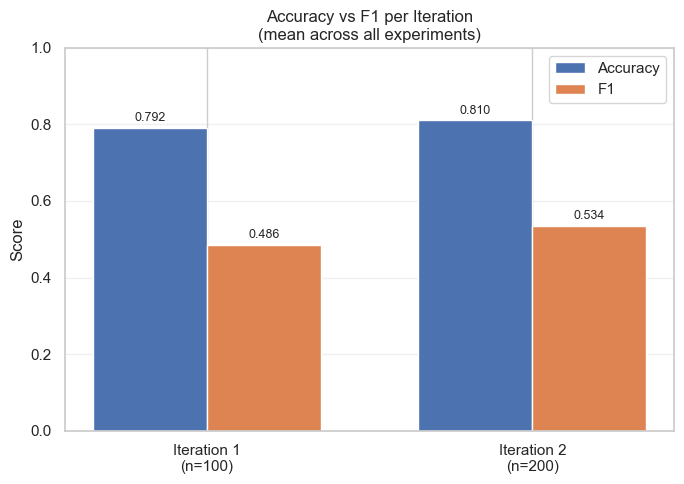

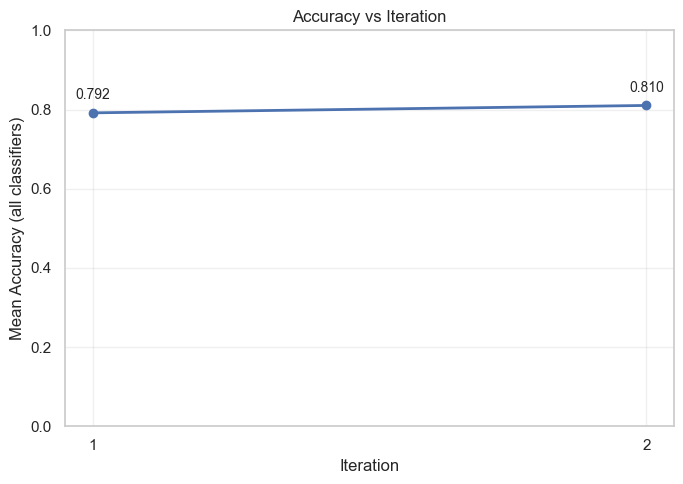

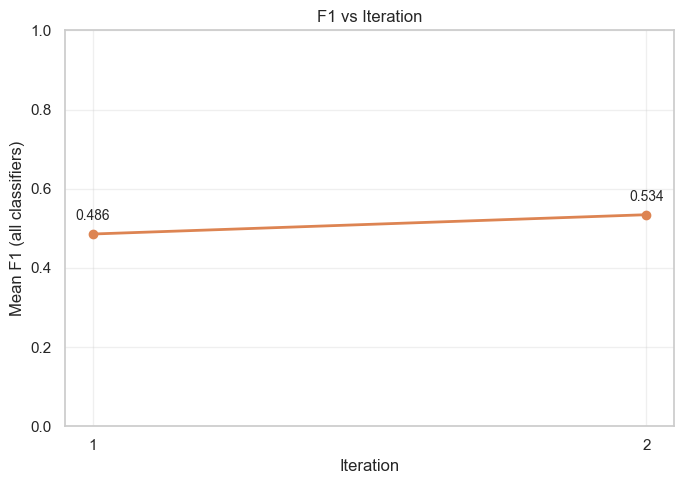

In [91]:
# Step 6.5 - Accuracy vs F1, and per-metric trend graphs across iterations
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def find_results(iteration):
    """Locate experiments_results_iteration_{n}.csv regardless of folder case."""
    hits = glob.glob(os.path.join("Classification", "*",
                                  f"experiments_results_iteration_{iteration}.csv"))
    if not hits:
        raise FileNotFoundError(f"No results file for iteration {iteration}")
    return hits[0]

# Load every available iteration (1, 2, ... up to 5 if they exist)
frames = []
for it in range(1, 6):
    try:
        frames.append(pd.read_csv(find_results(it)))
    except FileNotFoundError:
        pass
df_exp = pd.concat(frames, ignore_index=True)

out_dir = os.path.dirname(find_results(2))
labeled_per_iter = {1: 100, 2: 200, 3: 300, 4: 400, 5: 500}

# Mean Accuracy and F1 per iteration (averaged over ALL experiments of that iteration)
per_iter = (df_exp.groupby("iteration")
                  .agg(mean_accuracy=("accuracy", "mean"),
                       mean_F1=("F1", "mean"),
                       n_experiments=("accuracy", "size"))
                  .reset_index()
                  .sort_values("iteration"))
per_iter["labeled_users"] = per_iter["iteration"].map(labeled_per_iter)

print("Per-iteration means (over all classifiers / feature sets / validation / balance / class modes):\n")
print(per_iter[["iteration", "labeled_users", "n_experiments",
                "mean_accuracy", "mean_F1"]].to_string(index=False))

iters = per_iter["iteration"].tolist()

# ============================================================
# Graph 1: Accuracy vs F1 per iteration (grouped bars)
# ============================================================
import numpy as np
x = np.arange(len(iters))
width = 0.35
fig1, ax1 = plt.subplots(figsize=(7, 5))
b_acc = ax1.bar(x - width/2, per_iter["mean_accuracy"], width, label="Accuracy", color="#4C72B0")
b_f1  = ax1.bar(x + width/2, per_iter["mean_F1"],       width, label="F1",       color="#DD8452")
for bars in (b_acc, b_f1):
    for b in bars:
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                 f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels([f"Iteration {i}\n(n={labeled_per_iter.get(i,'?')})" for i in iters])
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.0)
ax1.set_title("Accuracy vs F1 per Iteration\n(mean across all experiments)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)
fig1.tight_layout()
p1 = os.path.join(out_dir, "accuracy_vs_f1_per_iteration.png")
fig1.savefig(p1, bbox_inches="tight", dpi=120)
print(f"\nSaved: {p1}")

# ============================================================
# Graph 2: Accuracy vs iteration (line)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(per_iter["iteration"], per_iter["mean_accuracy"],
         marker="o", linewidth=2, color="#4C72B0")
for _, r in per_iter.iterrows():
    ax2.annotate(f"{r['mean_accuracy']:.3f}", (r["iteration"], r["mean_accuracy"]),
                 textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)
ax2.set_xticks(per_iter["iteration"])
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Mean Accuracy (all classifiers)")
ax2.set_ylim(0, 1.0)
ax2.set_title("Accuracy vs Iteration")
ax2.grid(alpha=0.3)
fig2.tight_layout()
p2 = os.path.join(out_dir, "accuracy_vs_iteration.png")
fig2.savefig(p2, bbox_inches="tight", dpi=120)
print(f"Saved: {p2}")

# ============================================================
# Graph 3: F1 vs iteration (line)
# ============================================================
fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.plot(per_iter["iteration"], per_iter["mean_F1"],
         marker="o", linewidth=2, color="#DD8452")
for _, r in per_iter.iterrows():
    ax3.annotate(f"{r['mean_F1']:.3f}", (r["iteration"], r["mean_F1"]),
                 textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)
ax3.set_xticks(per_iter["iteration"])
ax3.set_xlabel("Iteration")
ax3.set_ylabel("Mean F1 (all classifiers)")
ax3.set_ylim(0, 1.0)
ax3.set_title("F1 vs Iteration")
ax3.grid(alpha=0.3)
fig3.tight_layout()
p3 = os.path.join(out_dir, "f1_vs_iteration.png")
fig3.savefig(p3, bbox_inches="tight", dpi=120)
print(f"Saved: {p3}")

plt.show()


### הכנת משתמשים לא מתויגים לאיטרציה 3

בשלב זה אנו מתחילים את האיטרציה השלישית של תהליך הלמידה האקטיבית.

לאחר איטרציה 2 קיימים 200 משתמשים מתויגים: 100 משתמשים מאיטרציה 1 ועוד 100 משתמשים מאיטרציה 2.

כדי לבחור משתמשים חדשים לאיטרציה 3, יש להסיר מהדאטה המקורי את כל המשתמשים שכבר תויגו.

לאחר ההסרה מתקבל קובץ חדש של משתמשים שעדיין לא תויגו, ועליהם יופעל המודל באיטרציה הבאה.

### Preparing Unlabeled Users for Iteration 3

In this step, we start the third active learning iteration.

After Iteration 2, we have 200 labeled users: 100 users from Iteration 1 and 100 users from Iteration 2.

To select new users for Iteration 3, we remove all already labeled users from the original dataset.

After this removal, a new unlabeled users file is created. This file will be used for the next prediction and uncertainty-based selection step.

In [4]:
# Step 6.6 - Prepare unlabeled users for Iteration 3

import pandas as pd
import os

ITERATION = 3

# Output directory for Iteration 3
out_dir = "Classification/iteration_3"
os.makedirs(out_dir, exist_ok=True)

# Input files
all_users_path = "Data/final_israeli_users.xlsx"
iteration_2_consensus_path = "Classification/iteration_2/iteration_2_labels_consensus.csv"

# Output file
unlabeled_iter3_path = os.path.join(out_dir, f"iteration_{ITERATION}_unlabeled_users.csv")

# Load all users
df_users = pd.read_excel(all_users_path)
df_users.columns = df_users.columns.str.strip()
df_users["username"] = df_users["username"].astype(str).str.strip()

# Load all labeled users up to Iteration 2
df_labeled_until_iter2 = pd.read_csv(iteration_2_consensus_path)
df_labeled_until_iter2.columns = df_labeled_until_iter2.columns.str.strip()
df_labeled_until_iter2["username"] = df_labeled_until_iter2["username"].astype(str).str.strip()

# Validate labeled data
labeled_usernames = set(df_labeled_until_iter2["username"])

print("Total users in original data:", len(df_users))
print("Labeled users up to Iteration 2:", len(labeled_usernames))

# Remove all users already labeled in Iteration 1 and Iteration 2
df_unlabeled_iter3 = df_users[
    ~df_users["username"].isin(labeled_usernames)
].copy()

# Safety checks
overlap_count = df_unlabeled_iter3["username"].isin(labeled_usernames).sum()
duplicate_count = df_unlabeled_iter3["username"].duplicated().sum()

if overlap_count != 0:
    raise ValueError(f"Overlap found: {overlap_count} already-labeled users still appear in Iteration 3 unlabeled data.")

if duplicate_count != 0:
    raise ValueError(f"Duplicate usernames found in Iteration 3 unlabeled data: {duplicate_count}")

# Save safely
if os.path.exists(unlabeled_iter3_path):
    print("Iteration 3 unlabeled users file already exists - NOT overwriting:")
    print(f"  {unlabeled_iter3_path}")
    df_unlabeled_iter3 = pd.read_csv(unlabeled_iter3_path)
else:
    df_unlabeled_iter3.to_csv(
        unlabeled_iter3_path,
        index=False,
        encoding="utf-8-sig"
    )
    print("Saved Iteration 3 unlabeled users file:")
    print(f"  {unlabeled_iter3_path}")

print("Unlabeled users for Iteration 3:", len(df_unlabeled_iter3))

display(df_unlabeled_iter3.head())

Total users in original data: 6965
Labeled users up to Iteration 2: 200
Saved Iteration 3 unlabeled users file:
  Classification/iteration_3\iteration_3_unlabeled_users.csv
Unlabeled users for Iteration 3: 6765


,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage
0,amit_segal,False,22500,46.0,834700.0,פרשן פוליטי | חדשות 12 וידיעות אחרונות | אבא ש...,jerusalem israel,joined february 2010,Israeli,1
1,DudyBornovski,False,828,337.0,10300.0,who’s your daddy,tel-aviv israel,joined may 2010,Israeli,2
2,RamiRamii20,False,0,11.0,161.0,שאל תדע,nazareth,joined january 2022,Israeli,1
3,irish4israel,True,24800,NaN,NaN,this acc is now closed . follow ireland’s new ...,ireland,joined december 2010,Israeli,3
4,FleurEast,False,22500,4727.0,222100.0,singing dancing and laughing my way through li...,NaN,joined september 2010,Israeli,3


# 6.7 - Train best model and predict on unlabeled users for Iteration 3

In [5]:
# Step 6.7 - Train best model and predict on unlabeled users for Iteration 3

import pandas as pd
import numpy as np
import os

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

ITERATION = 3
out_dir = "Classification/iteration_3"
os.makedirs(out_dir, exist_ok=True)

pred_path = os.path.join(out_dir, f"iteration_{ITERATION}_unlabeled_users_predictions.csv")

prediction_columns = [
    "predicted_class",
    "confidence_level",
    "prob_0",
    "prob_1",
    "prob_2",
    "uncertainty_score"
]

# SAFETY GUARD:
# If predictions already exist, load them instead of retraining and overwriting.
if os.path.exists(pred_path):
    print("Predictions file already exists - NOT overwriting (loading it instead):")
    print(f"  {pred_path}")

    df_pred = pd.read_csv(pred_path)

    missing_columns = [
        col for col in prediction_columns
        if col not in df_pred.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required prediction columns: {missing_columns}")

    print(f"Loaded {len(df_pred)} rows.")

else:
    def build_profile_text(df):
        return (
            df["username"].fillna("").astype(str) + " " +
            df["bio"].fillna("").astype(str) + " " +
            df["location"].fillna("").astype(str)
        )

    # --- 1. Load all users and Iteration 2 consensus labels (200 users) ---
    df_users = pd.read_excel("Data/final_israeli_users.xlsx")
    df_consensus = pd.read_csv("Classification/iteration_2/iteration_2_labels_consensus.csv")

    df_users.columns = df_users.columns.str.strip()
    df_consensus.columns = df_consensus.columns.str.strip()

    df_users["username"] = df_users["username"].astype(str).str.strip()
    df_consensus["username"] = df_consensus["username"].astype(str).str.strip()

    df_labeled = pd.merge(df_users, df_consensus, on="username", how="inner")

    assert len(df_labeled) == 200, f"Expected 200 labeled rows, got {len(df_labeled)}"

    df_labeled["profile_text"] = build_profile_text(df_labeled)

    # --- 2. Use the selected model for target_population ---
    # Same model family as Iteration 2: AdaBoost with balanced sample weights
    # and TF-IDF representation of profile_text.
    TARGET = "target_population"

    y = df_labeled[TARGET].astype(int)
    X_text = df_labeled["profile_text"]

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1, 2))),
        ("clf", AdaBoostClassifier(random_state=42)),
    ])

    sample_weights = compute_sample_weight(class_weight="balanced", y=y)
    pipeline.fit(X_text, y, clf__sample_weight=sample_weights)

    classes = list(pipeline.named_steps["clf"].classes_)

    print("Model trained on", len(df_labeled), "labeled users.")
    print("Classes:", classes)

    # --- 3. Predict on all unlabeled users for Iteration 3 ---
    df_unlabeled = pd.read_csv("Classification/iteration_3/iteration_3_unlabeled_users.csv")
    df_unlabeled["profile_text"] = build_profile_text(df_unlabeled)

    proba = pipeline.predict_proba(df_unlabeled["profile_text"])

    for c in [0, 1, 2]:
        col = f"prob_{c}"

        if c in classes:
            df_unlabeled[col] = proba[:, classes.index(c)].round(4)
        else:
            df_unlabeled[col] = ""

    label_map = {
        0: "non_target",
        1: "target",
        2: "unknown"
    }

    pred_idx = proba.argmax(axis=1)

    df_unlabeled["predicted_class"] = [
        label_map[classes[i]]
        for i in pred_idx
    ]

    df_unlabeled["confidence_level"] = proba.max(axis=1).round(4)
    df_unlabeled["uncertainty_score"] = (
        1 - df_unlabeled["confidence_level"]
    ).round(4)

    info_cols = [
        c for c in df_unlabeled.columns
        if c not in prediction_columns + ["profile_text"]
    ]

    df_pred = df_unlabeled[info_cols + prediction_columns].copy()

    df_pred = (
        df_pred
        .sort_values("uncertainty_score", ascending=False)
        .reset_index(drop=True)
    )

    df_pred.to_csv(pred_path, index=False, encoding="utf-8-sig")

    print(f"\nSaved predictions: {pred_path}  ({len(df_pred)} rows)")
    print("Predicted class distribution:")
    print(df_pred["predicted_class"].value_counts())

display(
    df_pred[
        [
            "username",
            "is_private",
            "posts",
            "following",
            "followers",
            "bio",
            "location",
            "join_date",
            "is_israeli",
            "classifier_stage",
            "predicted_class",
            "confidence_level",
            "prob_0",
            "prob_1",
            "prob_2",
            "uncertainty_score"
        ]
    ].head()
)

Model trained on 200 labeled users.
Classes: [np.int64(0), np.int64(1), np.int64(2)]

Saved predictions: Classification/iteration_3\iteration_3_unlabeled_users_predictions.csv  (6765 rows)
Predicted class distribution:
predicted_class
target        5812
non_target     872
unknown         81
Name: count, dtype: int64


,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,predicted_class,confidence_level,prob_0,prob_1,prob_2,uncertainty_score
0,brandoneliscott,False,5527,60.0,21700.0,explorer. photographer. herbalist. artist. i s...,ohio usa,joined february 2012,Israeli,3,target,0.3348,0.3343,0.3348,0.3309,0.6652
1,GermanosPeter,False,21200,6703.0,114400.0,lawyer conservative catholic j.d.writer of sev...,beirut,joined march 2020,Israeli,3,non_target,0.3348,0.3348,0.3321,0.3331,0.6652
2,liorz,False,8027,276.0,13800.0,i'm a father crowd-wisdom researcher author pr...,israel,joined august 2007,Israeli,2,target,0.3350,0.3329,0.3350,0.3321,0.6650
3,dmauas,False,1418,195.0,81.0,and we won't give it a name.\nwe'll just call ...,israel,joined may 2010,Israeli,2,target,0.3350,0.3329,0.3350,0.3321,0.6650
4,rubenanguiano,False,241100,5118.0,3924.0,arquitecto constructor diseñador escritor empr...,juárez cuauhtémoc,joined october 2008,Israeli,3,target,0.3362,0.3359,0.3362,0.3279,0.6638


### 6.8: בחירת משתמשים לתיוג ידני באיטרציה 3

בשלב זה אנו משתמשים בתחזיות של המודל שאומן על 200 המשתמשים המתויגים מאיטרציות 1 ו־2.

המודל מופעל על המשתמשים שעדיין לא תויגו, ולאחר מכן אנו בוחרים את 100 המשתמשים בעלי ציון חוסר הוודאות הגבוה ביותר.

משתמשים אלו הם המקרים שבהם המודל הכי פחות בטוח בתחזית שלו, ולכן תיוג ידני שלהם צפוי לשפר את המודל באיטרציה הבאה.

קובץ התיוג שנוצר כולל גם את תחזית המודל, רמת הביטחון, הסתברויות המחלקות וציון חוסר הוודאות, כדי לסייע בבקרה ובהבנת תהליך הבחירה.

### Selecting Users for Manual Labeling in Iteration 3

In this step, we use the predictions of the model trained on the 200 labeled users from Iterations 1 and 2.

The model is applied to the remaining unlabeled users, and we select the 100 users with the highest uncertainty score.

These users are the cases where the model is least confident, so manually labeling them is expected to improve the model in the next iteration.

The generated labeling file includes the model prediction, confidence level, class probabilities, and uncertainty score in order to support review and explain the selection process.

In [6]:
# Step 6.8 - Select the 100 most uncertain users for Iteration 3 manual labeling

import pandas as pd
import os

ITERATION = 3
out_dir = "Classification/iteration_3"

pred_path = os.path.join(
    out_dir,
    f"iteration_{ITERATION}_unlabeled_users_predictions.csv"
)

template_path = os.path.join(
    out_dir,
    f"iteration_{ITERATION}_users_to_label.csv"
)

# Load prediction file
df_pred = pd.read_csv(pred_path)

# Required prediction columns according to the project requirements
required_prediction_columns = [
    "predicted_class",
    "confidence_level",
    "prob_0",
    "prob_1",
    "prob_2",
    "uncertainty_score"
]

missing_columns = [
    col for col in required_prediction_columns
    if col not in df_pred.columns
]

if missing_columns:
    raise ValueError(f"Missing required prediction columns: {missing_columns}")

# Select the 100 users with the highest uncertainty score
top100 = (
    df_pred
    .sort_values("uncertainty_score", ascending=False)
    .head(100)
    .reset_index(drop=True)
)

# Keep useful information for manual labeling
keep_info = [
    c for c in [
        "username",
        "bio",
        "location",
        "predicted_class",
        "confidence_level",
        "prob_0",
        "prob_1",
        "prob_2",
        "uncertainty_score"
    ]
    if c in top100.columns
]

# Manual label columns to be filled by the annotators
label_cols = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization",
    "comments"
]

template = top100[keep_info].copy()

for col in label_cols:
    template[col] = ""

# Safety guard: do not overwrite existing manual labeling file
if os.path.exists(template_path):
    print("Iteration 3 labeling file already exists - NOT overwriting:")
    print(f"  {template_path}")
    print("To regenerate a blank template, delete this file manually first.")
    template = pd.read_csv(template_path)
else:
    template.to_csv(
        template_path,
        index=False,
        encoding="utf-8-sig"
    )
    print("Saved Iteration 3 labeling template:")
    print(f"  {template_path}")
    print("Users selected for manual labeling:", len(template))

print("Columns:", template.columns.tolist())

print("\nFill in each user manually:")
print("  target_population:       1=target, 0=non_target, 2=unknown")
print("  locals_vs_diaspora:      1=local,  0=diaspora,   2=unknown")
print("  person_vs_organization:  1=person, 0=organization, 2=unknown")

display(template.head())

Saved Iteration 3 labeling template:
  Classification/iteration_3\iteration_3_users_to_label.csv
Users selected for manual labeling: 100
Columns: ['username', 'bio', 'location', 'predicted_class', 'confidence_level', 'prob_0', 'prob_1', 'prob_2', 'uncertainty_score', 'target_population', 'locals_vs_diaspora', 'person_vs_organization', 'comments']

Fill in each user manually:
  target_population:       1=target, 0=non_target, 2=unknown
  locals_vs_diaspora:      1=local,  0=diaspora,   2=unknown
  person_vs_organization:  1=person, 0=organization, 2=unknown


,username,bio,location,predicted_class,confidence_level,prob_0,prob_1,prob_2,uncertainty_score,target_population,locals_vs_diaspora,person_vs_organization,comments
0,brandoneliscott,explorer. photographer. herbalist. artist. i s...,ohio usa,target,0.3348,0.3343,0.3348,0.3309,0.6652,,,,
1,GermanosPeter,lawyer conservative catholic j.d.writer of sev...,beirut,non_target,0.3348,0.3348,0.3321,0.3331,0.6652,,,,
2,liorz,i'm a father crowd-wisdom researcher author pr...,israel,target,0.3350,0.3329,0.3350,0.3321,0.6650,,,,
3,dmauas,and we won't give it a name.\nwe'll just call ...,israel,target,0.3350,0.3329,0.3350,0.3321,0.6650,,,,
4,rubenanguiano,arquitecto constructor diseñador escritor empr...,juárez cuauhtémoc,target,0.3362,0.3359,0.3362,0.3279,0.6638,,,,


### 6.9: יצירת קבצי תיוג ידני לאיטרציה 3

לאחר סיום התיוג הידני של 100 המשתמשים שנבחרו לאיטרציה 3, אנו בודקים שכל שורות התיוג מלאות ותקינות.

בשלב זה נבדק שכל אחת משלוש עמודות הסיווג כוללת רק ערכים חוקיים: 0, 1 או 2.

לאחר הבדיקה, אנו מפיקים שלושה קבצי תיוג נפרדים, אחד לכל משימת סיווג:
target_population, locals_vs_diaspora, person_vs_organization.

קבצים אלו ישמשו בהמשך לחיבור הדאטה המתויג של איטרציות 1, 2 ו־3 וליצירת קובץ consensus מאוחד של 300 משתמשים.

### Creating Manual Label Files for Iteration 3

After completing the manual labeling of the 100 users selected for Iteration 3, we validate that all label fields are complete and valid.

In this step, we verify that each of the three classification columns contains only valid values: 0, 1, or 2.

After validation, we create three separate manual label files, one for each classification task:
target_population, locals_vs_diaspora, and person_vs_organization.

These files will later be used to combine the labeled data from Iterations 1, 2, and 3 into a unified consensus file of 300 users.

In [7]:
# Step 6.9 - Create Iteration 3 manual label files

import pandas as pd
import os

ITERATION = 3
out_dir = "Classification/iteration_3"

template_path = os.path.join(
    out_dir,
    f"iteration_{ITERATION}_users_to_label.csv"
)

target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

if not os.path.exists(template_path):
    raise FileNotFoundError(f"Iteration 3 labeling file was not found: {template_path}")

labels = pd.read_csv(template_path)

# Clean column names
labels.columns = labels.columns.str.strip()

# Validate required columns
required_columns = ["username", "bio", "location"] + target_columns

missing_columns = [
    col for col in required_columns
    if col not in labels.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Convert labels to numeric values
for col in target_columns:
    labels[col] = pd.to_numeric(labels[col], errors="coerce")

# Check missing labels
if labels[target_columns].isna().any().any():
    n_missing = int(labels[target_columns].isna().any(axis=1).sum())
    raise ValueError(
        f"Manual labeling is not complete. "
        f"{n_missing} rows still have missing labels."
    )

# Check valid label values
for col in target_columns:
    invalid_values = sorted(
        set(labels[col].dropna().astype(int)) - {0, 1, 2}
    )
    
    if invalid_values:
        raise ValueError(
            f"Invalid label values found in {col}: {invalid_values}. "
            "Allowed values are only 0, 1, 2."
        )

# Check duplicate usernames
duplicate_count = labels["username"].duplicated().sum()

if duplicate_count != 0:
    raise ValueError(f"Duplicate usernames found: {duplicate_count}")

print("Iteration 3 manual labeling file is valid.")
print("Rows:", len(labels))

# Create one manual-label file per classification task
for col in target_columns:
    output_columns = [
        c for c in ["username", "bio", "location"]
        if c in labels.columns
    ]

    out = labels[output_columns + [col]].copy()
    out[col] = out[col].astype(int)

    if "comments" in labels.columns:
        out["comments"] = labels["comments"]

    out["iteration"] = ITERATION

    ml_path = os.path.join(
        out_dir,
        f"iteration_{ITERATION}_manual_labels_{col}.csv"
    )

    # Safety guard: do not overwrite if already exists
    if os.path.exists(ml_path):
        print(f"Manual labels file already exists - NOT overwriting: {ml_path}")
        continue

    out.to_csv(
        ml_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"Saved manual labels: {ml_path} "
        f"({len(out)} users) | "
        f"distribution: {out[col].value_counts().sort_index().to_dict()}"
    )

Iteration 3 manual labeling file is valid.
Rows: 100
Saved manual labels: Classification/iteration_3\iteration_3_manual_labels_target_population.csv (100 users) | distribution: {0: 27, 1: 64, 2: 9}
Saved manual labels: Classification/iteration_3\iteration_3_manual_labels_locals_vs_diaspora.csv (100 users) | distribution: {0: 38, 1: 56, 2: 6}
Saved manual labels: Classification/iteration_3\iteration_3_manual_labels_person_vs_organization.csv (100 users) | distribution: {0: 8, 1: 89, 2: 3}


### 6.10: יצירת קובץ Consensus לאיטרציה 3

בשלב זה אנו מחברים את כל המשתמשים שתויגו עד סוף איטרציה 3.

קובץ ה־consensus של איטרציה 2 כולל 200 משתמשים מתויגים: 100 מאיטרציה 1 ועוד 100 מאיטרציה 2.

לאחר מכן אנו מוסיפים את 100 המשתמשים החדשים שתויגו ידנית באיטרציה 3.

התוצאה היא קובץ consensus מאוחד של 300 משתמשים מתויגים.

לפני השמירה מתבצעות בדיקות תקינות: בדיקה שאין ערכים חסרים, שכל ערכי התיוג הם רק 0, 1 או 2, ושאין כפילויות בשמות המשתמשים.

קובץ זה ישמש כבסיס לאימון מחדש של המודלים באיטרציה 3.

### Creating the Iteration 3 Consensus File

In this step, we combine all users labeled up to the end of Iteration 3.

The Iteration 2 consensus file contains 200 labeled users: 100 from Iteration 1 and 100 from Iteration 2.

We then add the 100 newly labeled users from Iteration 3.

The result is a unified consensus file containing 300 labeled users.

Before saving the file, validation checks are performed to ensure that there are no missing labels, that all label values are only 0, 1, or 2, and that there are no duplicate usernames.

This file will be used as the training data for retraining the models in Iteration 3.

In [8]:
# Step 6.10 - Create Iteration 3 consensus file with 300 labeled users

import pandas as pd
import os

ITERATION = 3

iter2_dir = "Classification/iteration_2"
iter3_dir = "Classification/iteration_3"

iter2_consensus_path = os.path.join(iter2_dir, "iteration_2_labels_consensus.csv")
iter3_users_to_label_path = os.path.join(iter3_dir, "iteration_3_users_to_label.csv")

iter3_consensus_path = os.path.join(iter3_dir, "iteration_3_labels_consensus.csv")

target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# Load Iteration 2 consensus file: 200 labeled users
if not os.path.exists(iter2_consensus_path):
    raise FileNotFoundError(f"Iteration 2 consensus file was not found: {iter2_consensus_path}")

df_iter2 = pd.read_csv(iter2_consensus_path)
df_iter2.columns = df_iter2.columns.str.strip()
df_iter2["username"] = df_iter2["username"].astype(str).str.strip()

# Load Iteration 3 manually labeled users: 100 new labeled users
if not os.path.exists(iter3_users_to_label_path):
    raise FileNotFoundError(f"Iteration 3 users-to-label file was not found: {iter3_users_to_label_path}")

df_iter3_new = pd.read_csv(iter3_users_to_label_path)
df_iter3_new.columns = df_iter3_new.columns.str.strip()
df_iter3_new["username"] = df_iter3_new["username"].astype(str).str.strip()

# Validate required columns
required_columns = ["username"] + target_columns

for df_name, df in [("Iteration 2 consensus", df_iter2), ("Iteration 3 labels", df_iter3_new)]:
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(f"{df_name} is missing required columns: {missing_columns}")

# Keep only the required label columns
df_iter2_clean = df_iter2[required_columns].copy()
df_iter3_clean = df_iter3_new[required_columns].copy()

# Convert labels to numeric and validate values
for df_name, df in [("Iteration 2 consensus", df_iter2_clean), ("Iteration 3 labels", df_iter3_clean)]:
    for col in target_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if df[target_columns].isna().any().any():
        n_missing = int(df[target_columns].isna().any(axis=1).sum())
        raise ValueError(f"{df_name} has {n_missing} rows with missing labels.")

    for col in target_columns:
        invalid_values = sorted(
            set(df[col].dropna().astype(int)) - {0, 1, 2}
        )

        if invalid_values:
            raise ValueError(
                f"{df_name} has invalid values in {col}: {invalid_values}. "
                "Allowed values are only 0, 1, 2."
            )

        df[col] = df[col].astype(int)

# Add source information
df_iter2_clean["source_consensus"] = "iteration_2_consensus"
df_iter3_clean["source_consensus"] = "iteration_3_manual_labeling"

# Combine 200 old labeled users + 100 new labeled users
df_iter3_consensus = pd.concat(
    [df_iter2_clean, df_iter3_clean],
    ignore_index=True
)

# Safety checks
duplicate_count = df_iter3_consensus["username"].duplicated().sum()

if duplicate_count != 0:
    duplicated_users = df_iter3_consensus[
        df_iter3_consensus["username"].duplicated(keep=False)
    ]["username"].tolist()

    raise ValueError(
        f"Duplicate usernames found in Iteration 3 consensus: {duplicate_count}. "
        f"Examples: {duplicated_users[:10]}"
    )

if len(df_iter3_consensus) != 300:
    raise ValueError(
        f"Expected 300 labeled users in Iteration 3 consensus, "
        f"got {len(df_iter3_consensus)}."
    )

# Save consensus safely
if os.path.exists(iter3_consensus_path):
    print("Iteration 3 consensus file already exists - NOT overwriting:")
    print(f"  {iter3_consensus_path}")
    df_iter3_consensus = pd.read_csv(iter3_consensus_path)
else:
    df_iter3_consensus.to_csv(
        iter3_consensus_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved Iteration 3 consensus file:")
    print(f"  {iter3_consensus_path}")

print("Rows in Iteration 3 consensus:", len(df_iter3_consensus))
print("Unique usernames:", df_iter3_consensus["username"].nunique())

print("\nClass distributions in Iteration 3 consensus:")
for col in target_columns:
    print(f"\n{col}:")
    print(df_iter3_consensus[col].value_counts().sort_index())

display(df_iter3_consensus.head())

Saved Iteration 3 consensus file:
  Classification/iteration_3\iteration_3_labels_consensus.csv
Rows in Iteration 3 consensus: 300
Unique usernames: 300

Class distributions in Iteration 3 consensus:

target_population:
target_population
0     65
1    220
2     15
Name: count, dtype: int64

locals_vs_diaspora:
locals_vs_diaspora
0     84
1    204
2     12
Name: count, dtype: int64

person_vs_organization:
person_vs_organization
0     31
1    263
2      6
Name: count, dtype: int64


,username,target_population,locals_vs_diaspora,person_vs_organization,source_consensus
0,Roy_Iddan,1,1,1,iteration_2_consensus
1,RayneNGrace,0,0,1,iteration_2_consensus
2,shirellaloom,1,1,1,iteration_2_consensus
3,raananshaked,1,1,1,iteration_2_consensus
4,IsraelMOH,1,1,0,iteration_2_consensus


### 6.11: יצירת קבצי יעד נפרדים לאיטרציה 3

לאחר יצירת קובץ ה־consensus המאוחד של איטרציה 3, אנו מפיקים ממנו שלושה קבצי יעד נפרדים.

כל קובץ מתאים למשימת סיווג אחת:
target_population, locals_vs_diaspora, person_vs_organization.

קבצים אלו שומרים את פרטי המשתמשים ואת עמודת הסיווג הרלוונטית בלבד, וישמשו בהמשך לאימון ולהערכת המודלים באיטרציה 3.

### Creating Separate Target Files for Iteration 3

After creating the unified Iteration 3 consensus file, we generate three separate target files.

Each file corresponds to one classification task:
target_population, locals_vs_diaspora, and person_vs_organization.

These files contain the user information and the relevant target column, and will be used for model training and evaluation in Iteration 3.

In [9]:
# Step 6.11 - Create Iteration 3 target files

import pandas as pd
import os

ITERATION = 3
iter3_dir = "Classification/iteration_3"

consensus_path = os.path.join(
    iter3_dir,
    f"iteration_{ITERATION}_labels_consensus.csv"
)

target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

if not os.path.exists(consensus_path):
    raise FileNotFoundError(f"Iteration 3 consensus file was not found: {consensus_path}")

df_consensus = pd.read_csv(consensus_path)
df_consensus.columns = df_consensus.columns.str.strip()

required_columns = ["username"] + target_columns

missing_columns = [
    col for col in required_columns
    if col not in df_consensus.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns in consensus file: {missing_columns}")

print("Loaded Iteration 3 consensus file.")
print("Rows:", len(df_consensus))
print("Unique usernames:", df_consensus["username"].nunique())

for target_col in target_columns:
    output_path = os.path.join(
        iter3_dir,
        f"iteration_{ITERATION}_{target_col}.csv"
    )

    output_columns = ["username"]

    for optional_col in ["bio", "location", "comments", "source_consensus"]:
        if optional_col in df_consensus.columns:
            output_columns.append(optional_col)

    output_columns.append(target_col)

    df_target = df_consensus[output_columns].copy()

    df_target[target_col] = pd.to_numeric(
        df_target[target_col],
        errors="coerce"
    )

    if df_target[target_col].isna().any():
        raise ValueError(f"Missing labels found in {target_col}")

    df_target[target_col] = df_target[target_col].astype(int)

    invalid_values = sorted(
        set(df_target[target_col].dropna().astype(int)) - {0, 1, 2}
    )

    if invalid_values:
        raise ValueError(
            f"Invalid values found in {target_col}: {invalid_values}. "
            "Allowed values are only 0, 1, 2."
        )

    if os.path.exists(output_path):
        print(f"Target file already exists - NOT overwriting: {output_path}")
        continue

    df_target.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"Saved target file: {output_path} "
        f"({len(df_target)} users) | "
        f"distribution: {df_target[target_col].value_counts().sort_index().to_dict()}"
    )

Loaded Iteration 3 consensus file.
Rows: 300
Unique usernames: 300
Saved target file: Classification/iteration_3\iteration_3_target_population.csv (300 users) | distribution: {0: 65, 1: 220, 2: 15}
Saved target file: Classification/iteration_3\iteration_3_locals_vs_diaspora.csv (300 users) | distribution: {0: 84, 1: 204, 2: 12}
Saved target file: Classification/iteration_3\iteration_3_person_vs_organization.csv (300 users) | distribution: {0: 31, 1: 263, 2: 6}


### step 6.12: הרצת ניסויי מודלים עבור איטרציה 3

בשלב זה אנו מריצים מחדש את כל ניסויי המודלים על קובץ ה־consensus של איטרציה 3, הכולל 300 משתמשים מתויגים.

המטרה היא לבדוק האם הוספת 100 המשתמשים החדשים מאיטרציה 3 שיפרה את ביצועי המודלים.

אנו משתמשים באותו מבנה ניסויים כמו באיטרציות הקודמות: שלוש משימות סיווג, שתי אפשרויות מחלקות, מספר אלגוריתמים, מספר ייצוגי פיצ׳רים, K-Fold, LOOCV, ואימון עם ובלי איזון מחלקות.

תוצאות הניסויים נשמרות בקובץ experiments_results_iteration_3.csv.

### Running Model Experiments for Iteration 3

In this step, we rerun the full model experiment table using the Iteration 3 consensus file, which contains 300 labeled users.

The goal is to check whether adding the 100 newly labeled users from Iteration 3 improved the model performance.

We use the same experiment structure as in the previous iterations: three classification tasks, two class settings, multiple algorithms, multiple feature representations, K-Fold, LOOCV, and training with and without class balancing.

The experiment results are saved in experiments_results_iteration_3.csv.

In [10]:
# Step 6.12 - Rerun the full Step-5 experiment table on the Iteration 3 dataset (300 users)
# RUN_EXPERIMENTS = False loads the saved results if they already exist.
# If the results file does not exist, the experiments will run and create it.
# Running all experiments may take around 20-30 minutes.

import os
import pandas as pd

RUN_EXPERIMENTS = False

ITERATION = 3
results_path = f"Classification/iteration_{ITERATION}/experiments_results_iteration_{ITERATION}.csv"

if not RUN_EXPERIMENTS and os.path.exists(results_path):
    print("Experiment results file already exists. Loading:", results_path)

    df_experiments_iter3 = pd.read_csv(results_path)

    print("Loaded experiment results rows:", len(df_experiments_iter3))

    display(df_experiments_iter3.head())

else:
    print("Running model training experiments on the 300-user Iteration 3 dataset...")

    import numpy as np
    import warnings

    from sklearn.model_selection import StratifiedKFold, LeaveOneOut
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.utils.class_weight import compute_sample_weight

    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.svm import LinearSVC

    warnings.filterwarnings("ignore")

    try:
        from xgboost import XGBClassifier
        xgboost_available = True
    except ImportError:
        xgboost_available = False
        print("XGBoost is not installed. XGBoost experiments will be skipped.")

    # ------------------------------------------------------------
    # Build the 300-user model dataframe from the Iteration 3 consensus
    # ------------------------------------------------------------
    df_users = pd.read_excel("Data/final_israeli_users.xlsx")
    df_users.columns = df_users.columns.str.strip()
    df_users["username"] = df_users["username"].astype(str).str.strip()

    df_cons = pd.read_csv(
        f"Classification/iteration_{ITERATION}/iteration_{ITERATION}_labels_consensus.csv"
    )
    df_cons.columns = df_cons.columns.str.strip()
    df_cons["username"] = df_cons["username"].astype(str).str.strip()

    df_model = pd.merge(df_users, df_cons, on="username", how="inner")

    assert len(df_model) == 300, f"Expected 300 labeled rows, got {len(df_model)}"

    target_columns = [
        "target_population",
        "locals_vs_diaspora",
        "person_vs_organization"
    ]

    numeric_features = [
        "is_private",
        "posts",
        "following",
        "followers"
    ]

    for c in ["username", "bio", "location"]:
        df_model[c] = df_model[c].fillna("").astype(str)

    df_model["profile_text"] = (
        df_model["username"] + " " +
        df_model["bio"] + " " +
        df_model["location"]
    )

    for c in numeric_features:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

    df_model["is_private"] = df_model["is_private"].fillna(0).astype(int)
    df_model[numeric_features] = df_model[numeric_features].fillna(0)

    for c in target_columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").astype(int)

    # ------------------------------------------------------------
    # Feature sets
    # ------------------------------------------------------------
    feature_sets = {
        "TFIDF_profile_text": {
            "columns": ["profile_text"],
            "numeric": [],
            "count_features": 500
        },
        "TFIDF_profile_text+numeric_metadata": {
            "columns": ["profile_text"] + numeric_features,
            "numeric": numeric_features,
            "count_features": 500 + len(numeric_features)
        }
    }

    def build_preprocessor(feature_set_name):
        config = feature_sets[feature_set_name]

        transformers = [
            (
                "text",
                TfidfVectorizer(max_features=500, ngram_range=(1, 2)),
                "profile_text"
            )
        ]

        if len(config["numeric"]) > 0:
            transformers.append(
                (
                    "numeric",
                    StandardScaler(),
                    config["numeric"]
                )
            )

        return ColumnTransformer(transformers=transformers)

    def get_models(balanced):
        class_weight_value = "balanced" if balanced else None

        models = {
            "LogReg": LogisticRegression(
                max_iter=1000,
                class_weight=class_weight_value,
                random_state=42
            ),
            "Decision Tree": DecisionTreeClassifier(
                class_weight=class_weight_value,
                random_state=42
            ),
            "Random Forest": RandomForestClassifier(
                n_estimators=100,
                class_weight=class_weight_value,
                random_state=42
            ),
            "SVM": LinearSVC(
                class_weight=class_weight_value,
                random_state=42
            ),
            "AdaBoost": AdaBoostClassifier(
                random_state=42
            ),
        }

        if xgboost_available:
            models["XGBoost"] = XGBClassifier(
                random_state=42,
                eval_metric="mlogloss"
            )

        return models

    def safe_auc_score(y_true, y_score, classes):
        try:
            unique_classes = np.unique(y_true)

            if len(unique_classes) < 2:
                return np.nan

            if len(classes) == 2:
                if len(y_score.shape) == 2:
                    return roc_auc_score(y_true, y_score[:, 1])
                else:
                    return roc_auc_score(y_true, y_score)

            if len(classes) == 3:
                if len(y_score.shape) == 2 and y_score.shape[1] == len(classes):
                    return roc_auc_score(
                        y_true,
                        y_score,
                        multi_class="ovr",
                        average="macro",
                        labels=classes
                    )

            return np.nan

        except Exception:
            return np.nan

    def evaluate_model_cv(X, y, pipeline, cv, balanced, model_name):
        y_true_all = []
        y_pred_all = []
        y_score_all = []

        classes = np.sort(y.unique())

        for train_index, test_index in cv.split(X, y):
            X_train = X.iloc[train_index]
            X_test = X.iloc[test_index]

            y_train = y.iloc[train_index]
            y_test = y.iloc[test_index]

            if balanced and model_name in ["AdaBoost", "XGBoost"]:
                sample_weights = compute_sample_weight(
                    class_weight="balanced",
                    y=y_train
                )

                pipeline.fit(
                    X_train,
                    y_train,
                    classifier__sample_weight=sample_weights
                )
            else:
                pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_test)

            y_score = None

            if hasattr(pipeline, "predict_proba"):
                try:
                    y_score = pipeline.predict_proba(X_test)
                except Exception:
                    y_score = None

            if y_score is None and hasattr(pipeline, "decision_function"):
                try:
                    y_score = pipeline.decision_function(X_test)
                except Exception:
                    y_score = None

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            if y_score is not None:
                if y_score_all is not None:
                    y_score_all.extend(np.array(y_score).tolist())
            else:
                y_score_all = None

        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)

        accuracy = accuracy_score(y_true_all, y_pred_all)

        precision = precision_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        )

        f1 = f1_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        )

        if y_score_all is not None:
            auc = safe_auc_score(
                y_true_all,
                np.array(y_score_all),
                classes
            )
        else:
            auc = np.nan

        return accuracy, precision, recall, f1, auc

    # ------------------------------------------------------------
    # Run all required experiments
    # ------------------------------------------------------------
    experiment_results = []

    for target_col in target_columns:
        for class_mode in ["3_classes", "2_classes_without_unknown"]:

            if class_mode == "3_classes":
                df_task = df_model.copy()
            else:
                df_task = df_model[df_model[target_col] != 2].copy()

            X_base = df_task[["profile_text"] + numeric_features].reset_index(drop=True)
            y_base = df_task[target_col].astype(int).reset_index(drop=True)

            class_counts = y_base.value_counts().to_dict()

            count_class_0 = class_counts.get(0, 0)
            count_class_1 = class_counts.get(1, 0)
            count_class_2 = class_counts.get(2, 0)

            classes_number = y_base.nunique()
            min_class_size = min(class_counts.values())

            print(
                f"\nTarget: {target_col} | Mode: {class_mode} | counts: {class_counts}",
                flush=True
            )

            for feature_set_name, feature_config in feature_sets.items():
                X = X_base[feature_config["columns"]]

                for balanced in [False, True]:
                    models = get_models(balanced)

                    for algorithm_name, model in models.items():
                        validation_methods = [
                            (
                                "K-Fold",
                                5,
                                StratifiedKFold(
                                    n_splits=5,
                                    shuffle=True,
                                    random_state=42
                                )
                            ),
                            (
                                "LOOCV",
                                "",
                                LeaveOneOut()
                            ),
                        ]

                        for training_type, K_value, cv in validation_methods:
                            preprocessor = build_preprocessor(feature_set_name)

                            pipeline = Pipeline(
                                steps=[
                                    ("preprocessor", preprocessor),
                                    ("classifier", model)
                                ]
                            )

                            try:
                                accuracy, precision, recall, f1, auc = evaluate_model_cv(
                                    X=X,
                                    y=y_base,
                                    pipeline=pipeline,
                                    cv=cv,
                                    balanced=balanced,
                                    model_name=algorithm_name
                                )

                                experiment_results.append({
                                    "iteration": ITERATION,
                                    "target_column": target_col,
                                    "#classes": classes_number,
                                    "#class_0": count_class_0,
                                    "#class_1": count_class_1,
                                    "#class_2": count_class_2 if classes_number == 3 else 0,
                                    "min_class_size": min_class_size,
                                    "training_type": training_type,
                                    "K": K_value,
                                    "algorithm": algorithm_name,
                                    "feature_set": feature_set_name,
                                    "Features_count": feature_config["count_features"],
                                    "balanced": balanced,
                                    "accuracy": round(accuracy, 4),
                                    "precision": round(precision, 4),
                                    "recall": round(recall, 4),
                                    "F1": round(f1, 4),
                                    "AUC": round(auc, 4) if not pd.isna(auc) else "",
                                })

                            except Exception as error:
                                print(
                                    f"Experiment FAILED: "
                                    f"target={target_col}, "
                                    f"mode={class_mode}, "
                                    f"features={feature_set_name}, "
                                    f"algo={algorithm_name}, "
                                    f"balanced={balanced}, "
                                    f"val={training_type} -> {error}",
                                    flush=True
                                )

    # ------------------------------------------------------------
    # Save results
    # ------------------------------------------------------------
    required_columns = [
        "iteration",
        "target_column",
        "#classes",
        "#class_0",
        "#class_1",
        "#class_2",
        "min_class_size",
        "training_type",
        "K",
        "algorithm",
        "feature_set",
        "Features_count",
        "balanced",
        "accuracy",
        "precision",
        "recall",
        "F1",
        "AUC"
    ]

    df_experiments = pd.DataFrame(experiment_results)[required_columns]

    df_experiments.to_csv(
        results_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"\nTotal experiments saved: {len(df_experiments)}")
    print(f"Saved to: {results_path}")

    df_experiments_iter3 = df_experiments

    display(df_experiments_iter3)

Running model training experiments on the 300-user Iteration 3 dataset...

Target: target_population | Mode: 3_classes | counts: {1: 220, 0: 65, 2: 15}

Target: target_population | Mode: 2_classes_without_unknown | counts: {1: 220, 0: 65}

Target: locals_vs_diaspora | Mode: 3_classes | counts: {1: 204, 0: 84, 2: 12}

Target: locals_vs_diaspora | Mode: 2_classes_without_unknown | counts: {1: 204, 0: 84}

Target: person_vs_organization | Mode: 3_classes | counts: {1: 263, 0: 31, 2: 6}

Target: person_vs_organization | Mode: 2_classes_without_unknown | counts: {1: 263, 0: 31}

Total experiments saved: 288
Saved to: Classification/iteration_3/experiments_results_iteration_3.csv


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,3,target_population,3,65,220,15,15,K-Fold,5,LogReg,TFIDF_profile_text,500,False,0.7600,0.4687,0.3960,0.3938,0.7459
1,3,target_population,3,65,220,15,15,LOOCV,,LogReg,TFIDF_profile_text,500,False,0.7633,0.4795,0.4048,0.4061,0.7289
2,3,target_population,3,65,220,15,15,K-Fold,5,Decision Tree,TFIDF_profile_text,500,False,0.7400,0.4327,0.4231,0.4248,0.5628
3,3,target_population,3,65,220,15,15,LOOCV,,Decision Tree,TFIDF_profile_text,500,False,0.7533,0.4516,0.4364,0.4395,0.5641
4,3,target_population,3,65,220,15,15,K-Fold,5,Random Forest,TFIDF_profile_text,500,False,0.7600,0.4632,0.3924,0.3880,0.6892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,3,person_vs_organization,2,31,263,0,31,LOOCV,,SVM,TFIDF_profile_text+numeric_metadata,504,True,0.8571,0.6137,0.6071,0.6102,0.6731
284,3,person_vs_organization,2,31,263,0,31,K-Fold,5,AdaBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8571,0.6462,0.6783,0.6595,0.7314
285,3,person_vs_organization,2,31,263,0,31,LOOCV,,AdaBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8027,0.5853,0.6336,0.5972,0.6952
286,3,person_vs_organization,2,31,263,0,31,K-Fold,5,XGBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8673,0.6320,0.6128,0.6212,0.7135


# Step 6.13 - Update unified experiment results file with Iteration 3

In [1]:
# Step 6.13 - Update unified experiment results file with Iteration 3

import pandas as pd
import os

iteration_1_results_path = "Classification/Iteration_1/experiments_results_iteration_1.csv"
iteration_2_results_path = "Classification/iteration_2/experiments_results_iteration_2.csv"
iteration_3_results_path = "Classification/iteration_3/experiments_results_iteration_3.csv"

all_results_path = "Classification/experiments_results_all_iterations.csv"

required_paths = [
    iteration_1_results_path,
    iteration_2_results_path,
    iteration_3_results_path
]

for path in required_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required experiment results file was not found: {path}")

df_iter1_results = pd.read_csv(iteration_1_results_path)
df_iter2_results = pd.read_csv(iteration_2_results_path)
df_iter3_results = pd.read_csv(iteration_3_results_path)

df_all_results = pd.concat(
    [
        df_iter1_results,
        df_iter2_results,
        df_iter3_results
    ],
    ignore_index=True
)

df_all_results.to_csv(
    all_results_path,
    index=False,
    encoding="utf-8-sig"
)

print("Unified experiment results file was updated successfully.")
print("Saved to:", all_results_path)
print("Total rows:", len(df_all_results))

print("\nRows by iteration:")
print(df_all_results["iteration"].value_counts().sort_index())

display(df_all_results.head())

Unified experiment results file was updated successfully.
Saved to: Classification/experiments_results_all_iterations.csv
Total rows: 864

Rows by iteration:
iteration
1    288
2    288
3    288
Name: count, dtype: int64


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,target_population,3,15,79,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.8042
1,1,target_population,3,15,79,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7133
2,1,target_population,3,15,79,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.78,0.3507,0.3471,0.3284,0.5849
3,1,target_population,3,15,79,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.77,0.3799,0.3609,0.3542,0.6269
4,1,target_population,3,15,79,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7291


### השוואת ביצועים בין איטרציות 1, 2 ו־3

בשלב זה אנו משווים את ביצועי המודלים בין שלוש האיטרציות הראשונות של תהליך הלמידה האקטיבית.

ההשוואה מתבצעת על בסיס קובץ התוצאות המאוחד, הכולל את כל הניסויים שבוצעו באיטרציות 1, 2 ו־3.

המטרה היא לבדוק האם הוספת משתמשים מתויגים חדשים בכל איטרציה שיפרה את ביצועי המודלים.

אנו מציגים את השינוי במדדי Accuracy ו־F1 לאורך האיטרציות, מכיוון ש־Accuracy מציג את רמת הדיוק הכללית, ו־F1 חשוב במיוחד כאשר התפלגות המחלקות אינה מאוזנת.

### Comparing Iterations 1, 2 and 3

In this step, we compare the model performance across the first three active learning iterations.

The comparison is based on the unified experiment results file, which contains all experiments from Iterations 1, 2 and 3.

The goal is to check whether adding newly labeled users in each iteration improved the model performance.

We visualize the changes in Accuracy and F1 across the iterations. Accuracy measures the overall correctness, while F1 is especially important when the class distribution is imbalanced.

Average performance by iteration:


,iteration,accuracy,F1
0,1,0.791729,0.485542
1,2,0.810441,0.534326
2,3,0.804701,0.551081


Best result by F1 for each iteration, target column, and class setting:


,iteration,target_column,#classes,algorithm,feature_set,training_type,balanced,accuracy,precision,recall,F1,AUC
0,1,locals_vs_diaspora,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,1,locals_vs_diaspora,3,AdaBoost,TFIDF_profile_text+numeric_metadata,K-Fold,False,0.8000,0.4697,0.4922,0.4805,0.5708
2,1,person_vs_organization,2,LogReg,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8351,0.7289,0.8260,0.7569,0.8804
3,1,person_vs_organization,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.9700,0.6548,0.6667,0.6606,0.6021
4,1,target_population,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8936,0.8091,0.7747,0.7902,0.7747
5,1,target_population,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.8100,0.8064,0.4471,0.4920,0.6432
6,2,locals_vs_diaspora,2,SVM,TFIDF_profile_text,K-Fold,True,0.8866,0.8545,0.8208,0.8357,0.8691
7,2,locals_vs_diaspora,3,LogReg,TFIDF_profile_text,LOOCV,True,0.8450,0.5427,0.5454,0.5440,0.6557
8,2,person_vs_organization,2,LogReg,TFIDF_profile_text+numeric_metadata,K-Fold,True,0.8782,0.7046,0.7046,0.7046,0.7109
9,2,person_vs_organization,3,AdaBoost,TFIDF_profile_text+numeric_metadata,LOOCV,False,0.8600,0.4549,0.4553,0.4550,0.5399


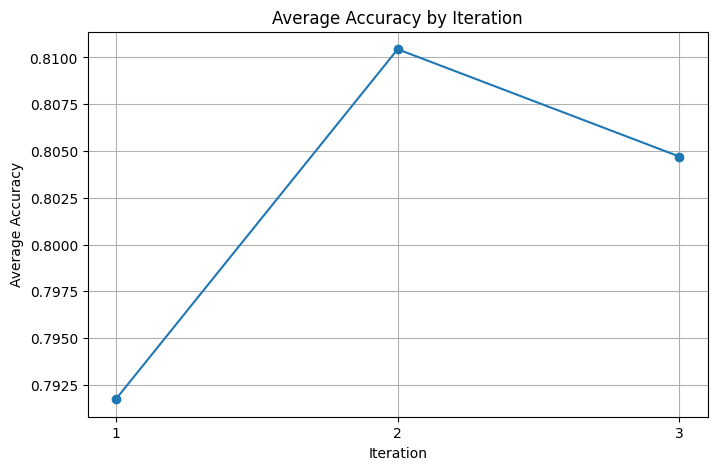

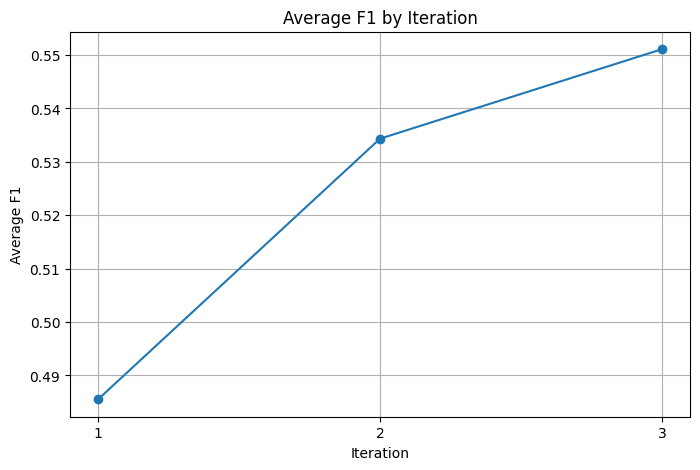

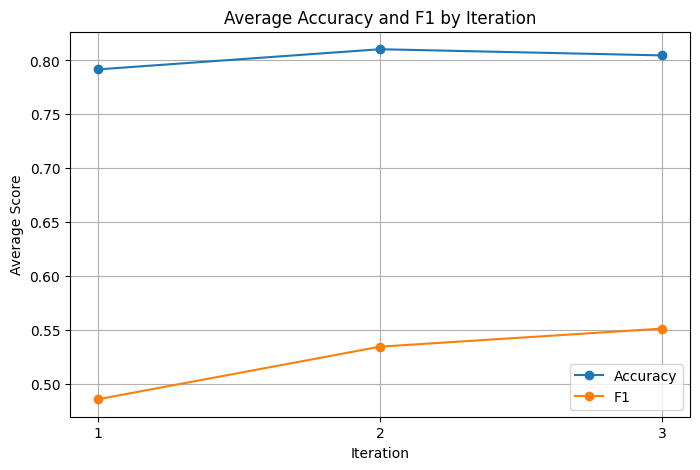

Saved plots:
  Classification\accuracy_vs_iteration.png
  Classification\f1_vs_iteration.png
  Classification\accuracy_vs_f1_per_iteration.png


In [2]:
# Step 6.14 - Compare Iterations 1, 2 and 3

import pandas as pd
import matplotlib.pyplot as plt
import os

all_results_path = "Classification/experiments_results_all_iterations.csv"

if not os.path.exists(all_results_path):
    raise FileNotFoundError(f"Unified results file was not found: {all_results_path}")

df_all_results = pd.read_csv(all_results_path)

required_columns = [
    "iteration",
    "target_column",
    "#classes",
    "accuracy",
    "F1"
]

missing_columns = [
    col for col in required_columns
    if col not in df_all_results.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Convert metrics to numeric
df_all_results["accuracy"] = pd.to_numeric(df_all_results["accuracy"], errors="coerce")
df_all_results["F1"] = pd.to_numeric(df_all_results["F1"], errors="coerce")

# Average metrics per iteration
iteration_summary = (
    df_all_results
    .groupby("iteration")[["accuracy", "F1"]]
    .mean()
    .reset_index()
)

print("Average performance by iteration:")
display(iteration_summary)

# Best F1 per target column and class setting for each iteration
best_results = (
    df_all_results
    .sort_values(
        by=["iteration", "target_column", "#classes", "F1"],
        ascending=[True, True, True, False]
    )
    .groupby(["iteration", "target_column", "#classes"])
    .head(1)
    .reset_index(drop=True)
)

print("Best result by F1 for each iteration, target column, and class setting:")
display(
    best_results[
        [
            "iteration",
            "target_column",
            "#classes",
            "algorithm",
            "feature_set",
            "training_type",
            "balanced",
            "accuracy",
            "precision",
            "recall",
            "F1",
            "AUC"
        ]
    ]
)

# Output paths
out_dir = "Classification"
accuracy_plot_path = os.path.join(out_dir, "accuracy_vs_iteration.png")
f1_plot_path = os.path.join(out_dir, "f1_vs_iteration.png")
combined_plot_path = os.path.join(out_dir, "accuracy_vs_f1_per_iteration.png")

# Plot Accuracy vs Iteration
plt.figure(figsize=(8, 5))
plt.plot(
    iteration_summary["iteration"],
    iteration_summary["accuracy"],
    marker="o"
)
plt.title("Average Accuracy by Iteration")
plt.xlabel("Iteration")
plt.ylabel("Average Accuracy")
plt.xticks(iteration_summary["iteration"])
plt.grid(True)
plt.savefig(accuracy_plot_path, bbox_inches="tight", dpi=300)
plt.show()

# Plot F1 vs Iteration
plt.figure(figsize=(8, 5))
plt.plot(
    iteration_summary["iteration"],
    iteration_summary["F1"],
    marker="o"
)
plt.title("Average F1 by Iteration")
plt.xlabel("Iteration")
plt.ylabel("Average F1")
plt.xticks(iteration_summary["iteration"])
plt.grid(True)
plt.savefig(f1_plot_path, bbox_inches="tight", dpi=300)
plt.show()

# Plot Accuracy and F1 together
plt.figure(figsize=(8, 5))
plt.plot(
    iteration_summary["iteration"],
    iteration_summary["accuracy"],
    marker="o",
    label="Accuracy"
)
plt.plot(
    iteration_summary["iteration"],
    iteration_summary["F1"],
    marker="o",
    label="F1"
)
plt.title("Average Accuracy and F1 by Iteration")
plt.xlabel("Iteration")
plt.ylabel("Average Score")
plt.xticks(iteration_summary["iteration"])
plt.grid(True)
plt.legend()
plt.savefig(combined_plot_path, bbox_inches="tight", dpi=300)
plt.show()

print("Saved plots:")
print(" ", accuracy_plot_path)
print(" ", f1_plot_path)
print(" ", combined_plot_path)

### סיכום תוצאות לאחר שלוש איטרציות של Active Learning

לאחר שלוש איטרציות של למידה אקטיבית, כמות המשתמשים המתויגים גדלה מ־100 משתמשים באיטרציה הראשונה, ל־200 משתמשים באיטרציה השנייה, ול־300 משתמשים באיטרציה השלישית.

מהתוצאות ניתן לראות כי מדד ה־Accuracy השתפר מאיטרציה 1 לאיטרציה 2, אך ירד מעט באיטרציה 3. לעומת זאת, מדד ה־F1 השתפר באופן עקבי לאורך כל שלוש האיטרציות.

שיפור עקבי במדד ה־F1 הוא משמעותי במיוחד בפרויקט זה, מכיוון שהתפלגות המחלקות אינה מאוזנת. לכן, גם כאשר ה־Accuracy אינו משתפר בכל איטרציה, שיפור במדד ה־F1 מעיד שהמודל מצליח להתמודד טוב יותר עם מחלקות קטנות יותר ולא רק עם המחלקה הדומיננטית.

בשלב זה עדיין לא נבחר לעצור את תהליך ה־Active Learning, מכיוון שה־F1 ממשיך להשתפר. לכן נמשיך לאיטרציה נוספת, Iteration 4, שבה נוסיף עוד 100 משתמשים מתויגים ונבדוק האם השיפור ממשיך או מתחיל להתייצב.

### Summary of Results After Three Active Learning Iterations

After three active learning iterations, the number of labeled users increased from 100 users in the first iteration, to 200 users in the second iteration, and to 300 users in the third iteration.

The results show that Accuracy improved from Iteration 1 to Iteration 2, but slightly decreased in Iteration 3. However, the F1 score improved consistently across all three iterations.

The consistent improvement in F1 is especially important in this project because the class distribution is imbalanced. Therefore, even if Accuracy does not improve in every iteration, an improvement in F1 indicates that the model is handling minority classes better and is not only focusing on the dominant class.

At this stage, we do not stop the Active Learning process yet, because the F1 score is still improving. Therefore, we continue to an additional iteration, Iteration 4, where we will add 100 more labeled users and check whether the improvement continues or starts to stabilize.

### הכנת משתמשים לא מתויגים עבור איטרציה 4

בשלב זה אנו מכינים את קבוצת המשתמשים שעדיין לא תויגו לאחר שלוש איטרציות של Active Learning.

עד סוף איטרציה 3 קיימים 300 משתמשים מתויגים בקובץ ה־consensus. לכן, אנו מסירים משתמשים אלו מתוך הדאטה המקורי, ומשאירים רק משתמשים שעדיין לא תויגו.

קובץ זה ישמש את המודל באיטרציה 4 לצורך חיזוי ובחירת 100 המשתמשים שהמודל הכי לא בטוח לגביהם.

### Preparing Unlabeled Users for Iteration 4

In this step, we prepare the set of users that are still unlabeled after three Active Learning iterations.

By the end of Iteration 3, we have 300 labeled users in the consensus file. Therefore, we remove these users from the original dataset and keep only the users that have not been labeled yet.

This file will be used in Iteration 4 for prediction and for selecting the 100 users with the highest model uncertainty.

In [1]:
# Step 6.15 - Prepare unlabeled users for Iteration 4

import pandas as pd
import os

iteration_4_dir = "Classification/iteration_4"
os.makedirs(iteration_4_dir, exist_ok=True)

all_users_path = "Data/final_israeli_users.xlsx"
iteration_3_consensus_path = "Classification/iteration_3/iteration_3_labels_consensus.csv"

iteration_4_unlabeled_path = "Classification/iteration_4/iteration_4_unlabeled_users.csv"

if os.path.exists(iteration_4_unlabeled_path):
    print("Iteration 4 unlabeled users file already exists. Loading existing file:")
    print(iteration_4_unlabeled_path)

    df_unlabeled_iter4 = pd.read_csv(iteration_4_unlabeled_path)

    print("Existing Iteration 4 unlabeled users:", len(df_unlabeled_iter4))
    display(df_unlabeled_iter4.head())

else:
    if not os.path.exists(all_users_path):
        raise FileNotFoundError(f"Original users file was not found: {all_users_path}")

    if not os.path.exists(iteration_3_consensus_path):
        raise FileNotFoundError(f"Iteration 3 consensus file was not found: {iteration_3_consensus_path}")

    df_all_users = pd.read_excel(all_users_path)
    df_all_users.columns = df_all_users.columns.str.strip()

    df_iter3_consensus = pd.read_csv(iteration_3_consensus_path)
    df_iter3_consensus.columns = df_iter3_consensus.columns.str.strip()

    if "username" not in df_all_users.columns:
        raise ValueError("Column 'username' was not found in the original users file.")

    if "username" not in df_iter3_consensus.columns:
        raise ValueError("Column 'username' was not found in the Iteration 3 consensus file.")

    df_all_users["username"] = df_all_users["username"].astype(str).str.strip()
    df_iter3_consensus["username"] = df_iter3_consensus["username"].astype(str).str.strip()

    labeled_usernames_iter3 = set(df_iter3_consensus["username"])

    df_unlabeled_iter4 = df_all_users[
        ~df_all_users["username"].isin(labeled_usernames_iter3)
    ].copy()

    # Safety checks
    overlap_count = df_unlabeled_iter4["username"].isin(labeled_usernames_iter3).sum()
    duplicate_count = df_unlabeled_iter4["username"].duplicated().sum()

    if overlap_count != 0:
        raise ValueError(f"Found {overlap_count} already-labeled users inside Iteration 4 unlabeled users.")

    if duplicate_count != 0:
        raise ValueError(f"Found {duplicate_count} duplicate usernames inside Iteration 4 unlabeled users.")

    df_unlabeled_iter4.to_csv(
        iteration_4_unlabeled_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Iteration 4 unlabeled users file was created successfully.")
    print("Saved to:", iteration_4_unlabeled_path)
    print("Total users in original data:", len(df_all_users))
    print("Labeled users up to Iteration 3:", len(df_iter3_consensus))
    print("Unlabeled users for Iteration 4:", len(df_unlabeled_iter4))
    print("Overlap with labeled users:", overlap_count)
    print("Duplicate usernames:", duplicate_count)

    display(df_unlabeled_iter4.head())

Iteration 4 unlabeled users file was created successfully.
Saved to: Classification/iteration_4/iteration_4_unlabeled_users.csv
Total users in original data: 6965
Labeled users up to Iteration 3: 300
Unlabeled users for Iteration 4: 6665
Overlap with labeled users: 0
Duplicate usernames: 0


,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage
0,amit_segal,False,22500,46.0,834700.0,פרשן פוליטי | חדשות 12 וידיעות אחרונות | אבא ש...,jerusalem israel,joined february 2010,Israeli,1
1,DudyBornovski,False,828,337.0,10300.0,who’s your daddy,tel-aviv israel,joined may 2010,Israeli,2
2,RamiRamii20,False,0,11.0,161.0,שאל תדע,nazareth,joined january 2022,Israeli,1
3,irish4israel,True,24800,NaN,NaN,this acc is now closed . follow ireland’s new ...,ireland,joined december 2010,Israeli,3
4,FleurEast,False,22500,4727.0,222100.0,singing dancing and laughing my way through li...,NaN,joined september 2010,Israeli,3


### חיזוי משתמשים לא מתויגים עבור איטרציה 4

בשלב זה אנו מאמנים את המודל הנבחר על 300 המשתמשים המתויגים עד סוף איטרציה 3.

לאחר מכן, אנו מפעילים את המודל על המשתמשים שעדיין לא תויגו, ומחשבים עבור כל משתמש את המחלקה החזויה, רמת הביטחון, הסתברויות המחלקות, וציון חוסר הוודאות.

תוצאות החיזוי ישמשו לבחירת 100 המשתמשים שהמודל הכי פחות בטוח לגביהם לצורך תיוג ידני באיטרציה 4.

### Predicting Unlabeled Users for Iteration 4

In this step, we train the selected model using the 300 labeled users available at the end of Iteration 3.

Then, we apply the model to the remaining unlabeled users and compute the predicted class, confidence level, class probabilities, and uncertainty score for each user.

The prediction results will be used to select the 100 users with the highest uncertainty for manual labeling in Iteration 4.

In [2]:
# Step 6.16 - Train best model and predict on unlabeled users for Iteration 4

import pandas as pd
import numpy as np
import os

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

iteration_4_dir = "Classification/iteration_4"
os.makedirs(iteration_4_dir, exist_ok=True)

all_users_path = "Data/final_israeli_users.xlsx"
iteration_3_consensus_path = "Classification/iteration_3/iteration_3_labels_consensus.csv"
iteration_4_unlabeled_path = "Classification/iteration_4/iteration_4_unlabeled_users.csv"
iteration_4_predictions_path = "Classification/iteration_4/iteration_4_unlabeled_users_predictions.csv"

if os.path.exists(iteration_4_predictions_path):
    print("Iteration 4 predictions file already exists. Loading existing file:")
    print(iteration_4_predictions_path)

    df_predictions_iter4 = pd.read_csv(iteration_4_predictions_path)

    print("Existing Iteration 4 predictions:", len(df_predictions_iter4))
    display(df_predictions_iter4.head())

else:
    required_paths = [
        all_users_path,
        iteration_3_consensus_path,
        iteration_4_unlabeled_path
    ]

    for path in required_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Required file was not found: {path}")

    df_all_users = pd.read_excel(all_users_path)
    df_all_users.columns = df_all_users.columns.str.strip()
    df_all_users["username"] = df_all_users["username"].astype(str).str.strip()

    df_consensus_iter3 = pd.read_csv(iteration_3_consensus_path)
    df_consensus_iter3.columns = df_consensus_iter3.columns.str.strip()
    df_consensus_iter3["username"] = df_consensus_iter3["username"].astype(str).str.strip()

    df_unlabeled_iter4 = pd.read_csv(iteration_4_unlabeled_path)
    df_unlabeled_iter4.columns = df_unlabeled_iter4.columns.str.strip()
    df_unlabeled_iter4["username"] = df_unlabeled_iter4["username"].astype(str).str.strip()

    # Build training dataframe from all user information + Iteration 3 consensus labels
    df_train = pd.merge(
        df_all_users,
        df_consensus_iter3[["username", "target_population"]],
        on="username",
        how="inner"
    )

    if len(df_train) != 300:
        raise ValueError(f"Expected 300 training users, got {len(df_train)}")

    # Prepare text feature
    for df in [df_train, df_unlabeled_iter4]:
        for col in ["username", "bio", "location"]:
            df[col] = df[col].fillna("").astype(str)

        df["profile_text"] = (
            df["username"] + " " +
            df["bio"] + " " +
            df["location"]
        )

    X_train = df_train[["profile_text"]]
    y_train = pd.to_numeric(df_train["target_population"], errors="coerce").astype(int)

    X_unlabeled = df_unlabeled_iter4[["profile_text"]]

    # The selected model is AdaBoost with TF-IDF profile text,
    # trained on the target_population task.
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "text",
                TfidfVectorizer(max_features=500, ngram_range=(1, 2)),
                "profile_text"
            )
        ]
    )

    model = AdaBoostClassifier(random_state=42)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train
    )

    pipeline.fit(
        X_train,
        y_train,
        classifier__sample_weight=sample_weights
    )

    predicted_classes = pipeline.predict(X_unlabeled)
    predicted_probabilities = pipeline.predict_proba(X_unlabeled)

    model_classes = list(pipeline.named_steps["classifier"].classes_)

    # Make sure probability columns exist for classes 0, 1, 2
    probability_columns = {}

    for class_label in [0, 1, 2]:
        if class_label in model_classes:
            class_index = model_classes.index(class_label)
            probability_columns[f"prob_{class_label}"] = predicted_probabilities[:, class_index]
        else:
            probability_columns[f"prob_{class_label}"] = 0.0

    probability_df = pd.DataFrame(probability_columns)

    confidence_level = probability_df.max(axis=1)
    uncertainty_score = 1 - confidence_level

    df_predictions_iter4 = df_unlabeled_iter4.copy()

    df_predictions_iter4["predicted_class"] = predicted_classes
    df_predictions_iter4["confidence_level"] = confidence_level

    df_predictions_iter4["prob_0"] = probability_df["prob_0"]
    df_predictions_iter4["prob_1"] = probability_df["prob_1"]
    df_predictions_iter4["prob_2"] = probability_df["prob_2"]

    df_predictions_iter4["uncertainty_score"] = uncertainty_score

    df_predictions_iter4 = df_predictions_iter4.sort_values(
        by="uncertainty_score",
        ascending=False
    ).reset_index(drop=True)

    df_predictions_iter4.to_csv(
        iteration_4_predictions_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Iteration 4 predictions file was created successfully.")
    print("Saved to:", iteration_4_predictions_path)
    print("Training users:", len(df_train))
    print("Predicted unlabeled users:", len(df_predictions_iter4))

    print("\nModel classes:")
    print(model_classes)

    print("\nPredicted class distribution:")
    print(df_predictions_iter4["predicted_class"].value_counts().sort_index())

    display(
        df_predictions_iter4[
            [
                "username",
                "bio",
                "location",
                "predicted_class",
                "confidence_level",
                "prob_0",
                "prob_1",
                "prob_2",
                "uncertainty_score"
            ]
        ].head()
    )

Iteration 4 predictions file was created successfully.
Saved to: Classification/iteration_4/iteration_4_unlabeled_users_predictions.csv
Training users: 300
Predicted unlabeled users: 6665

Model classes:
[np.int64(0), np.int64(1), np.int64(2)]

Predicted class distribution:
predicted_class
0    6160
1     362
2     143
Name: count, dtype: int64


,username,bio,location,predicted_class,confidence_level,prob_0,prob_1,prob_2,uncertainty_score
0,JacobsYechiel,defeating anti israel hate with comedy. sharin...,,0,0.336284,0.336284,0.330808,0.332908,0.663716
1,MikeE_3_14,dad datascience mathaddict genai llms diffusio...,greenland,0,0.336284,0.336284,0.330808,0.332908,0.663716
2,ramat123,former chairperson @ b'tselem.\nanti apartheid...,israel,0,0.336284,0.336284,0.330808,0.332908,0.663716
3,andresfidanza,periodista. jefe de redacción de el observador...,miami florida ee.uu.,0,0.336298,0.336298,0.335949,0.327753,0.663702
4,NagrelaEditores,publicamos libros de temática judía en español...,españa,0,0.336298,0.336298,0.335949,0.327753,0.663702


### בחירת משתמשים לא ודאיים ויצירת קבצי תיוג נפרדים לאיטרציה 4

בשלב זה אנו בוחרים את 100 המשתמשים שהמודל הכי פחות בטוח לגביהם באיטרציה 4, לפי ערך uncertainty_score הגבוה ביותר.

בהתאם להנחיית המרצה, באיטרציה זו ניצור שני קבצי תיוג נפרדים: קובץ אחד עבור אופיר וקובץ אחד עבור מתן.

שני הקבצים יכילו את אותם 100 משתמשים, אך כל מתייג ימלא את שלושת שדות הסיווג באופן עצמאי. לאחר מכן נשווה בין שני הקבצים וניצור קובץ הסכמה משותפת.

הקוד כולל הגנה מפני דריסה: אם קבצי התיוג כבר קיימים, הם לא ייווצרו מחדש ולא יימחקו בהרצת Run All.

### Selecting Uncertain Users and Creating Separate Annotation Files for Iteration 4

In this step, we select the 100 users with the highest uncertainty_score in Iteration 4.

According to the instructor's requirement, this iteration will use two separate annotation files: one for Ofir and one for Matan.

Both files contain the same 100 users, but each annotator fills the three classification labels independently. Later, the two files will be compared and a shared consensus file will be created.

The code includes overwrite protection: if the annotation files already exist, they will not be recreated or deleted during Run All.

In [3]:
# Step 6.17 - Select 100 most uncertain users and create separate annotation files for Iteration 4

import pandas as pd
import os

iteration_4_dir = "Classification/iteration_4"
os.makedirs(iteration_4_dir, exist_ok=True)

predictions_path = "Classification/iteration_4/iteration_4_unlabeled_users_predictions.csv"

users_to_label_path = "Classification/iteration_4/iteration_4_users_to_label.csv"
ofir_annotation_path = "Classification/iteration_4/iteration_4_annotation_ofir.csv"
matan_annotation_path = "Classification/iteration_4/iteration_4_annotation_matan.csv"

required_prediction_columns = [
    "username",
    "bio",
    "location",
    "predicted_class",
    "confidence_level",
    "prob_0",
    "prob_1",
    "prob_2",
    "uncertainty_score"
]

label_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# ------------------------------------------------------------
# Safety rule:
# If all three output files already exist, do not overwrite them.
# This protects manual annotation files during Run All.
# ------------------------------------------------------------
output_files = [
    users_to_label_path,
    ofir_annotation_path,
    matan_annotation_path
]

existing_output_files = [
    path for path in output_files
    if os.path.exists(path)
]

if len(existing_output_files) == len(output_files):
    print("Iteration 4 labeling files already exist. Loading existing files.")
    print("No files were overwritten.")

    print("\nExisting files:")
    for path in output_files:
        print(" ", path)

    df_users_to_label_iter4 = pd.read_csv(users_to_label_path)
    df_ofir_annotation_iter4 = pd.read_csv(ofir_annotation_path)
    df_matan_annotation_iter4 = pd.read_csv(matan_annotation_path)

    print("\nRows in users_to_label:", len(df_users_to_label_iter4))
    print("Rows in Ofir annotation file:", len(df_ofir_annotation_iter4))
    print("Rows in Matan annotation file:", len(df_matan_annotation_iter4))

    display(df_users_to_label_iter4.head())

else:
    # ------------------------------------------------------------
    # Extra safety:
    # If only some output files exist, stop instead of overwriting.
    # This prevents accidental partial damage.
    # ------------------------------------------------------------
    if len(existing_output_files) > 0:
        print("Some Iteration 4 labeling files already exist, but not all of them.")
        print("To avoid accidental overwrite, the code stopped.")
        print("\nExisting files:")
        for path in existing_output_files:
            print(" ", path)

        missing_output_files = [
            path for path in output_files
            if not os.path.exists(path)
        ]

        print("\nMissing files:")
        for path in missing_output_files:
            print(" ", path)

        raise FileExistsError(
            "Partial output files already exist. "
            "Please check the files manually before rerunning this step."
        )

    if not os.path.exists(predictions_path):
        raise FileNotFoundError(f"Predictions file was not found: {predictions_path}")

    df_predictions_iter4 = pd.read_csv(predictions_path)
    df_predictions_iter4.columns = df_predictions_iter4.columns.str.strip()

    missing_columns = [
        col for col in required_prediction_columns
        if col not in df_predictions_iter4.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns in predictions file: {missing_columns}")

    df_predictions_iter4["username"] = df_predictions_iter4["username"].astype(str).str.strip()
    df_predictions_iter4["uncertainty_score"] = pd.to_numeric(
        df_predictions_iter4["uncertainty_score"],
        errors="coerce"
    )

    if df_predictions_iter4["uncertainty_score"].isna().any():
        raise ValueError("Found missing or invalid uncertainty_score values.")

    if df_predictions_iter4["username"].duplicated().any():
        duplicate_count = df_predictions_iter4["username"].duplicated().sum()
        raise ValueError(f"Found {duplicate_count} duplicate usernames in predictions file.")

    # ------------------------------------------------------------
    # Select the 100 users with the highest uncertainty score
    # ------------------------------------------------------------
    df_users_to_label_iter4 = (
        df_predictions_iter4
        .sort_values(by="uncertainty_score", ascending=False)
        .head(100)
        .copy()
        .reset_index(drop=True)
    )

    if len(df_users_to_label_iter4) != 100:
        raise ValueError(f"Expected 100 users to label, got {len(df_users_to_label_iter4)}")

    if df_users_to_label_iter4["username"].duplicated().any():
        duplicate_count = df_users_to_label_iter4["username"].duplicated().sum()
        raise ValueError(f"Found {duplicate_count} duplicate usernames in selected users.")

    # This file keeps the selected users and model prediction information.
    df_users_to_label_iter4 = df_users_to_label_iter4[
        required_prediction_columns
    ].copy()

    df_users_to_label_iter4.to_csv(
        users_to_label_path,
        index=False,
        encoding="utf-8-sig"
    )

    # ------------------------------------------------------------
    # Create separate annotation templates for Ofir and Matan
    # ------------------------------------------------------------
    annotation_base_columns = [
        "username",
        "bio",
        "location",
        "predicted_class",
        "confidence_level",
        "prob_0",
        "prob_1",
        "prob_2",
        "uncertainty_score"
    ]

    df_annotation_template = df_users_to_label_iter4[
        annotation_base_columns
    ].copy()

    for col in label_columns:
        df_annotation_template[col] = ""

    df_annotation_template["comments"] = ""

    df_ofir_annotation_iter4 = df_annotation_template.copy()
    df_matan_annotation_iter4 = df_annotation_template.copy()

    df_ofir_annotation_iter4.to_csv(
        ofir_annotation_path,
        index=False,
        encoding="utf-8-sig"
    )

    df_matan_annotation_iter4.to_csv(
        matan_annotation_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Iteration 4 labeling files were created successfully.")
    print("No existing files were overwritten.")
    print("\nSaved files:")
    print(" ", users_to_label_path)
    print(" ", ofir_annotation_path)
    print(" ", matan_annotation_path)

    print("\nUsers selected for manual labeling:", len(df_users_to_label_iter4))

    print("\nTop uncertainty scores:")
    print(df_users_to_label_iter4["uncertainty_score"].head())

    print("\nLowest uncertainty score among selected 100:")
    print(df_users_to_label_iter4["uncertainty_score"].min())

    display(df_users_to_label_iter4.head())

Iteration 4 labeling files were created successfully.
No existing files were overwritten.

Saved files:
  Classification/iteration_4/iteration_4_users_to_label.csv
  Classification/iteration_4/iteration_4_annotation_ofir.csv
  Classification/iteration_4/iteration_4_annotation_matan.csv

Users selected for manual labeling: 100

Top uncertainty scores:
0    0.663716
1    0.663716
2    0.663716
3    0.663702
4    0.663702
Name: uncertainty_score, dtype: float64

Lowest uncertainty score among selected 100:
0.6595748554333859


,username,bio,location,predicted_class,confidence_level,prob_0,prob_1,prob_2,uncertainty_score
0,JacobsYechiel,defeating anti israel hate with comedy. sharin...,NaN,0,0.336284,0.336284,0.330808,0.332908,0.663716
1,MikeE_3_14,dad datascience mathaddict genai llms diffusio...,greenland,0,0.336284,0.336284,0.330808,0.332908,0.663716
2,ramat123,former chairperson @ b'tselem.\nanti apartheid...,israel,0,0.336284,0.336284,0.330808,0.332908,0.663716
3,andresfidanza,periodista. jefe de redacción de el observador...,miami florida ee.uu.,0,0.336298,0.336298,0.335949,0.327753,0.663702
4,NagrelaEditores,publicamos libros de temática judía en español...,españa,0,0.336298,0.336298,0.335949,0.327753,0.663702


### השוואת תיוגים בין אופיר ומתן עבור איטרציה 4

בשלב זה אנו משווים בין שני קבצי התיוג העצמאיים של איטרציה 4: קובץ התיוג של אופיר וקובץ התיוג של מתן.

עבור כל משתמש נבדוק האם שני המתייגים נתנו את אותם ערכים בשלושת שדות הסיווג: target_population, locals_vs_diaspora, person_vs_organization.

אם שני המתייגים הסכימו בכל שלושת השדות, המשתמש ייכנס לקובץ ההסכמות האוטומטיות.

אם קיימת מחלוקת לפחות באחד מהשדות, המשתמש ייכנס לקובץ מחלוקות. את קובץ המחלוקות נמלא לאחר דיון משותף ונשתמש בו ליצירת קובץ consensus סופי לאיטרציה 4.

הקוד כולל הגנה מפני דריסה: אם קובצי הפלט כבר קיימים, הם לא ייווצרו מחדש בהרצת Run All.

### Comparing Ofir and Matan Annotations for Iteration 4

In this step, we compare the two independent annotation files for Iteration 4: Ofir's annotation file and Matan's annotation file.

For each user, we check whether both annotators assigned the same values for the three classification fields: target_population, locals_vs_diaspora, and person_vs_organization.

If both annotators agreed on all three fields, the user is saved in the automatic agreements file.

If there is a disagreement in at least one field, the user is saved in a conflicts file. The conflicts file will later be resolved through a shared discussion and used to create the final Iteration 4 consensus file.

The code includes overwrite protection: if the output files already exist, they will not be recreated during Run All.

In [1]:
# Step 6.18 - Compare Ofir and Matan annotations for Iteration 4

import pandas as pd
import os

iteration_4_dir = "Classification/iteration_4"
os.makedirs(iteration_4_dir, exist_ok=True)

ofir_annotation_path = "Classification/iteration_4/iteration_4_annotation_ofir.csv"
matan_annotation_path = "Classification/iteration_4/iteration_4_annotation_matan.csv"

auto_agreements_path = "Classification/iteration_4/iteration_4_auto_agreements.csv"
conflicts_to_resolve_path = "Classification/iteration_4/iteration_4_conflicts_to_resolve.csv"
agreement_report_path = "Classification/iteration_4/iteration_4_agreement_report.csv"

label_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

info_columns = [
    "username",
    "bio",
    "location"
]

output_files = [
    auto_agreements_path,
    conflicts_to_resolve_path,
    agreement_report_path
]

existing_output_files = [
    path for path in output_files
    if os.path.exists(path)
]

# ------------------------------------------------------------
# Safety rule:
# If all output files already exist, do not overwrite them.
# This protects manually resolved conflict files during Run All.
# ------------------------------------------------------------
if len(existing_output_files) == len(output_files):
    print("Iteration 4 comparison files already exist. Loading existing files.")
    print("No files were overwritten.")

    print("\nExisting files:")
    for path in output_files:
        print(" ", path)

    df_auto_agreements = pd.read_csv(auto_agreements_path)
    df_conflicts_to_resolve = pd.read_csv(conflicts_to_resolve_path)
    df_agreement_report = pd.read_csv(agreement_report_path)

    print("\nAutomatic agreements:", len(df_auto_agreements))
    print("Conflicts to resolve:", len(df_conflicts_to_resolve))

    print("\nAgreement report:")
    display(df_agreement_report)

    print("\nConflicts preview:")
    display(df_conflicts_to_resolve.head())

else:
    # ------------------------------------------------------------
    # Extra safety:
    # If only some output files exist, stop instead of overwriting.
    # ------------------------------------------------------------
    if len(existing_output_files) > 0:
        print("Some Iteration 4 comparison files already exist, but not all of them.")
        print("To avoid accidental overwrite, the code stopped.")

        print("\nExisting files:")
        for path in existing_output_files:
            print(" ", path)

        missing_output_files = [
            path for path in output_files
            if not os.path.exists(path)
        ]

        print("\nMissing files:")
        for path in missing_output_files:
            print(" ", path)

        raise FileExistsError(
            "Partial comparison output files already exist. "
            "Please check the files manually before rerunning this step."
        )

    required_input_files = [
        ofir_annotation_path,
        matan_annotation_path
    ]

    for path in required_input_files:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Required annotation file was not found: {path}")

    df_ofir = pd.read_csv(ofir_annotation_path)
    df_matan = pd.read_csv(matan_annotation_path)

    df_ofir.columns = df_ofir.columns.str.strip()
    df_matan.columns = df_matan.columns.str.strip()

    required_columns = info_columns + label_columns

    for col in required_columns:
        if col not in df_ofir.columns:
            raise ValueError(f"Column '{col}' was not found in Ofir annotation file.")
        if col not in df_matan.columns:
            raise ValueError(f"Column '{col}' was not found in Matan annotation file.")

    df_ofir["username"] = df_ofir["username"].astype(str).str.strip()
    df_matan["username"] = df_matan["username"].astype(str).str.strip()

    if len(df_ofir) != 100:
        raise ValueError(f"Expected 100 rows in Ofir annotation file, got {len(df_ofir)}")

    if len(df_matan) != 100:
        raise ValueError(f"Expected 100 rows in Matan annotation file, got {len(df_matan)}")

    if df_ofir["username"].duplicated().any():
        duplicate_count = df_ofir["username"].duplicated().sum()
        raise ValueError(f"Found {duplicate_count} duplicate usernames in Ofir file.")

    if df_matan["username"].duplicated().any():
        duplicate_count = df_matan["username"].duplicated().sum()
        raise ValueError(f"Found {duplicate_count} duplicate usernames in Matan file.")

    ofir_usernames = set(df_ofir["username"])
    matan_usernames = set(df_matan["username"])

    if ofir_usernames != matan_usernames:
        only_ofir = sorted(list(ofir_usernames - matan_usernames))
        only_matan = sorted(list(matan_usernames - ofir_usernames))

        print("The two annotation files do not contain the same usernames.")
        print("Only in Ofir file:", only_ofir[:10])
        print("Only in Matan file:", only_matan[:10])

        raise ValueError("Ofir and Matan annotation files must contain the same 100 usernames.")

    # Validate labels
    allowed_labels = {0, 1, 2}

    for annotator_name, df in [("Ofir", df_ofir), ("Matan", df_matan)]:
        for col in label_columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

            if df[col].isna().any():
                missing_count = df[col].isna().sum()
                raise ValueError(
                    f"{annotator_name} file has {missing_count} missing or invalid values in column '{col}'."
                )

            unique_values = set(df[col].astype(int).unique())

            if not unique_values.issubset(allowed_labels):
                raise ValueError(
                    f"{annotator_name} file has invalid labels in column '{col}': {unique_values}"
                )

            df[col] = df[col].astype(int)

    # Keep comments if they exist
    if "comments" not in df_ofir.columns:
        df_ofir["comments"] = ""

    if "comments" not in df_matan.columns:
        df_matan["comments"] = ""

    # Merge annotations by username
    df_compare = pd.merge(
        df_ofir,
        df_matan,
        on="username",
        how="inner",
        suffixes=("_ofir", "_matan")
    )

    if len(df_compare) != 100:
        raise ValueError(f"Expected 100 merged rows, got {len(df_compare)}")

    # Compare agreement for each label column
    for col in label_columns:
        df_compare[f"{col}_agree"] = (
            df_compare[f"{col}_ofir"] == df_compare[f"{col}_matan"]
        )

    df_compare["all_labels_agree"] = df_compare[
        [f"{col}_agree" for col in label_columns]
    ].all(axis=1)

    df_auto = df_compare[df_compare["all_labels_agree"]].copy()
    df_conflicts = df_compare[~df_compare["all_labels_agree"]].copy()

    # ------------------------------------------------------------
    # Build automatic agreements file
    # ------------------------------------------------------------
    df_auto_agreements = pd.DataFrame()

    df_auto_agreements["username"] = df_auto["username"]

    # Use Ofir info columns if available after merge
    for col in ["bio", "location"]:
        ofir_col = f"{col}_ofir"
        matan_col = f"{col}_matan"

        if ofir_col in df_auto.columns:
            df_auto_agreements[col] = df_auto[ofir_col]
        elif matan_col in df_auto.columns:
            df_auto_agreements[col] = df_auto[matan_col]
        else:
            df_auto_agreements[col] = ""

    for col in label_columns:
        df_auto_agreements[col] = df_auto[f"{col}_ofir"]

    df_auto_agreements["comments"] = df_auto["comments_ofir"].fillna("").astype(str)
    df_auto_agreements["source_consensus"] = "auto_agree"

    # ------------------------------------------------------------
    # Build conflicts file for manual resolution
    # ------------------------------------------------------------
    df_conflicts_to_resolve = pd.DataFrame()

    df_conflicts_to_resolve["username"] = df_conflicts["username"]

    for col in ["bio", "location"]:
        ofir_col = f"{col}_ofir"
        matan_col = f"{col}_matan"

        if ofir_col in df_conflicts.columns:
            df_conflicts_to_resolve[col] = df_conflicts[ofir_col]
        elif matan_col in df_conflicts.columns:
            df_conflicts_to_resolve[col] = df_conflicts[matan_col]
        else:
            df_conflicts_to_resolve[col] = ""

    for col in label_columns:
        df_conflicts_to_resolve[f"{col}_ofir"] = df_conflicts[f"{col}_ofir"]
        df_conflicts_to_resolve[f"{col}_matan"] = df_conflicts[f"{col}_matan"]
        df_conflicts_to_resolve[col] = ""

    df_conflicts_to_resolve["comments_ofir"] = df_conflicts["comments_ofir"].fillna("").astype(str)
    df_conflicts_to_resolve["comments_matan"] = df_conflicts["comments_matan"].fillna("").astype(str)
    df_conflicts_to_resolve["final_comments"] = ""
    df_conflicts_to_resolve["source_consensus"] = "manual_resolution"

    # ------------------------------------------------------------
    # Agreement report
    # ------------------------------------------------------------
    report_rows = []

    for col in label_columns:
        percent_agreement = (
            df_compare[f"{col}_agree"].mean() * 100
        )

        report_rows.append({
            "label_type": col,
            "n_items": len(df_compare),
            "percent_agreement": round(percent_agreement, 2),
            "n_disagreements": int((~df_compare[f"{col}_agree"]).sum())
        })

    overall_agreement = df_compare["all_labels_agree"].mean() * 100

    report_rows.append({
        "label_type": "all_three_labels",
        "n_items": len(df_compare),
        "percent_agreement": round(overall_agreement, 2),
        "n_disagreements": int((~df_compare["all_labels_agree"]).sum())
    })

    df_agreement_report = pd.DataFrame(report_rows)

    # Save files
    df_auto_agreements.to_csv(
        auto_agreements_path,
        index=False,
        encoding="utf-8-sig"
    )

    df_conflicts_to_resolve.to_csv(
        conflicts_to_resolve_path,
        index=False,
        encoding="utf-8-sig"
    )

    df_agreement_report.to_csv(
        agreement_report_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Iteration 4 annotation comparison completed successfully.")
    print("No existing files were overwritten.")

    print("\nSaved files:")
    print(" ", auto_agreements_path)
    print(" ", conflicts_to_resolve_path)
    print(" ", agreement_report_path)

    print("\nAutomatic agreements:", len(df_auto_agreements))
    print("Conflicts to resolve:", len(df_conflicts_to_resolve))

    print("\nAgreement report:")
    display(df_agreement_report)

    print("\nConflicts preview:")
    display(df_conflicts_to_resolve.head())

Iteration 4 annotation comparison completed successfully.
No existing files were overwritten.

Saved files:
  Classification/iteration_4/iteration_4_auto_agreements.csv
  Classification/iteration_4/iteration_4_conflicts_to_resolve.csv
  Classification/iteration_4/iteration_4_agreement_report.csv

Automatic agreements: 73
Conflicts to resolve: 27

Agreement report:


,label_type,n_items,percent_agreement,n_disagreements
0,target_population,100,83.0,17
1,locals_vs_diaspora,100,84.0,16
2,person_vs_organization,100,88.0,12
3,all_three_labels,100,73.0,27



Conflicts preview:


,username,bio,location,target_population_ofir,target_population_matan,target_population,locals_vs_diaspora_ofir,locals_vs_diaspora_matan,locals_vs_diaspora,person_vs_organization_ofir,person_vs_organization_matan,person_vs_organization,comments_ofir,comments_matan,final_comments,source_consensus
0,JacobsYechiel,defeating anti israel hate with comedy. sharin...,NaN,2,0,,0,0,,1,1,,קומיקאי מחול אוהב ישראל אך לא ידוע אם ישראלי,,,manual_resolution
1,MikeE_3_14,dad datascience mathaddict genai llms diffusio...,greenland,1,0,,1,0,,1,1,,ישראלי פרסומים בעברית,,,manual_resolution
4,NagrelaEditores,publicamos libros de temática judía en español...,españa,0,0,,0,0,,0,1,,מוציאים לאור ספרים בספרדית על מדינת ישראל אך ל...,,,manual_resolution
7,IsraelinSV,bienvenidos a nuestra cuenta oficial en twitte...,san salvador el salvador,0,0,,0,0,,0,1,,עמוד רשמי של ישראל באך סלוודור,,,manual_resolution
9,IsraelinBG,official account of the embassy of israel in b...,sofia bulgaria,1,0,,0,0,,0,0,,שגרירות ישראל בבולגריה,,,manual_resolution


### יצירת קובץ Consensus סופי עבור איטרציה 4

בשלב זה אנו יוצרים את קובץ ה־consensus הסופי עבור איטרציה 4.

הקובץ נבנה משני מקורות: משתמשים שבהם שני המתייגים הסכימו אוטומטית, ומשתמשים שבהם הייתה מחלוקת והתקבלה הכרעה משותפת.

לאחר יצירת 100 התיוגים הסופיים של איטרציה 4, אנו מחברים אותם עם 300 המשתמשים המתויגים הקיימים מאיטרציה 3.

התוצאה היא קובץ consensus חדש הכולל 400 משתמשים מתויגים, שישמש לאימון המודלים באיטרציה 4.

הקוד כולל בדיקות תקינות והגנה מפני דריסה בהרצת Run All.

### Creating the Final Consensus File for Iteration 4

In this step, we create the final consensus file for Iteration 4.

The file is built from two sources: users where both annotators agreed automatically, and users where there was a disagreement that was resolved manually.

After creating the final 100 labels for Iteration 4, we combine them with the 300 labeled users from Iteration 3.

The result is a new consensus file containing 400 labeled users, which will be used for model training in Iteration 4.

The code includes validation checks and overwrite protection for Run All.

In [1]:
# Step 6.19 - Create Iteration 4 final consensus file with 400 labeled users

import pandas as pd
import os

iteration_4_dir = "Classification/iteration_4"
os.makedirs(iteration_4_dir, exist_ok=True)

iteration_3_consensus_path = "Classification/iteration_3/iteration_3_labels_consensus.csv"

auto_agreements_path = "Classification/iteration_4/iteration_4_auto_agreements.csv"
conflicts_to_resolve_path = "Classification/iteration_4/iteration_4_conflicts_to_resolve.csv"

iteration_4_new_labels_path = "Classification/iteration_4/iteration_4_new_labels_consensus.csv"
iteration_4_final_consensus_path = "Classification/iteration_4/iteration_4_labels_consensus.csv"

label_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# ------------------------------------------------------------
# Safety rule:
# If final consensus files already exist, do not overwrite them.
# This protects the manually resolved consensus during Run All.
# ------------------------------------------------------------
output_files = [
    iteration_4_new_labels_path,
    iteration_4_final_consensus_path
]

existing_output_files = [
    path for path in output_files
    if os.path.exists(path)
]

if len(existing_output_files) == len(output_files):
    print("Iteration 4 consensus files already exist. Loading existing files.")
    print("No files were overwritten.")

    df_iter4_new_labels = pd.read_csv(iteration_4_new_labels_path)
    df_iter4_consensus = pd.read_csv(iteration_4_final_consensus_path)

    print("\nExisting files:")
    for path in output_files:
        print(" ", path)

    print("\nNew Iteration 4 labels:", len(df_iter4_new_labels))
    print("Final Iteration 4 consensus rows:", len(df_iter4_consensus))
    print("Unique usernames:", df_iter4_consensus["username"].nunique())

    print("\nFinal Iteration 4 consensus distributions:")
    for col in label_columns:
        print(f"\n{col}:")
        print(df_iter4_consensus[col].value_counts().sort_index())

    display(df_iter4_consensus.head())

else:
    # ------------------------------------------------------------
    # Extra safety:
    # If only one output file exists, stop instead of overwriting.
    # ------------------------------------------------------------
    if len(existing_output_files) > 0:
        print("Some Iteration 4 consensus output files already exist, but not all of them.")
        print("To avoid accidental overwrite, the code stopped.")

        print("\nExisting files:")
        for path in existing_output_files:
            print(" ", path)

        missing_output_files = [
            path for path in output_files
            if not os.path.exists(path)
        ]

        print("\nMissing files:")
        for path in missing_output_files:
            print(" ", path)

        raise FileExistsError(
            "Partial Iteration 4 consensus files already exist. "
            "Please check the files manually before rerunning this step."
        )

    required_input_files = [
        iteration_3_consensus_path,
        auto_agreements_path,
        conflicts_to_resolve_path
    ]

    for path in required_input_files:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Required file was not found: {path}")

    df_iter3_consensus = pd.read_csv(iteration_3_consensus_path)
    df_auto = pd.read_csv(auto_agreements_path)
    df_conflicts = pd.read_csv(conflicts_to_resolve_path)

    for df in [df_iter3_consensus, df_auto, df_conflicts]:
        df.columns = df.columns.str.strip()
        df["username"] = df["username"].astype(str).str.strip()

    # Validate required columns
    for col in ["username"] + label_columns:
        if col not in df_iter3_consensus.columns:
            raise ValueError(f"Column '{col}' was not found in Iteration 3 consensus file.")
        if col not in df_auto.columns:
            raise ValueError(f"Column '{col}' was not found in auto agreements file.")
        if col not in df_conflicts.columns:
            raise ValueError(f"Column '{col}' was not found in conflicts file.")

    # Validate conflict file was filled
    allowed_labels = {0, 1, 2}

    for df_name, df in [
        ("auto agreements", df_auto),
        ("resolved conflicts", df_conflicts)
    ]:
        for col in label_columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

            if df[col].isna().any():
                missing_count = df[col].isna().sum()
                raise ValueError(
                    f"{df_name} file has {missing_count} missing or invalid values in column '{col}'."
                )

            unique_values = set(df[col].astype(int).unique())

            if not unique_values.issubset(allowed_labels):
                raise ValueError(
                    f"{df_name} file has invalid labels in column '{col}': {unique_values}"
                )

            df[col] = df[col].astype(int)

    # Create comments columns safely
    if "comments" not in df_auto.columns:
        df_auto["comments"] = ""

    if "final_comments" not in df_conflicts.columns:
        df_conflicts["final_comments"] = ""

    # Build final 100 labels from auto agreements
    df_auto_final = pd.DataFrame()
    df_auto_final["username"] = df_auto["username"]

    for col in ["bio", "location"]:
        df_auto_final[col] = df_auto[col] if col in df_auto.columns else ""

    for col in label_columns:
        df_auto_final[col] = df_auto[col]

    df_auto_final["comments"] = df_auto["comments"].fillna("").astype(str)
    df_auto_final["source_consensus"] = "auto_agree"

    # Build final labels from manually resolved conflicts
    df_conflicts_final = pd.DataFrame()
    df_conflicts_final["username"] = df_conflicts["username"]

    for col in ["bio", "location"]:
        df_conflicts_final[col] = df_conflicts[col] if col in df_conflicts.columns else ""

    for col in label_columns:
        df_conflicts_final[col] = df_conflicts[col]

    df_conflicts_final["comments"] = df_conflicts["final_comments"].fillna("").astype(str)
    df_conflicts_final["source_consensus"] = "manual_resolution"

    # Combine auto agreements + resolved conflicts = 100 new labels
    df_iter4_new_labels = pd.concat(
        [
            df_auto_final,
            df_conflicts_final
        ],
        ignore_index=True
    )

    if len(df_iter4_new_labels) != 100:
        raise ValueError(f"Expected 100 new Iteration 4 labels, got {len(df_iter4_new_labels)}")

    if df_iter4_new_labels["username"].duplicated().any():
        duplicate_count = df_iter4_new_labels["username"].duplicated().sum()
        raise ValueError(f"Found {duplicate_count} duplicate usernames in Iteration 4 new labels.")

    # Check no overlap with previous 300 users
    previous_usernames = set(df_iter3_consensus["username"])
    new_usernames = set(df_iter4_new_labels["username"])

    overlap = previous_usernames.intersection(new_usernames)

    if len(overlap) > 0:
        raise ValueError(
            f"Found {len(overlap)} Iteration 4 users that already exist in Iteration 3 consensus."
        )

    # Build final 400-user consensus
    # Keep only common expected columns where possible
    expected_columns = [
        "username",
        "bio",
        "location",
        "target_population",
        "locals_vs_diaspora",
        "person_vs_organization",
        "comments",
        "source_consensus"
    ]

    for col in expected_columns:
        if col not in df_iter3_consensus.columns:
            df_iter3_consensus[col] = ""

    df_iter3_consensus_clean = df_iter3_consensus[expected_columns].copy()
    df_iter4_new_labels_clean = df_iter4_new_labels[expected_columns].copy()

    df_iter4_consensus = pd.concat(
        [
            df_iter3_consensus_clean,
            df_iter4_new_labels_clean
        ],
        ignore_index=True
    )

    if len(df_iter4_consensus) != 400:
        raise ValueError(f"Expected 400 rows in Iteration 4 consensus, got {len(df_iter4_consensus)}")

    if df_iter4_consensus["username"].duplicated().any():
        duplicate_count = df_iter4_consensus["username"].duplicated().sum()
        raise ValueError(f"Found {duplicate_count} duplicate usernames in final Iteration 4 consensus.")

    # Save outputs
    df_iter4_new_labels.to_csv(
        iteration_4_new_labels_path,
        index=False,
        encoding="utf-8-sig"
    )

    df_iter4_consensus.to_csv(
        iteration_4_final_consensus_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Iteration 4 final consensus files were created successfully.")
    print("No existing files were overwritten.")

    print("\nSaved files:")
    print(" ", iteration_4_new_labels_path)
    print(" ", iteration_4_final_consensus_path)

    print("\nNew Iteration 4 labels:", len(df_iter4_new_labels))
    print("Auto agreements:", len(df_auto_final))
    print("Manual resolutions:", len(df_conflicts_final))

    print("\nFinal Iteration 4 consensus rows:", len(df_iter4_consensus))
    print("Unique usernames:", df_iter4_consensus["username"].nunique())

    print("\nFinal Iteration 4 consensus distributions:")
    for col in label_columns:
        print(f"\n{col}:")
        print(df_iter4_consensus[col].value_counts().sort_index())

    display(df_iter4_consensus.head())

Iteration 4 final consensus files were created successfully.
No existing files were overwritten.

Saved files:
  Classification/iteration_4/iteration_4_new_labels_consensus.csv
  Classification/iteration_4/iteration_4_labels_consensus.csv

New Iteration 4 labels: 100
Auto agreements: 73
Manual resolutions: 27

Final Iteration 4 consensus rows: 400
Unique usernames: 400

Final Iteration 4 consensus distributions:

target_population:
target_population
0     99
1    283
2     18
Name: count, dtype: int64

locals_vs_diaspora:
locals_vs_diaspora
0    124
1    261
2     15
Name: count, dtype: int64

person_vs_organization:
person_vs_organization
0     46
1    345
2      9
Name: count, dtype: int64


,username,bio,location,target_population,locals_vs_diaspora,person_vs_organization,comments,source_consensus
0,Roy_Iddan,,,1,1,1,,iteration_2_consensus
1,RayneNGrace,,,0,0,1,,iteration_2_consensus
2,shirellaloom,,,1,1,1,,iteration_2_consensus
3,raananshaked,,,1,1,1,,iteration_2_consensus
4,IsraelMOH,,,1,1,0,,iteration_2_consensus


### יצירת קבצי Target נפרדים עבור איטרציה 4

בשלב זה אנו יוצרים שלושה קבצי target נפרדים מתוך קובץ ה־consensus הסופי של איטרציה 4.

כל קובץ מתאים למשימת סיווג אחרת: זיהוי שייכות לאוכלוסיית היעד, הבחנה בין מקומי לתפוצות, והבחנה בין אדם לארגון.

קבצים אלו מאפשרים לשמור את תוצאות התיוג בצורה מסודרת עבור כל משימת סיווג בנפרד.

הקוד כולל הגנה מפני דריסה, כך שאם הקבצים כבר קיימים הם לא ייווצרו מחדש בהרצת Run All.

### Creating Separate Target Files for Iteration 4

In this step, we create three separate target files from the final Iteration 4 consensus file.

Each file corresponds to a different classification task: identifying membership in the target population, distinguishing between locals and diaspora, and distinguishing between person and organization.

These files keep the labeling results organized separately for each classification task.

The code includes overwrite protection, so if the files already exist they will not be recreated during Run All.

In [2]:
# Step 6.20 - Create Iteration 4 target files

import pandas as pd
import os

iteration_4_dir = "Classification/iteration_4"
os.makedirs(iteration_4_dir, exist_ok=True)

iteration_4_consensus_path = "Classification/iteration_4/iteration_4_labels_consensus.csv"

target_files = {
    "target_population": "Classification/iteration_4/iteration_4_target_population.csv",
    "locals_vs_diaspora": "Classification/iteration_4/iteration_4_locals_vs_diaspora.csv",
    "person_vs_organization": "Classification/iteration_4/iteration_4_person_vs_organization.csv"
}

label_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# ------------------------------------------------------------
# Safety rule:
# If all target files already exist, do not overwrite them.
# This protects the files during Run All.
# ------------------------------------------------------------
existing_target_files = [
    path for path in target_files.values()
    if os.path.exists(path)
]

if len(existing_target_files) == len(target_files):
    print("Iteration 4 target files already exist. Loading existing files.")
    print("No files were overwritten.")

    print("\nExisting files:")
    for path in target_files.values():
        print(" ", path)

    for label_col, path in target_files.items():
        df_existing = pd.read_csv(path)
        print(f"\n{label_col}:")
        print("Rows:", len(df_existing))
        print("Unique usernames:", df_existing["username"].nunique())
        print("Distribution:")
        print(df_existing[label_col].value_counts().sort_index())

else:
    # ------------------------------------------------------------
    # Extra safety:
    # If only some target files exist, stop instead of overwriting.
    # ------------------------------------------------------------
    if len(existing_target_files) > 0:
        print("Some Iteration 4 target files already exist, but not all of them.")
        print("To avoid accidental overwrite, the code stopped.")

        print("\nExisting files:")
        for path in existing_target_files:
            print(" ", path)

        missing_target_files = [
            path for path in target_files.values()
            if not os.path.exists(path)
        ]

        print("\nMissing files:")
        for path in missing_target_files:
            print(" ", path)

        raise FileExistsError(
            "Partial Iteration 4 target files already exist. "
            "Please check the files manually before rerunning this step."
        )

    if not os.path.exists(iteration_4_consensus_path):
        raise FileNotFoundError(
            f"Iteration 4 consensus file was not found: {iteration_4_consensus_path}"
        )

    df_iter4_consensus = pd.read_csv(iteration_4_consensus_path)
    df_iter4_consensus.columns = df_iter4_consensus.columns.str.strip()

    required_columns = [
        "username",
        "bio",
        "location",
        "comments",
        "source_consensus"
    ] + label_columns

    missing_columns = [
        col for col in required_columns
        if col not in df_iter4_consensus.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing required columns in Iteration 4 consensus file: {missing_columns}")

    df_iter4_consensus["username"] = df_iter4_consensus["username"].astype(str).str.strip()

    if len(df_iter4_consensus) != 400:
        raise ValueError(f"Expected 400 rows in Iteration 4 consensus, got {len(df_iter4_consensus)}")

    if df_iter4_consensus["username"].nunique() != 400:
        raise ValueError("Expected 400 unique usernames in Iteration 4 consensus file.")

    allowed_labels = {0, 1, 2}

    for col in label_columns:
        df_iter4_consensus[col] = pd.to_numeric(
            df_iter4_consensus[col],
            errors="coerce"
        )

        if df_iter4_consensus[col].isna().any():
            missing_count = df_iter4_consensus[col].isna().sum()
            raise ValueError(
                f"Found {missing_count} missing or invalid values in column '{col}'."
            )

        unique_values = set(df_iter4_consensus[col].astype(int).unique())

        if not unique_values.issubset(allowed_labels):
            raise ValueError(
                f"Found invalid label values in column '{col}': {unique_values}"
            )

        df_iter4_consensus[col] = df_iter4_consensus[col].astype(int)

    base_columns = [
        "username",
        "bio",
        "location",
        "comments",
        "source_consensus"
    ]

    print("Loaded Iteration 4 consensus file.")
    print("Rows:", len(df_iter4_consensus))
    print("Unique usernames:", df_iter4_consensus["username"].nunique())

    for label_col, output_path in target_files.items():
        df_target = df_iter4_consensus[
            base_columns + [label_col]
        ].copy()

        df_target.to_csv(
            output_path,
            index=False,
            encoding="utf-8-sig"
        )

        print(
            f"Saved target file: {output_path} "
            f"({len(df_target)} users) | distribution: "
            f"{df_target[label_col].value_counts().sort_index().to_dict()}"
        )

    display(df_iter4_consensus.head())

Loaded Iteration 4 consensus file.
Rows: 400
Unique usernames: 400
Saved target file: Classification/iteration_4/iteration_4_target_population.csv (400 users) | distribution: {0: 99, 1: 283, 2: 18}
Saved target file: Classification/iteration_4/iteration_4_locals_vs_diaspora.csv (400 users) | distribution: {0: 124, 1: 261, 2: 15}
Saved target file: Classification/iteration_4/iteration_4_person_vs_organization.csv (400 users) | distribution: {0: 46, 1: 345, 2: 9}


,username,bio,location,target_population,locals_vs_diaspora,person_vs_organization,comments,source_consensus
0,Roy_Iddan,NaN,NaN,1,1,1,NaN,iteration_2_consensus
1,RayneNGrace,NaN,NaN,0,0,1,NaN,iteration_2_consensus
2,shirellaloom,NaN,NaN,1,1,1,NaN,iteration_2_consensus
3,raananshaked,NaN,NaN,1,1,1,NaN,iteration_2_consensus
4,IsraelMOH,NaN,NaN,1,1,0,NaN,iteration_2_consensus


### הרצת ניסויי מודלים עבור איטרציה 4

בשלב זה אנו מריצים מחדש את כל ניסויי המודלים על קובץ ה־consensus של איטרציה 4, הכולל 400 משתמשים מתויגים.

המטרה היא לבדוק האם הוספת 100 המשתמשים החדשים מאיטרציה 4 שיפרה את ביצועי המודלים ביחס לאיטרציות הקודמות.

אנו משתמשים באותו מבנה ניסויים כמו באיטרציות הקודמות: שלוש משימות סיווג, שתי אפשרויות מחלקות, מספר אלגוריתמים, מספר ייצוגי פיצ׳רים, K-Fold, LOOCV, ואימון עם ובלי איזון מחלקות.

תוצאות הניסויים נשמרות בקובץ experiments_results_iteration_4.csv.

הקוד כולל הגנה מפני הרצה מחדש: אם קובץ התוצאות כבר קיים, הוא ייטען ולא יחושב מחדש בהרצת Run All.

### Running Model Experiments for Iteration 4

In this step, we rerun the full model experiment table using the Iteration 4 consensus file, which contains 400 labeled users.

The goal is to check whether adding the 100 newly labeled users from Iteration 4 improved model performance compared to the previous iterations.

We use the same experiment structure as in the previous iterations: three classification tasks, two class settings, multiple algorithms, multiple feature representations, K-Fold, LOOCV, and training with and without class balancing.

The experiment results are saved in experiments_results_iteration_4.csv.

The code includes rerun protection: if the results file already exists, it will be loaded instead of recomputed during Run All.

In [4]:
# Step 6.21 - Rerun the full Step-5 experiment table on the Iteration 4 dataset (400 users)
# RUN_EXPERIMENTS = False loads the saved results if they already exist.
# If the results file does not exist, the experiments will run and create it.
# Running all experiments may take around 20-30 minutes.

import os
import pandas as pd

RUN_EXPERIMENTS = False

ITERATION = 4
results_path = f"Classification/iteration_{ITERATION}/experiments_results_iteration_{ITERATION}.csv"

if not RUN_EXPERIMENTS and os.path.exists(results_path):
    print("Experiment results file already exists. Loading:", results_path)

    df_experiments_iter4 = pd.read_csv(results_path)

    print("Loaded experiment results rows:", len(df_experiments_iter4))

    display(df_experiments_iter4.head())

else:
    print("Running model training experiments on the 400-user Iteration 4 dataset...")

    import numpy as np
    import warnings

    from sklearn.model_selection import StratifiedKFold, LeaveOneOut
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.utils.class_weight import compute_sample_weight

    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.svm import LinearSVC

    warnings.filterwarnings("ignore")

    try:
        from xgboost import XGBClassifier
        xgboost_available = True
    except ImportError:
        xgboost_available = False
        print("XGBoost is not installed. XGBoost experiments will be skipped.")

    # ------------------------------------------------------------
    # Build the 400-user model dataframe from the Iteration 4 consensus
    # ------------------------------------------------------------
    df_users = pd.read_excel("Data/final_israeli_users.xlsx")
    df_users.columns = df_users.columns.str.strip()
    df_users["username"] = df_users["username"].astype(str).str.strip()

    df_cons = pd.read_csv(
        f"Classification/iteration_{ITERATION}/iteration_{ITERATION}_labels_consensus.csv"
    )
    df_cons.columns = df_cons.columns.str.strip()
    df_cons["username"] = df_cons["username"].astype(str).str.strip()

    # Important fix:
    # The consensus file may also contain bio/location columns.
    # We keep only username + labels from the consensus file,
    # and take bio/location/numeric features from the original users file.
    df_cons_labels_only = df_cons[
        [
            "username",
            "target_population",
            "locals_vs_diaspora",
            "person_vs_organization"
        ]
    ].copy()

    df_model = pd.merge(
        df_users,
        df_cons_labels_only,
        on="username",
        how="inner"
    )

    assert len(df_model) == 400, f"Expected 400 labeled rows, got {len(df_model)}"

    target_columns = [
        "target_population",
        "locals_vs_diaspora",
        "person_vs_organization"
    ]

    numeric_features = [
        "is_private",
        "posts",
        "following",
        "followers"
    ]

    for c in ["username", "bio", "location"]:
        if c not in df_model.columns:
            raise ValueError(f"Column '{c}' was not found after merge.")

        df_model[c] = df_model[c].fillna("").astype(str)

    df_model["profile_text"] = (
        df_model["username"] + " " +
        df_model["bio"] + " " +
        df_model["location"]
    )

    for c in numeric_features:
        if c not in df_model.columns:
            raise ValueError(f"Numeric feature column '{c}' was not found in df_model.")

        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")

    df_model["is_private"] = df_model["is_private"].fillna(0).astype(int)
    df_model[numeric_features] = df_model[numeric_features].fillna(0)

    for c in target_columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").astype(int)

    # ------------------------------------------------------------
    # Feature sets
    # ------------------------------------------------------------
    feature_sets = {
        "TFIDF_profile_text": {
            "columns": ["profile_text"],
            "numeric": [],
            "count_features": 500
        },
        "TFIDF_profile_text+numeric_metadata": {
            "columns": ["profile_text"] + numeric_features,
            "numeric": numeric_features,
            "count_features": 500 + len(numeric_features)
        }
    }

    def build_preprocessor(feature_set_name):
        config = feature_sets[feature_set_name]

        transformers = [
            (
                "text",
                TfidfVectorizer(max_features=500, ngram_range=(1, 2)),
                "profile_text"
            )
        ]

        if len(config["numeric"]) > 0:
            transformers.append(
                (
                    "numeric",
                    StandardScaler(),
                    config["numeric"]
                )
            )

        return ColumnTransformer(transformers=transformers)

    def get_models(balanced):
        class_weight_value = "balanced" if balanced else None

        models = {
            "LogReg": LogisticRegression(
                max_iter=1000,
                class_weight=class_weight_value,
                random_state=42
            ),
            "Decision Tree": DecisionTreeClassifier(
                class_weight=class_weight_value,
                random_state=42
            ),
            "Random Forest": RandomForestClassifier(
                n_estimators=100,
                class_weight=class_weight_value,
                random_state=42
            ),
            "SVM": LinearSVC(
                class_weight=class_weight_value,
                random_state=42
            ),
            "AdaBoost": AdaBoostClassifier(
                random_state=42
            ),
        }

        if xgboost_available:
            models["XGBoost"] = XGBClassifier(
                random_state=42,
                eval_metric="mlogloss"
            )

        return models

    def safe_auc_score(y_true, y_score, classes):
        try:
            unique_classes = np.unique(y_true)

            if len(unique_classes) < 2:
                return np.nan

            if len(classes) == 2:
                if len(y_score.shape) == 2:
                    return roc_auc_score(y_true, y_score[:, 1])
                else:
                    return roc_auc_score(y_true, y_score)

            if len(classes) == 3:
                if len(y_score.shape) == 2 and y_score.shape[1] == len(classes):
                    return roc_auc_score(
                        y_true,
                        y_score,
                        multi_class="ovr",
                        average="macro",
                        labels=classes
                    )

            return np.nan

        except Exception:
            return np.nan

    def evaluate_model_cv(X, y, pipeline, cv, balanced, model_name):
        y_true_all = []
        y_pred_all = []
        y_score_all = []

        classes = np.sort(y.unique())

        for train_index, test_index in cv.split(X, y):
            X_train = X.iloc[train_index]
            X_test = X.iloc[test_index]

            y_train = y.iloc[train_index]
            y_test = y.iloc[test_index]

            if balanced and model_name in ["AdaBoost", "XGBoost"]:
                sample_weights = compute_sample_weight(
                    class_weight="balanced",
                    y=y_train
                )

                pipeline.fit(
                    X_train,
                    y_train,
                    classifier__sample_weight=sample_weights
                )
            else:
                pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_test)

            y_score = None

            if hasattr(pipeline, "predict_proba"):
                try:
                    y_score = pipeline.predict_proba(X_test)
                except Exception:
                    y_score = None

            if y_score is None and hasattr(pipeline, "decision_function"):
                try:
                    y_score = pipeline.decision_function(X_test)
                except Exception:
                    y_score = None

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            if y_score is not None:
                if y_score_all is not None:
                    y_score_all.extend(np.array(y_score).tolist())
            else:
                y_score_all = None

        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)

        accuracy = accuracy_score(y_true_all, y_pred_all)

        precision = precision_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        )

        f1 = f1_score(
            y_true_all,
            y_pred_all,
            average="macro",
            zero_division=0
        )

        if y_score_all is not None:
            auc = safe_auc_score(
                y_true_all,
                np.array(y_score_all),
                classes
            )
        else:
            auc = np.nan

        return accuracy, precision, recall, f1, auc

    # ------------------------------------------------------------
    # Run all required experiments
    # ------------------------------------------------------------
    experiment_results = []

    for target_col in target_columns:
        for class_mode in ["3_classes", "2_classes_without_unknown"]:

            if class_mode == "3_classes":
                df_task = df_model.copy()
            else:
                df_task = df_model[df_model[target_col] != 2].copy()

            X_base = df_task[["profile_text"] + numeric_features].reset_index(drop=True)
            y_base = df_task[target_col].astype(int).reset_index(drop=True)

            class_counts = y_base.value_counts().to_dict()

            count_class_0 = class_counts.get(0, 0)
            count_class_1 = class_counts.get(1, 0)
            count_class_2 = class_counts.get(2, 0)

            classes_number = y_base.nunique()
            min_class_size = min(class_counts.values())

            print(
                f"\nTarget: {target_col} | Mode: {class_mode} | counts: {class_counts}",
                flush=True
            )

            for feature_set_name, feature_config in feature_sets.items():
                X = X_base[feature_config["columns"]]

                for balanced in [False, True]:
                    models = get_models(balanced)

                    for algorithm_name, model in models.items():
                        validation_methods = [
                            (
                                "K-Fold",
                                5,
                                StratifiedKFold(
                                    n_splits=5,
                                    shuffle=True,
                                    random_state=42
                                )
                            ),
                            (
                                "LOOCV",
                                "",
                                LeaveOneOut()
                            ),
                        ]

                        for training_type, K_value, cv in validation_methods:
                            preprocessor = build_preprocessor(feature_set_name)

                            pipeline = Pipeline(
                                steps=[
                                    ("preprocessor", preprocessor),
                                    ("classifier", model)
                                ]
                            )

                            try:
                                accuracy, precision, recall, f1, auc = evaluate_model_cv(
                                    X=X,
                                    y=y_base,
                                    pipeline=pipeline,
                                    cv=cv,
                                    balanced=balanced,
                                    model_name=algorithm_name
                                )

                                experiment_results.append({
                                    "iteration": ITERATION,
                                    "target_column": target_col,
                                    "#classes": classes_number,
                                    "#class_0": count_class_0,
                                    "#class_1": count_class_1,
                                    "#class_2": count_class_2 if classes_number == 3 else 0,
                                    "min_class_size": min_class_size,
                                    "training_type": training_type,
                                    "K": K_value,
                                    "algorithm": algorithm_name,
                                    "feature_set": feature_set_name,
                                    "Features_count": feature_config["count_features"],
                                    "balanced": balanced,
                                    "accuracy": round(accuracy, 4),
                                    "precision": round(precision, 4),
                                    "recall": round(recall, 4),
                                    "F1": round(f1, 4),
                                    "AUC": round(auc, 4) if not pd.isna(auc) else "",
                                })

                            except Exception as error:
                                print(
                                    f"Experiment FAILED: "
                                    f"target={target_col}, "
                                    f"mode={class_mode}, "
                                    f"features={feature_set_name}, "
                                    f"algo={algorithm_name}, "
                                    f"balanced={balanced}, "
                                    f"val={training_type} -> {error}",
                                    flush=True
                                )

    # ------------------------------------------------------------
    # Save results
    # ------------------------------------------------------------
    required_columns = [
        "iteration",
        "target_column",
        "#classes",
        "#class_0",
        "#class_1",
        "#class_2",
        "min_class_size",
        "training_type",
        "K",
        "algorithm",
        "feature_set",
        "Features_count",
        "balanced",
        "accuracy",
        "precision",
        "recall",
        "F1",
        "AUC"
    ]

    df_experiments = pd.DataFrame(experiment_results)[required_columns]

    df_experiments.to_csv(
        results_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"\nTotal experiments saved: {len(df_experiments)}")
    print(f"Saved to: {results_path}")

    df_experiments_iter4 = df_experiments

    display(df_experiments_iter4)

Running model training experiments on the 400-user Iteration 4 dataset...

Target: target_population | Mode: 3_classes | counts: {1: 283, 0: 99, 2: 18}

Target: target_population | Mode: 2_classes_without_unknown | counts: {1: 283, 0: 99}

Target: locals_vs_diaspora | Mode: 3_classes | counts: {1: 261, 0: 124, 2: 15}

Target: locals_vs_diaspora | Mode: 2_classes_without_unknown | counts: {1: 261, 0: 124}

Target: person_vs_organization | Mode: 3_classes | counts: {1: 345, 0: 46, 2: 9}

Target: person_vs_organization | Mode: 2_classes_without_unknown | counts: {1: 345, 0: 46}

Total experiments saved: 288
Saved to: Classification/iteration_4/experiments_results_iteration_4.csv


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,4,target_population,3,99,283,18,18,K-Fold,5,LogReg,TFIDF_profile_text,500,False,0.7700,0.4880,0.4503,0.4551,0.7487
1,4,target_population,3,99,283,18,18,LOOCV,,LogReg,TFIDF_profile_text,500,False,0.7725,0.4905,0.4493,0.4542,0.7228
2,4,target_population,3,99,283,18,18,K-Fold,5,Decision Tree,TFIDF_profile_text,500,False,0.7075,0.4220,0.4187,0.4183,0.5876
3,4,target_population,3,99,283,18,18,LOOCV,,Decision Tree,TFIDF_profile_text,500,False,0.7375,0.4550,0.4504,0.4515,0.601
4,4,target_population,3,99,283,18,18,K-Fold,5,Random Forest,TFIDF_profile_text,500,False,0.7625,0.4739,0.4402,0.4430,0.7375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,4,person_vs_organization,2,46,345,0,46,LOOCV,,SVM,TFIDF_profile_text+numeric_metadata,504,True,0.8465,0.6466,0.6681,0.6560,0.7424
284,4,person_vs_organization,2,46,345,0,46,K-Fold,5,AdaBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8133,0.6325,0.7058,0.6524,0.7592
285,4,person_vs_organization,2,46,345,0,46,LOOCV,,AdaBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8286,0.6432,0.7051,0.6633,0.797
286,4,person_vs_organization,2,46,345,0,46,K-Fold,5,XGBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8593,0.6595,0.6565,0.6580,0.7891
